# R35 — Patient-Level Model + Flexible Bilateral Rule

**Root cause from R31-R34 diagnosis**: The per-eye threshold → bilateral counting pipeline has 
reached its ceiling. 94% of missed referable patients have 1 eye caught but the 2nd eye falls 
just below the hard threshold. No amount of aggregation tweaking or scorer changes solves this.

## Two targeted enhancements:

### Enhancement 1: Patient-Level Model (Stage 2 learned model)
Instead of hard thresholding per-eye probabilities, train a small model that sees patient-level 
features extracted from all eye probabilities:
- `max_proba`, `second_max_proba`, `mean_proba`, `min_proba`, `std_proba`
- `n_eyes`, `proba_range`, `n_above_02`, `n_above_03`, `n_above_05`

This learns soft rules like: "patient with 2 eyes at 0.35 and 0.25 → referable" without a 
hard per-eye threshold. Trained on train patients, threshold-tuned on val, evaluated on test.

Models: LogisticRegression (sweep C) + LightGBM (learned interactions)

### Enhancement 2: Flexible Bilateral Rule
Sweep `min_eyes ∈ {1, 2, 3}` jointly with threshold. `min_eyes=1` with a higher threshold 
may catch patients where only 1 eye has high confidence.

### Stage 1: Identical to R31
- R28 hyperparameters (no BayesSearchCV)
- 25-bag ensemble (5 seeds × 5 arch variants)
- MLP_MAX_ITER=400, THRESHOLD_GRID=301
- PCA → MI → metadata → OD masking pipeline

In [1]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 2 — Imports
# ═══════════════════════════════════════════════════════════════════════
from __future__ import annotations
import json, time, warnings, ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.collections import LineCollection

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report, roc_curve,
)
import lightgbm as lgb

import sys
sys.path.insert(0, str(Path.cwd() / 'src'))
from retina_embeddings_dataset import load_retina_embeddings_dataset

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
print('R35 imports OK')

R35 imports OK


In [2]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 3 — Configuration
# ═══════════════════════════════════════════════════════════════════════

# ─── Task ─────────────────────────────────────────────────────────
DATASET_NAME = 'brset'
TASK         = 'increased_cup_disc'   # per-eye label used by Stage 1
RANDOM_SEED  = 42

from multiprocessing import cpu_count
CPU_COUNT = cpu_count()

# ─── Paths ────────────────────────────────────────────────────────
BASE_DIR     = Path.cwd()
FE_DIR       = BASE_DIR / 'artifacts' / 'brset_eda_fe'

# IMPORTANT: Use the cleaned BRSET embeddings + cleaned labels when comparing to the glaucoma-any work
USE_CLEAN_DATASET = True
EMBED_DIR_RAW   = BASE_DIR / 'data' / 'brset_embeddings'
EMBED_DIR_CLEAN = BASE_DIR / 'data' / 'brset_embeddings_cleaned'
EMBED_DIR       = EMBED_DIR_CLEAN if USE_CLEAN_DATASET else EMBED_DIR_RAW
LABELS_PATH     = EMBED_DIR / 'brset_labels' / 'labels_brset.csv'

# Keep results separate so we don't overwrite older runs
RESULTS_DIR_NAME = 'brset_r35_patient_model_cascade_cleaned' if USE_CLEAN_DATASET else 'brset_r35_patient_model_cascade'
RESULTS_DIR  = BASE_DIR / 'results' / RESULTS_DIR_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# R28 saved hyperparameters
R28_DIR = BASE_DIR / 'results' / 'brset_r28_fe_experiment' / 'r28_per_encoder'

# ─── Stage 1 Pipeline parameters (identical to R31) ──────────────
PCA_COMPONENTS       = 384
MI_SELECTION         = True
MI_PERCENTILE_THRESH = 0.15
MI_MIN_COMPONENTS    = 128

MLP_MAX_ITER   = 400
MLP_PATIENCE   = 30

BAG_SEEDS           = [42, 123, 314, 555, 789]
N_BAG_ARCH_VARIANTS = 5
N_BAGS = len(BAG_SEEDS) * N_BAG_ARCH_VARIANTS   # 25

THRESHOLD_GRID  = 301
THRESHOLD_FLOOR = 0.05

# ─── Clinical metadata (same 5 cols as R28) ──────────────────────
METADATA_COLS = {
    'age':      'numeric',
    'sex':      'passthrough',
    'diabetes': 'binary_yn',
    'exam_eye': 'binary',
    'camera':   'camera',
}

# ─── optic_disc masking (same as R28) ────────────────────────────
OD_P_MASK_BASE    = 0.50
OD_P_MASK_RANGE   = (0.35, 0.70)
OD_CORRUPT        = 0.10
OD_FEATURE_WEIGHT = 0.50
OD_MISS_WEIGHT    = 0.50
OD_TEST_P_MASK    = 0.25

# ─── Bilateral / referable threshold ─────────────────────────────
BILATERAL_MIN_EYES = 2   # default for R31 baseline comparison

# ─── R35 NEW: Patient-level model config ─────────────────────────
PATIENT_FEATURE_COLS = [
    'max_proba', 'second_max', 'mean_proba', 'min_proba',
    'std_proba', 'n_eyes', 'proba_range',
    'n_above_02', 'n_above_03', 'n_above_05',
]

# LogReg sweep
LR_C_VALUES = [0.01, 0.1, 1.0, 10.0]

# LightGBM config (small tree to avoid overfitting on ~5k patients)
LGB_PARAMS = dict(
    n_estimators=200, max_depth=3, num_leaves=8,
    learning_rate=0.05, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1,
)

# Flexible bilateral: min_eyes values to sweep
FLEX_MIN_EYES = [1, 2, 3]

print(f'Using cleaned dataset: {USE_CLEAN_DATASET}')
print(f'Embed dir:       {EMBED_DIR}')
print(f'Labels:          {LABELS_PATH}')
print(f'Results dir:     {RESULTS_DIR}')
print(f'Stage 1 task:    {TASK} (per-eye)')
print(f'Stage 2 methods: bilateral_flex (min_eyes={FLEX_MIN_EYES}), LogReg, LightGBM')
print(f'PCA: {PCA_COMPONENTS} | MI: drop <{MI_PERCENTILE_THRESH:.0%} | min {MI_MIN_COMPONENTS}')
print(f'Bagging: {len(BAG_SEEDS)} seeds × {N_BAG_ARCH_VARIANTS} variants = {N_BAGS}')
print(f'Patient features: {len(PATIENT_FEATURE_COLS)} cols')
print(f'LogReg C: {LR_C_VALUES}')
print(f'LGB: depth={LGB_PARAMS["max_depth"]}, leaves={LGB_PARAMS["num_leaves"]}, est={LGB_PARAMS["n_estimators"]}')

Using cleaned dataset: True
Embed dir:       c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\data\brset_embeddings_cleaned
Labels:          c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\data\brset_embeddings_cleaned\brset_labels\labels_brset.csv
Results dir:     c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r35_patient_model_cascade_cleaned
Stage 1 task:    increased_cup_disc (per-eye)
Stage 2 methods: bilateral_flex (min_eyes=[1, 2, 3]), LogReg, LightGBM
PCA: 384 | MI: drop <15% | min 128
Bagging: 5 seeds × 5 variants = 25
Patient features: 10 cols
LogReg C: [0.01, 0.1, 1.0, 10.0]
LGB: depth=3, leaves=8, est=200


In [3]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 4 — Load Data + R28 Hyperparameters
# ═══════════════════════════════════════════════════════════════════════

# ─── 3-way patient split ──────────────────────────────────────────
splits = pd.read_csv(FE_DIR / 'splits_patient.csv')
splits['patient_id'] = splits['patient_id'].astype(str)

train_pids = set(splits[splits['split'] == 'train']['patient_id'])
val_pids   = set(splits[splits['split'] == 'val']['patient_id'])
test_pids  = set(splits[splits['split'] == 'test']['patient_id'])

assert len(train_pids & val_pids)  == 0, 'Train/val patient leakage!'
assert len(train_pids & test_pids) == 0, 'Train/test patient leakage!'
assert len(val_pids   & test_pids) == 0, 'Val/test patient leakage!'

# ─── Labels for clinical metadata ─────────────────────────────────
labels_raw = pd.read_csv(LABELS_PATH)
labels_raw['patient_id'] = labels_raw['patient_id'].astype(str)
labels_raw = labels_raw.rename(columns={'patient_age': 'age', 'patient_sex': 'sex'})

# ─── Embedding files ──────────────────────────────────────────────
embedding_files = sorted(EMBED_DIR.glob('Embeddings_*.csv'))

# ─── Build patient-level ground truth for referable glaucoma ──────
def build_referable_labels(df, task_col, min_eyes):
    """Return Series: patient_id → 1 (referable) or 0."""
    pos_count = (
        df[df[task_col] == 1]
        .groupby('patient_id')[task_col]
        .count()
    )
    all_pids = df['patient_id'].unique()
    result = pd.Series(0, index=all_pids, name='referable_glaucoma')
    referable = pos_count[pos_count >= min_eyes].index
    result.loc[result.index.isin(referable)] = 1
    return result

# Preview patient distribution
_preview_df = labels_raw.dropna(subset=[TASK]).copy()
_preview_df['patient_id'] = _preview_df['patient_id'].astype(str)
_ref = build_referable_labels(_preview_df, TASK, BILATERAL_MIN_EYES)

_ref_train = _ref[_ref.index.isin(train_pids)]
_ref_val   = _ref[_ref.index.isin(val_pids)]
_ref_test  = _ref[_ref.index.isin(test_pids)]

print(f'Patient split:   {len(train_pids)} train / {len(val_pids)} val / {len(test_pids)} test')
print(f'Embedding files: {len(embedding_files)}')
print(f'\nReferable glaucoma (≥{BILATERAL_MIN_EYES} eyes with {TASK}=1):')
print(f'  Train: {_ref_train.sum():>4}/{len(_ref_train)} ({_ref_train.mean():.1%})')
print(f'  Val:   {_ref_val.sum():>4}/{len(_ref_val)} ({_ref_val.mean():.1%})')
print(f'  Test:  {_ref_test.sum():>4}/{len(_ref_test)} ({_ref_test.mean():.1%})')

# ─── Load R28 hyperparameters for all encoders ────────────────────
r28_hypers = {}
for d in sorted(R28_DIR.iterdir()):
    hp_file = d / 'hyperparameters.json'
    if hp_file.exists():
        with open(hp_file) as f:
            hp = json.load(f)
        r28_hypers[hp['embedding']] = hp
        print(f'  R28 hypers loaded: {hp["embedding"]}  '
              f'arch={hp["architecture"]}  α={hp["alpha"]:.4f}  '
              f'lr={hp["lr"]:.6f}  w={hp["pos_weight"]:.2f}  '
              f'agg={hp["best_agg"]}')

print(f'\nLoaded R28 hyperparameters for {len(r28_hypers)} encoders')

Patient split:   5796 train / 1023 val / 1705 test
Embedding files: 7

Referable glaucoma (≥2 eyes with increased_cup_disc=1):
  Train:  642/5468 (11.7%)
  Val:    134/972 (13.8%)
  Test:   192/1621 (11.8%)
  R28 hypers loaded: convnextv2_base_  arch=(128,)  α=1.0000  lr=0.000100  w=4.07  agg=max
  R28 hypers loaded: dinov3_convnext_base  arch=(128,)  α=1.0000  lr=0.000358  w=2.46  agg=mean
  R28 hypers loaded: dinov3_vitb16  arch=(128,)  α=1.0000  lr=0.000301  w=2.45  agg=noisy_or
  R28 hypers loaded: RETFound_dinov2_shanghai  arch=(512,)  α=1.0000  lr=0.000100  w=2.91  agg=max
  R28 hypers loaded: RETFound_mae_natureCFP  arch=(512,)  α=0.0010  lr=0.000210  w=3.37  agg=max
  R28 hypers loaded: RETFound_mae_shanghai  arch=(256,)  α=0.0014  lr=0.002000  w=1.00  agg=noisy_or
  R28 hypers loaded: vit_base_  arch=(256,)  α=0.0010  lr=0.002000  w=2.62  agg=max

Loaded R28 hyperparameters for 7 encoders


In [4]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 5 — Helper Functions (R31 helpers + R35 patient-level helpers)
# ═══════════════════════════════════════════════════════════════════════

def short_name(path):
    stem = Path(path).stem
    for s in ['Embeddings_brset_', 'Embeddings_']:
        stem = stem.replace(s, '')
    return stem


def make_sample_weights(y, pos_class_weight=1.0):
    y = np.asarray(y)
    w = np.where(y == 1, float(pos_class_weight), 1.0).astype(np.float32)
    mean_w = w.mean()
    if mean_w > 0:
        w /= mean_w
    return w


def mi_select_features(X_train, y_train, X_others,
                       percentile_thresh=0.15, min_components=128,
                       random_state=42):
    mi_scores = mutual_info_classif(
        X_train, y_train, discrete_features=False,
        n_neighbors=5, random_state=random_state,
    )
    threshold = np.percentile(mi_scores, percentile_thresh * 100)
    mask = mi_scores >= threshold
    if mask.sum() < min_components:
        top_k = np.argsort(mi_scores)[-min_components:]
        mask = np.zeros(len(mi_scores), dtype=bool)
        mask[top_k] = True
    X_train_sel = X_train[:, mask]
    X_others_sel = [X[:, mask] for X in X_others]
    return X_train_sel, X_others_sel, mask, mi_scores


# ─── Clinical metadata encoding (same as R28) ─────────────────────
def encode_metadata(df, metadata_cols, fit_stats=None):
    if fit_stats is None:
        fit_stats = {}
    meta_parts = []
    for col, dtype in metadata_cols.items():
        if col not in df.columns:
            print(f'    WARNING: metadata col {col!r} not found, skipping')
            continue
        vals = df[col].copy()
        if dtype == 'numeric':
            vals = pd.to_numeric(vals, errors='coerce')
            if 'median_' + col not in fit_stats:
                fit_stats['median_' + col] = float(vals.median())
            vals = vals.fillna(fit_stats['median_' + col])
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary':
            vals = pd.to_numeric(vals, errors='coerce').fillna(1)
            vals = (vals - 1).clip(0, 1)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'passthrough':
            vals = pd.to_numeric(vals, errors='coerce').fillna(0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'binary_yn':
            vals = vals.astype(str).str.lower().map({'yes': 1.0, 'no': 0.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'quality':
            vals = (
                vals.astype(str)
                    .str.strip()
                    .str.lower()
                    .map({'adequate': 1.0, 'inadequate': 0.0})
                    .fillna(0.0)
            )
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
        elif dtype == 'camera':
            vals = vals.astype(str).map({'Canon CR': 0.0, 'NIKON NF5050': 1.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))
    if not meta_parts:
        return np.zeros((len(df), 0), dtype=np.float32), fit_stats
    return np.hstack(meta_parts), fit_stats


# ─── Architecture variant helpers (same as R28) ──────────────────
def make_wider(arch, factor=1.5):
    return tuple(max(64, int(x * factor)) for x in arch)

def make_deeper(arch):
    return arch + (max(64, arch[-1] // 2),)

def make_narrower(arch, factor=0.67):
    return tuple(max(64, int(x * factor)) for x in arch)

def make_shallower(arch):
    if len(arch) > 1:
        return arch[:-1]
    return (max(64, arch[0] // 2),)


# ─── optic_disc masking (same as R28) ─────────────────────────────
def _bin_od(series):
    return (pd.to_numeric(series, errors='coerce') == 2).astype(np.float32).to_numpy()

def _mask_od(od_series, p_mask, rng, p_corrupt=0.0):
    od = _bin_od(od_series)
    if p_mask >= 1.0:
        miss = np.ones(len(od), dtype=bool)
    elif p_mask > 0:
        miss = rng.random(len(od)) < p_mask
    else:
        miss = np.zeros(len(od), dtype=bool)
    od_m = od.copy()
    od_m[miss] = 0.0
    if p_corrupt and p_corrupt > 0:
        corrupt = (~miss) & (rng.random(len(od)) < p_corrupt)
        od_m[corrupt] = 1.0 - od_m[corrupt]
    return od_m.reshape(-1, 1), miss.astype(np.float32).reshape(-1, 1)

def _apply_od_weights(X_s, od_w, miss_w):
    if X_s.shape[1] < 2:
        return X_s
    if od_w != 1.0:
        X_s[:, -2] *= od_w
    if miss_w != 1.0:
        X_s[:, -1] *= miss_w
    return X_s


# ─── Bilateral cascade logic (from R31) ───────────────────────────
def bilateral_patient_predictions(pids, proba, threshold, min_eyes=2):
    df = pd.DataFrame({
        'patient_id': pids,
        'proba': proba,
        'pred_pos': (proba >= threshold).astype(int),
    })
    agg = df.groupby('patient_id').agg(
        n_positive=('pred_pos', 'sum'),
        n_images=('pred_pos', 'count'),
        max_proba=('proba', 'max'),
        mean_proba=('proba', 'mean'),
    )
    agg['referable_pred'] = (agg['n_positive'] >= min_eyes).astype(int)
    return agg


def sweep_bilateral_threshold(pids, proba, y_referable_patient,
                              min_eyes=2, grid_size=301, floor=0.05):
    thresholds = np.linspace(floor, 0.99, grid_size)
    best_f1, best_t = 0.0, 0.5
    all_res = []
    for t in thresholds:
        agg = bilateral_patient_predictions(pids, proba, t, min_eyes)
        com = agg.index.intersection(y_referable_patient.index)
        if len(com) == 0:
            continue
        yt = y_referable_patient.loc[com].values
        yh = agg.loc[com, 'referable_pred'].values
        if yh.sum() == 0:
            f1 = 0.0
        else:
            f1 = f1_score(yt, yh, zero_division=0)
        prec = precision_score(yt, yh, zero_division=0)
        rec  = recall_score(yt, yh, zero_division=0)
        all_res.append({'threshold': t, 'f1': f1, 'precision': prec, 'recall': rec,
                        'n_predicted_pos': int(yh.sum())})
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1, pd.DataFrame(all_res)


# ═══════════════════════════════════════════════════════════════════════
# R35 NEW — Patient-level feature extraction
# ═══════════════════════════════════════════════════════════════════════

def extract_patient_features(pids, probas):
    """
    Extract patient-level features from per-eye probabilities.
    Returns DataFrame indexed by patient_id with PATIENT_FEATURE_COLS columns.
    """
    df = pd.DataFrame({'patient_id': pids, 'proba': probas})

    # Basic aggregations
    agg = df.groupby('patient_id').agg(
        max_proba=('proba', 'max'),
        mean_proba=('proba', 'mean'),
        min_proba=('proba', 'min'),
        std_proba=('proba', 'std'),
        n_eyes=('proba', 'count'),
    )
    agg['std_proba'] = agg['std_proba'].fillna(0)  # single-eye patients

    # Second-highest proba (crucial for bilateral detection)
    def _second_max(x):
        vals = sorted(x.values, reverse=True)
        return vals[1] if len(vals) >= 2 else vals[0]
    agg['second_max'] = df.groupby('patient_id')['proba'].apply(_second_max)

    # Derived features
    agg['proba_range'] = agg['max_proba'] - agg['min_proba']
    agg['n_above_02'] = df.groupby('patient_id')['proba'].apply(lambda x: (x >= 0.2).sum())
    agg['n_above_03'] = df.groupby('patient_id')['proba'].apply(lambda x: (x >= 0.3).sum())
    agg['n_above_05'] = df.groupby('patient_id')['proba'].apply(lambda x: (x >= 0.5).sum())

    return agg


def train_patient_logreg(X_tr, y_tr, X_va, y_va, C_values, threshold_grid):
    """
    Train LogReg models (sweep C), tune threshold on val, return best.
    Returns: (best_model, best_C, best_threshold, best_val_f1, scaler)
    """
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)
    thresholds = np.linspace(0.05, 0.95, threshold_grid)

    best_f1, best_C, best_t = 0.0, 1.0, 0.5
    best_model = None

    for C in C_values:
        lr = LogisticRegression(
            C=C, class_weight='balanced', max_iter=1000,
            solver='lbfgs', random_state=42,
        )
        lr.fit(X_tr_s, y_tr)
        val_proba = lr.predict_proba(X_va_s)[:, 1]

        for t in thresholds:
            preds = (val_proba >= t).astype(int)
            f1 = f1_score(y_va, preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_C, best_t = f1, C, t
                best_model = lr

    return best_model, best_C, best_t, best_f1, scaler


def train_patient_lgbm(X_tr, y_tr, X_va, y_va, lgb_params, threshold_grid):
    """
    Train LightGBM model, tune threshold on val, return best.
    Returns: (model, best_threshold, best_val_f1)
    """
    pos_w = max(1.0, (y_tr == 0).sum() / max(1, (y_tr == 1).sum()))
    params = {**lgb_params, 'scale_pos_weight': pos_w}
    params.pop('class_weight', None)  # use scale_pos_weight instead

    model = lgb.LGBMClassifier(**params)
    model.fit(X_tr, y_tr)
    val_proba = model.predict_proba(X_va)[:, 1]

    thresholds = np.linspace(0.05, 0.95, threshold_grid)
    best_f1, best_t = 0.0, 0.5
    for t in thresholds:
        preds = (val_proba >= t).astype(int)
        f1 = f1_score(y_va, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    return model, best_t, best_f1


# ─── Plotting (same as R28/R31) ──────────────────────────────────
def plot_confusion_matrix(cm, title, save_path=None, show=True):
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    cm_plot = np.ma.masked_where(cm <= 0, cm)
    vmax = int(cm.max()) if cm.size else 1
    norm = LogNorm(vmin=1, vmax=max(1, vmax))
    im = ax.imshow(cm_plot, cmap='viridis', interpolation='nearest', norm=norm)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('Count (log)', fontsize=9)
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks(range(cm.shape[1])); ax.set_yticks(range(cm.shape[0]))
    thresh = cm.max() / 2.0
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center',
                color='white' if val > thresh else 'black', fontsize=10, fontweight='bold')
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show: plt.show()
    else: plt.close(fig)


def plot_roc_curve(fpr, tpr, auc_val, title, save_path=None, show=True):
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap='plasma', norm=Normalize(0, 1))
    lc.set_array(fpr); lc.set_linewidth(2.6)
    ax.add_collection(lc)
    ax.plot([0,1],[0,1],'--', color='#666', lw=1.2, label='Chance')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_title(f'{title}\nAUC = {auc_val:.3f}', fontsize=11, pad=12)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=9)
    fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04).set_label('FPR', fontsize=9)
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show: plt.show()
    else: plt.close(fig)


print(f'Helpers OK — {len(PATIENT_FEATURE_COLS)} patient features')
print('Patient-level models: LogReg (C sweep) + LightGBM')

Helpers OK — 10 patient features
Patient-level models: LogReg (C sweep) + LightGBM


---
## Per-Encoder R35 Cascade

For each encoder:
1. **Stage A**: Feature prep (PCA → MI → metadata → OD masking) — *identical to R31*
2. **Stage B**: 25-bag MLP ensemble — *identical to R31* + collect train probas
3. **Stage C**: Patient-level feature extraction (10 features from per-eye probabilities)
4. **Stage D — Three evaluation methods** (pick best on val):
   - **D1 — Flexible bilateral sweep**: `min_eyes ∈ {1, 2, 3}` × threshold × proba type
   - **D2 — Patient LogReg**: sweep C, class_weight='balanced', threshold-tune
   - **D3 — Patient LightGBM**: depth-3 trees, threshold-tune
5. **Stage E**: Save artifacts with best method

In [20]:
# ═══════════════════════════════════════════════════════════════════════
# R35 Quick-Run Config (cleaned dataset)
# - Runs a single encoder first (faster feedback)
# - Speeds up MI feature selection via parallelism (same result)
# ═══════════════════════════════════════════════════════════════════════

from sklearn.feature_selection import mutual_info_classif

# Choose which encoder(s) to run for the quick check
R35_ENCODERS_TO_RUN = ['dinov3_vitb16']

# Filter embedding files for R35 only (keep a copy for later)
if 'embedding_files_all' not in globals():
    embedding_files_all = list(embedding_files)
embedding_files = [p for p in embedding_files_all if short_name(p) in set(R35_ENCODERS_TO_RUN)]

print('R35 quick-run encoders:', R35_ENCODERS_TO_RUN)
print('Embedding files used by R35:', [short_name(p) for p in embedding_files])

# Faster MI selection (does not change math, only uses multiple cores)
def mi_select_features(X_train, y_train, X_others, percentile_thresh=0.15, min_components=128, random_state=42):
    mi_scores = mutual_info_classif(
        X_train, y_train, discrete_features=False,
        n_neighbors=5, random_state=random_state,
        n_jobs=-1,
    )
    threshold = np.percentile(mi_scores, percentile_thresh * 100)
    mask = mi_scores >= threshold
    if mask.sum() < min_components:
        top_k = np.argsort(mi_scores)[-min_components:]
        mask = np.zeros(len(mi_scores), dtype=bool)
        mask[top_k] = True
    X_train_sel = X_train[:, mask]
    X_others_sel = [X[:, mask] for X in X_others]
    return X_train_sel, X_others_sel, mask, mi_scores

R35 quick-run encoders: ['dinov3_vitb16']
Embedding files used by R35: ['dinov3_vitb16']


In [22]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 7 — Per-Encoder R35 Cascade Loop
# ═══════════════════════════════════════════════════════════════════════

R35_DIR = RESULTS_DIR / 'r35_per_encoder'
R35_DIR.mkdir(parents=True, exist_ok=True)

print('═' * 80)
print('R35 — Patient-Level Model + Flexible Bilateral Rule')
print('═' * 80)

r35_results = []
t0_global = time.time()

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)

    # ── Checkpoint: skip if results already exist ──────────────────
    chk_dir = R35_DIR / f'{emb_idx:02d}_{sname}'
    chk_hp  = chk_dir / 'hyperparameters.json'
    if chk_hp.exists():
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — CACHED, loading')
        with open(chk_hp) as _f:
            prev = json.load(_f)
        r35_results.append({
            'embedding':   sname,
            'best_method': prev.get('best_method', '?'),
            'val_f1':      prev['val_referable_f1'],
            'test_f1':     prev['test_referable_f1'],
            'test_prec':   prev['test_referable_precision'],
            'test_rec':    prev['test_referable_recall'],
            'test_auc':    prev['test_referable_auc'],
            'test_ba':     prev['test_referable_bal_acc'],
            'd1_val_f1':   prev.get('d1_flex_val_f1', 0),
            'd2_val_f1':   prev.get('d2_logreg_val_f1', 0),
            'd3_val_f1':   prev.get('d3_lgbm_val_f1', 0),
            'time_s': 0,
        })
        continue

    # ── Check R28 hyperparameters exist for this encoder ──────────
    if sname not in r28_hypers:
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — SKIPPED, no R28 hypers')
        continue

    hp = r28_hypers[sname]
    barch  = ast.literal_eval(hp['architecture']) if isinstance(hp['architecture'], str) else tuple(hp['architecture'])
    balpha = hp['alpha']
    blr    = hp['lr']
    bbs    = hp['batch_size']
    bw     = hp['pos_weight']

    print(f'\n{"═"*80}')
    print(f'[{emb_idx+1}/{len(embedding_files)}] R35 — {sname}')
    print(f'  R28 hypers: arch={barch} α={balpha:.4f} lr={blr:.6f} bs={bbs} w={bw:.2f}')
    print(f'{"═"*80}')
    t0 = time.time()

    # ══════════════════════════════════════════════════════════════
    # STAGE A: Feature prep (identical to R31)
    # ══════════════════════════════════════════════════════════════

    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)

    b_train = df[df['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
    b_val   = df[df['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
    b_test  = df[df['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()

    X_tr_emb = b_train[ds.feature_cols].to_numpy(dtype=np.float32)
    X_va_emb = b_val[ds.feature_cols].to_numpy(dtype=np.float32)
    X_te_emb = b_test[ds.feature_cols].to_numpy(dtype=np.float32)

    yb_train = b_train[TASK].to_numpy(dtype=int)
    yb_val   = b_val[TASK].to_numpy(dtype=int)
    yb_test  = b_test[TASK].to_numpy(dtype=int)

    pids_tr = b_train['patient_id'].to_numpy()
    pids_va = b_val['patient_id'].to_numpy()
    pids_te = b_test['patient_id'].to_numpy()

    emb_dim_raw = X_tr_emb.shape[1]

    # ── PCA ───────────────────────────────────────────────────────
    nc = min(PCA_COMPONENTS, emb_dim_raw, X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca.fit_transform(X_tr_emb)
    X_va_pca = pca.transform(X_va_emb)
    X_te_pca = pca.transform(X_te_emb)
    var_exp = pca.explained_variance_ratio_.sum()
    print(f'  PCA: {emb_dim_raw}→{nc} ({var_exp:.1%} var)')

    # ── MI Selection ──────────────────────────────────────────────
    if MI_SELECTION:
        X_tr_sel, (X_va_sel, X_te_sel), mi_mask, _ = mi_select_features(
            X_tr_pca, yb_train, [X_va_pca, X_te_pca],
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS,
            random_state=RANDOM_SEED,
        )
        n_kept = mi_mask.sum()
        print(f'  MI: {nc}→{n_kept}')
    else:
        X_tr_sel, X_va_sel, X_te_sel = X_tr_pca, X_va_pca, X_te_pca
        n_kept = nc

    # ── Metadata ──────────────────────────────────────────────────
    X_tr_meta, ms = encode_metadata(b_train, METADATA_COLS)
    X_va_meta, _  = encode_metadata(b_val, METADATA_COLS, fit_stats=ms)
    X_te_meta, _  = encode_metadata(b_test, METADATA_COLS, fit_stats=ms)
    meta_dim = X_tr_meta.shape[1]

    # ── OD masking for training ───────────────────────────────────
    rng_hp = np.random.default_rng(RANDOM_SEED)
    od_tr, miss_tr = _mask_od(b_train['optic_disc'], OD_P_MASK_BASE, rng_hp, OD_CORRUPT)
    X_tr_full = np.hstack([X_tr_sel, X_tr_meta, od_tr, miss_tr])
    ndim = X_tr_full.shape[1]
    print(f'  Dims: {n_kept} PCA + {meta_dim} meta + 2 OD = {ndim}')

    # ── Scale ─────────────────────────────────────────────────────
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_full)
    X_tr_s = _apply_od_weights(X_tr_s, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # ── Pre-compute val/test with P25 OD masking ──────────────────
    rng_v = np.random.default_rng(RANDOM_SEED + 7000)
    rng_t = np.random.default_rng(RANDOM_SEED + 9999)
    od_v, miss_v = _mask_od(b_val['optic_disc'],  OD_TEST_P_MASK, rng_v)
    od_t, miss_t = _mask_od(b_test['optic_disc'], OD_TEST_P_MASK, rng_t)

    X_va_s = scaler.transform(np.hstack([X_va_sel, X_va_meta, od_v, miss_v]))
    X_te_s = scaler.transform(np.hstack([X_te_sel, X_te_meta, od_t, miss_t]))
    X_va_s = _apply_od_weights(X_va_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
    X_te_s = _apply_od_weights(X_te_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # ══════════════════════════════════════════════════════════════
    # STAGE B: 25-Bag Ensemble (identical to R31 + collect train probas)
    # ══════════════════════════════════════════════════════════════
    barchs = [barch, make_wider(barch), make_deeper(barch),
              make_narrower(barch), make_shallower(barch)]
    print(f'  [Stage B] {N_BAGS} models (R28 hypers, no search)')

    cal_p = {}
    cal_l = {}
    bag_tr_proba = []   # NEW: collect train predictions for patient model
    bag_va_proba = []
    bag_te_proba = []

    for s_idx, seed in enumerate(BAG_SEEDS):
        upids = np.unique(pids_tr)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
        plm = b_train.groupby('patient_id')[TASK].max().to_dict()
        pl  = np.array([plm[p] for p in upids])
        ti, vi = next(sss.split(upids, pl))
        itr_pids = set(upids[ti])
        iva_pids = set(upids[vi])

        tr_m = np.isin(pids_tr, list(itr_pids))
        va_m = np.isin(pids_tr, list(iva_pids))

        rng_pm = np.random.default_rng(seed + 90000)
        pm_seed = float(rng_pm.uniform(OD_P_MASK_RANGE[0], OD_P_MASK_RANGE[1]))

        # Inner train
        rng_it = np.random.default_rng(seed + 10000)
        od_it, miss_it = _mask_od(
            b_train.iloc[np.where(tr_m)[0]]['optic_disc'], pm_seed, rng_it, OD_CORRUPT)
        X_it = scaler.transform(np.hstack([X_tr_sel[tr_m], X_tr_meta[tr_m], od_it, miss_it]))
        X_it = _apply_od_weights(X_it, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_it = yb_train[tr_m]

        # Inner val (for calibration)
        rng_iv = np.random.default_rng(seed + 20000)
        od_iv, miss_iv = _mask_od(
            b_train.iloc[np.where(va_m)[0]]['optic_disc'], pm_seed, rng_iv, OD_CORRUPT)
        X_iv = scaler.transform(np.hstack([X_tr_sel[va_m], X_tr_meta[va_m], od_iv, miss_iv]))
        X_iv = _apply_od_weights(X_iv, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_iv = yb_train[va_m]

        svp = []
        for a_idx, arch_v in enumerate(barchs):
            mlp = MLPClassifier(
                hidden_layer_sizes=arch_v, alpha=balpha,
                learning_rate='adaptive',
                learning_rate_init=blr, batch_size=bbs,
                max_iter=MLP_MAX_ITER, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
                random_state=seed + a_idx,
            )
            sw = make_sample_weights(y_it, bw)
            mlp.fit(X_it, y_it, sample_weight=sw)

            svp.append(mlp.predict_proba(X_iv)[:, 1])
            bag_tr_proba.append(mlp.predict_proba(X_tr_s)[:, 1])  # NEW
            bag_va_proba.append(mlp.predict_proba(X_va_s)[:, 1])
            bag_te_proba.append(mlp.predict_proba(X_te_s)[:, 1])

        cal_p[seed] = np.mean(svp, axis=0)
        cal_l[seed] = y_iv

    # ── Calibration ───────────────────────────────────────────────
    cp = np.concatenate([cal_p[s] for s in BAG_SEEDS])
    cl = np.concatenate([cal_l[s] for s in BAG_SEEDS])
    iso = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')
    iso.fit(cp, cl)

    # Per-image probabilities (raw + calibrated) for all splits
    avg_tr_raw = np.mean(bag_tr_proba, axis=0)
    avg_va_raw = np.mean(bag_va_proba, axis=0)
    avg_te_raw = np.mean(bag_te_proba, axis=0)
    avg_tr_cal = iso.predict(avg_tr_raw)
    avg_va_cal = iso.predict(avg_va_raw)
    avg_te_cal = iso.predict(avg_te_raw)

    print(f'  Stage B done: {N_BAGS} MLPs trained')
    print(f'  Per-image proba range: val=[{avg_va_cal.min():.3f}, {avg_va_cal.max():.3f}]  '
          f'test=[{avg_te_cal.min():.3f}, {avg_te_cal.max():.3f}]')

    # ══════════════════════════════════════════════════════════════
    # STAGE C: Patient-level feature extraction (NEW)
    # ══════════════════════════════════════════════════════════════

    # Build referable ground truth
    ref_train = build_referable_labels(b_train, TASK, BILATERAL_MIN_EYES)
    ref_val   = build_referable_labels(b_val, TASK, BILATERAL_MIN_EYES)
    ref_test  = build_referable_labels(b_test, TASK, BILATERAL_MIN_EYES)

    # Extract patient-level features from raw per-eye probabilities
    pf_train = extract_patient_features(pids_tr, avg_tr_raw)
    pf_val   = extract_patient_features(pids_va, avg_va_raw)
    pf_test  = extract_patient_features(pids_te, avg_te_raw)

    # Align with referable labels
    com_tr = pf_train.index.intersection(ref_train.index)
    com_va = pf_val.index.intersection(ref_val.index)
    com_te = pf_test.index.intersection(ref_test.index)

    X_pat_tr = pf_train.loc[com_tr][PATIENT_FEATURE_COLS].values.astype(np.float32)
    y_pat_tr = ref_train.loc[com_tr].values.astype(int)
    X_pat_va = pf_val.loc[com_va][PATIENT_FEATURE_COLS].values.astype(np.float32)
    y_pat_va = ref_val.loc[com_va].values.astype(int)
    X_pat_te = pf_test.loc[com_te][PATIENT_FEATURE_COLS].values.astype(np.float32)
    y_pat_te = ref_test.loc[com_te].values.astype(int)

    print(f'  Stage C: patient features extracted')
    print(f'    Train: {len(com_tr)} patients ({y_pat_tr.sum()} referable, {y_pat_tr.mean():.1%})')
    print(f'    Val:   {len(com_va)} patients ({y_pat_va.sum()} referable)')
    print(f'    Test:  {len(com_te)} patients ({y_pat_te.sum()} referable)')

    # ══════════════════════════════════════════════════════════════
    # STAGE D: Three evaluation methods — pick best on val
    # ══════════════════════════════════════════════════════════════

    methods = {}  # method_name → {val_f1, test_preds, test_proba, ...}

    # ── D1: Flexible bilateral sweep ──────────────────────────────
    print(f'  [D1] Flexible bilateral sweep (min_eyes={FLEX_MIN_EYES})')
    d1_best_f1, d1_best_t, d1_best_me, d1_best_pt = 0.0, 0.5, 2, 'raw'

    for pt_name, va_p, te_p, tr_p in [
        ('cal', avg_va_cal, avg_te_cal, avg_tr_cal),
        ('raw', avg_va_raw, avg_te_raw, avg_tr_raw),
    ]:
        for me in FLEX_MIN_EYES:
            bt, bf1, _ = sweep_bilateral_threshold(
                pids_va, va_p, ref_val,
                min_eyes=me, grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR,
            )
            if bf1 > d1_best_f1:
                d1_best_f1, d1_best_t, d1_best_me, d1_best_pt = bf1, bt, me, pt_name

    # Evaluate D1 on test
    te_p_d1 = avg_te_cal if d1_best_pt == 'cal' else avg_te_raw
    d1_test_agg = bilateral_patient_predictions(pids_te, te_p_d1, d1_best_t, d1_best_me)
    d1_com = d1_test_agg.index.intersection(ref_test.index)
    d1_yt = ref_test.loc[d1_com].values
    d1_yh = d1_test_agg.loc[d1_com, 'referable_pred'].values
    d1_yp = d1_test_agg.loc[d1_com, 'max_proba'].values
    d1_test_f1 = float(f1_score(d1_yt, d1_yh, zero_division=0))

    methods['bilateral_flex'] = {
        'val_f1': d1_best_f1, 'test_f1': d1_test_f1,
        'yt': d1_yt, 'yh': d1_yh, 'yp': d1_yp,
        'com': d1_com, 'detail': f'min_eyes={d1_best_me}, thr={d1_best_t:.3f}, proba={d1_best_pt}',
    }
    print(f'    D1 best: min_eyes={d1_best_me}, thr={d1_best_t:.3f}, '
          f'proba={d1_best_pt} → val_F1={d1_best_f1:.4f}, test_F1={d1_test_f1:.4f}')

    # ── D2: Patient-level LogReg ──────────────────────────────────
    print(f'  [D2] Patient LogReg (C={LR_C_VALUES})')
    lr_model, lr_C, lr_t, lr_val_f1, lr_scaler = train_patient_logreg(
        X_pat_tr, y_pat_tr, X_pat_va, y_pat_va,
        C_values=LR_C_VALUES, threshold_grid=181,
    )
    # Test evaluation
    lr_te_proba = lr_model.predict_proba(lr_scaler.transform(X_pat_te))[:, 1]
    lr_te_pred  = (lr_te_proba >= lr_t).astype(int)
    lr_test_f1  = float(f1_score(y_pat_te, lr_te_pred, zero_division=0))

    methods['logreg_patient'] = {
        'val_f1': lr_val_f1, 'test_f1': lr_test_f1,
        'yt': y_pat_te, 'yh': lr_te_pred, 'yp': lr_te_proba,
        'com': com_te, 'detail': f'C={lr_C}, thr={lr_t:.3f}',
    }
    print(f'    D2 best: C={lr_C}, thr={lr_t:.3f} → val_F1={lr_val_f1:.4f}, test_F1={lr_test_f1:.4f}')

    # ── D3: Patient-level LightGBM ────────────────────────────────
    print(f'  [D3] Patient LightGBM')
    lgb_model, lgb_t, lgb_val_f1 = train_patient_lgbm(
        X_pat_tr, y_pat_tr, X_pat_va, y_pat_va,
        lgb_params=LGB_PARAMS, threshold_grid=181,
    )
    # Test evaluation
    lgb_te_proba = lgb_model.predict_proba(X_pat_te)[:, 1]
    lgb_te_pred  = (lgb_te_proba >= lgb_t).astype(int)
    lgb_test_f1  = float(f1_score(y_pat_te, lgb_te_pred, zero_division=0))

    methods['lgbm_patient'] = {
        'val_f1': lgb_val_f1, 'test_f1': lgb_test_f1,
        'yt': y_pat_te, 'yh': lgb_te_pred, 'yp': lgb_te_proba,
        'com': com_te, 'detail': f'thr={lgb_t:.3f}',
    }
    print(f'    D3 best: thr={lgb_t:.3f} → val_F1={lgb_val_f1:.4f}, test_F1={lgb_test_f1:.4f}')

    # ── Pick best method ──────────────────────────────────────────
    best_name = max(methods, key=lambda k: methods[k]['val_f1'])
    best = methods[best_name]
    print(f'\n  ★ BEST METHOD: {best_name} | val_F1={best["val_f1"]:.4f} | test_F1={best["test_f1"]:.4f}')
    print(f'    {best["detail"]}')

    # ══════════════════════════════════════════════════════════════
    # STAGE E: Final evaluation + save artifacts
    # ══════════════════════════════════════════════════════════════

    yt = best['yt']
    yh = best['yh']
    yp = best['yp']

    test_f1   = float(f1_score(yt, yh, zero_division=0))
    test_prec = float(precision_score(yt, yh, zero_division=0))
    test_rec  = float(recall_score(yt, yh, zero_division=0))
    test_auc  = float(roc_auc_score(yt, yp)) if len(np.unique(yt)) > 1 else 0.0
    test_ba   = float(balanced_accuracy_score(yt, yh))

    elapsed = time.time() - t0

    print(f'\n  TEST: F1={test_f1:.4f}  Prec={test_prec:.4f}  Rec={test_rec:.4f}  '
          f'AUC={test_auc:.4f}  BalAcc={test_ba:.4f}')
    print(f'  Time: {elapsed:.0f}s')

    # ── Save results ──────────────────────────────────────────────
    out_dir = R35_DIR / f'{emb_idx:02d}_{sname}'
    out_dir.mkdir(parents=True, exist_ok=True)

    cm = confusion_matrix(yt, yh)
    rep = classification_report(yt, yh, digits=3,
                                target_names=['Not Referable', 'Referable'])
    print(rep)

    pd.DataFrame(cm).to_csv(out_dir / 'confusion_matrix.csv', index=False)
    (out_dir / 'classification_report.txt').write_text(rep, encoding='utf-8')

    fpr, tpr, _ = roc_curve(yt, yp)
    pd.DataFrame({'fpr': fpr, 'tpr': tpr}).to_csv(out_dir / 'roc_curve.csv', index=False)

    # Patient predictions
    pd.DataFrame({
        'patient_id': best['com'],
        'y_true_referable': yt,
        'y_pred_referable': yh,
        'proba': yp,
    }).to_csv(out_dir / 'patient_predictions.csv', index=False)

    # Method comparison
    method_rows = []
    for mname, mdata in methods.items():
        method_rows.append({
            'method': mname,
            'val_f1': mdata['val_f1'],
            'test_f1': mdata['test_f1'],
            'detail': mdata['detail'],
            'is_best': mname == best_name,
        })
    pd.DataFrame(method_rows).to_csv(out_dir / 'method_comparison.csv', index=False)

    # Hyperparameters
    hp_save = {
        'track': 'R35', 'embedding': sname,
        'best_method': best_name, 'method_detail': best['detail'],
        'r28_architecture': str(barch), 'r28_alpha': float(balpha),
        'r28_lr': float(blr), 'r28_batch_size': int(bbs),
        'r28_pos_weight': float(bw),
        'pca_dim': nc, 'mi_selected': int(n_kept), 'pca_var': float(var_exp),
        'emb_dim_raw': emb_dim_raw, 'ndim': ndim,
        'n_bags': N_BAGS,
        'd1_flex_val_f1':   float(methods['bilateral_flex']['val_f1']),
        'd1_flex_test_f1':  float(methods['bilateral_flex']['test_f1']),
        'd1_min_eyes':      d1_best_me,
        'd1_threshold':     float(d1_best_t),
        'd1_proba_type':    d1_best_pt,
        'd2_logreg_val_f1': float(methods['logreg_patient']['val_f1']),
        'd2_logreg_test_f1':float(methods['logreg_patient']['test_f1']),
        'd2_C':             float(lr_C),
        'd2_threshold':     float(lr_t),
        'd3_lgbm_val_f1':   float(methods['lgbm_patient']['val_f1']),
        'd3_lgbm_test_f1':  float(methods['lgbm_patient']['test_f1']),
        'd3_threshold':     float(lgb_t),
        'val_referable_f1':       float(best['val_f1']),
        'test_referable_f1':      test_f1,
        'test_referable_precision': test_prec,
        'test_referable_recall':  test_rec,
        'test_referable_auc':     test_auc,
        'test_referable_bal_acc': test_ba,
        'n_test_patients': int(len(yt)),
    }
    with open(out_dir / 'hyperparameters.json', 'w') as f:
        json.dump(hp_save, f, indent=2)

    # Plots
    plot_confusion_matrix(cm,
        title=f'R35 — {sname}\n{best_name} | F1={test_f1:.4f}',
        save_path=out_dir / 'confusion_matrix.png', show=True)
    plot_roc_curve(fpr, tpr, test_auc,
        title=f'R35 — {sname} ({best_name})',
        save_path=out_dir / 'roc_curve.png', show=True)

    r35_results.append({
        'embedding':   sname,
        'best_method': best_name,
        'val_f1':      float(best['val_f1']),
        'test_f1':     test_f1,
        'test_prec':   test_prec,
        'test_rec':    test_rec,
        'test_auc':    test_auc,
        'test_ba':     test_ba,
        'd1_val_f1':   float(methods['bilateral_flex']['val_f1']),
        'd2_val_f1':   float(methods['logreg_patient']['val_f1']),
        'd3_val_f1':   float(methods['lgbm_patient']['val_f1']),
        'time_s':      float(elapsed),
    })

total = time.time() - t0_global
print(f'\n{"═"*80}')
print(f'R35 complete! Total: {total:.0f}s ({total/60:.1f} min)')
print(f'{"═"*80}')

# Save summary
r35_df = pd.DataFrame(r35_results).sort_values('test_f1', ascending=False)
r35_df.to_csv(R35_DIR / 'r35_summary.csv', index=False)

print('\n── R35 Summary (sorted by Test F1) ──')
show_cols = ['embedding', 'best_method', 'val_f1', 'test_f1',
             'test_prec', 'test_rec', 'test_auc',
             'd1_val_f1', 'd2_val_f1', 'd3_val_f1']
print(r35_df[[c for c in show_cols if c in r35_df.columns]].to_string(index=False))

════════════════════════════════════════════════════════════════════════════════
R35 — Patient-Level Model + Flexible Bilateral Rule
════════════════════════════════════════════════════════════════════════════════

[1/1] dinov3_vitb16 — CACHED, loading

════════════════════════════════════════════════════════════════════════════════
R35 complete! Total: 0s (0.0 min)
════════════════════════════════════════════════════════════════════════════════

── R35 Summary (sorted by Test F1) ──
    embedding    best_method   val_f1  test_f1  test_prec  test_rec  test_auc  d1_val_f1  d2_val_f1  d3_val_f1
dinov3_vitb16 logreg_patient 0.853047 0.778043   0.718062  0.848958  0.971491   0.851986   0.853047   0.842105


══════════════════════════════════════════════════════════════════════════════════════════
R35 vs R31 — Comparison
══════════════════════════════════════════════════════════════════════════════════════════
                 Encoder  R31_F1  R35_F1   Delta     R35_Method  D1_flex  D2_logr  D3_lgbm  R35_Prec  R35_Rec  R35_AUC
           dinov3_vitb16  0.8009  0.7991 -0.0018   lgbm_patient   0.8444   0.8491   0.8500    0.7906   0.8079   0.9577
RETFound_dinov2_shanghai  0.7435  0.7738  0.0303 logreg_patient   0.7965   0.8199   0.8196    0.7091   0.8515   0.9663
        convnextv2_base_  0.7445  0.7649  0.0204 logreg_patient   0.7877   0.8123   0.8110    0.7033   0.8384   0.9612
    dinov3_convnext_base  0.7640  0.7640  0.0000 logreg_patient   0.8000   0.8119   0.8055    0.7870   0.7424   0.9660
               vit_base_  0.6992  0.7393  0.0401 logreg_patient   0.7919   0.7935   0.7875    0.7238   0.7555   0.9530
   RETFound_mae_shanghai  0.7286  0.7264 -0.0022   lgbm_patient   0.8367   0.841

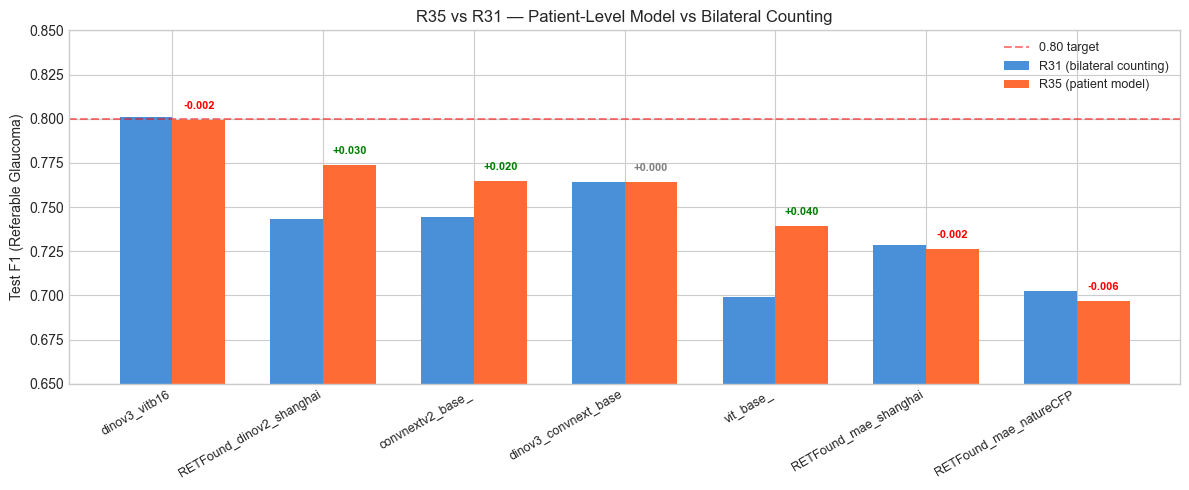


Done!


In [8]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 8 — R35 vs R31 Comparison
# ═══════════════════════════════════════════════════════════════════════

# R31 known results
r31_known = {
    'dinov3_vitb16':              0.8009,
    'dinov3_convnext_base':       0.7640,
    'convnextv2_base_':           0.7445,
    'RETFound_dinov2_shanghai':   0.7435,
    'RETFound_mae_shanghai':      0.7286,
    'RETFound_mae_natureCFP':     0.7025,
    'vit_base_':                  0.6992,
}

# Build comparison table
comp_rows = []
for _, row in r35_df.iterrows():
    enc = row['embedding']
    r31_f1 = r31_known.get(enc, np.nan)
    delta = row['test_f1'] - r31_f1 if not np.isnan(r31_f1) else np.nan
    comp_rows.append({
        'Encoder': enc,
        'R31_F1': r31_f1,
        'R35_F1': row['test_f1'],
        'Delta': delta,
        'R35_Method': row['best_method'],
        'D1_flex': row.get('d1_val_f1', 0),
        'D2_logr': row.get('d2_val_f1', 0),
        'D3_lgbm': row.get('d3_val_f1', 0),
        'R35_Prec': row['test_prec'],
        'R35_Rec': row['test_rec'],
        'R35_AUC': row['test_auc'],
    })

comp_df = pd.DataFrame(comp_rows).sort_values('R35_F1', ascending=False)
comp_df.to_csv(R35_DIR / 'r35_vs_r31_comparison.csv', index=False)

print('═' * 90)
print('R35 vs R31 — Comparison')
print('═' * 90)
print(comp_df.to_string(index=False, float_format='%.4f'))
print()

# Highlight improvements
n_improved = (comp_df['Delta'] > 0.001).sum()
n_above_80 = (comp_df['R35_F1'] >= 0.80).sum()
best_enc = comp_df.iloc[0]
print(f'Encoders improved over R31: {n_improved}/{len(comp_df)}')
print(f'Encoders ≥ 0.80 F1:        {n_above_80}/{len(comp_df)}')
print(f'Best: {best_enc["Encoder"]} F1={best_enc["R35_F1"]:.4f} ({best_enc["R35_Method"]})')

# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 5))
enc_labels = comp_df['Encoder'].values
x = np.arange(len(enc_labels))
w = 0.35
ax.bar(x - w/2, comp_df['R31_F1'].values, w, label='R31 (bilateral counting)', color='#4A90D9')
ax.bar(x + w/2, comp_df['R35_F1'].values, w, label='R35 (patient model)', color='#FF6B35')
ax.axhline(y=0.80, color='red', linestyle='--', alpha=0.5, label='0.80 target')
ax.set_xticks(x)
ax.set_xticklabels(enc_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Test F1 (Referable Glaucoma)')
ax.set_title('R35 vs R31 — Patient-Level Model vs Bilateral Counting')
ax.legend(fontsize=9)
ax.set_ylim(0.65, 0.85)
for i, (r31v, r35v) in enumerate(zip(comp_df['R31_F1'], comp_df['R35_F1'])):
    delta = r35v - r31v
    color = 'green' if delta > 0.001 else ('red' if delta < -0.001 else 'gray')
    ax.text(i + w/2, r35v + 0.005, f'{delta:+.3f}', ha='center', va='bottom',
            fontsize=8, color=color, fontweight='bold')
plt.tight_layout()
fig.savefig(R35_DIR / 'r35_vs_r31_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

print('\nDone!')

# R36 — Richer Patient Features + Bootstrap Threshold Stabilization

**Changes vs R35:**
1. **Option D — 4 new patient features** (total 14):
   - `asymmetry_ratio`: `|eye1 - eye2| / (max + ε)` — directly targets bilateral disagreement
   - `cal_raw_gap`: `|calibrated - raw|` mean per patient — flags unreliable preds
   - `max_minus_mean`: how much the best eye stands out
   - `emb_dist_to_pos_centroid`: cosine distance to positive-class centroid in PCA space
2. **Option B — Bootstrap threshold stabilization**: resample val 200× → median threshold (reduces 5-8% val→test gap)
3. **Hybrid selection**: prefer D1 when val F1 is within 0.01 of best model (preserves dinov3_vitb16's 0.8009)

**Stage 1 unchanged**: Same R28 params → 25-bag ensemble → isotonic calibration

In [9]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 10 — R36 Helpers: Richer Features + Bootstrap Threshold
# ═══════════════════════════════════════════════════════════════════════
from sklearn.metrics.pairwise import cosine_distances

# ─── Extended patient feature columns (14 total) ─────────────────
R36_PATIENT_FEATURE_COLS = [
    # R35 originals (10)
    'max_proba', 'second_max', 'mean_proba', 'min_proba',
    'std_proba', 'n_eyes', 'proba_range',
    'n_above_02', 'n_above_03', 'n_above_05',
    # R36 NEW (4)
    'asymmetry_ratio', 'cal_raw_gap', 'max_minus_mean',
    'emb_dist_to_pos_centroid',
]

# ─── R36 Results dir ─────────────────────────────────────────────
R36_DIR = RESULTS_DIR / 'r36_per_encoder'
R36_DIR.mkdir(parents=True, exist_ok=True)

# ─── Bootstrap config ────────────────────────────────────────────
BOOTSTRAP_N = 200
BOOTSTRAP_SEED = 42

# ─── Hybrid selection margin ─────────────────────────────────────
HYBRID_MARGIN = 0.01  # prefer D1 when within this of best model


def extract_patient_features_r36(pids, probas_raw, probas_cal,
                                  emb_pca, pos_centroid):
    """
    Extract 14 patient-level features.
    New vs R35: asymmetry_ratio, cal_raw_gap, max_minus_mean,
                emb_dist_to_pos_centroid.
    """
    eps = 1e-8

    df = pd.DataFrame({
        'patient_id': pids,
        'proba_raw': probas_raw,
        'proba_cal': probas_cal,
    })

    # ── Per-eye embedding distance to positive centroid ───────────
    dists = cosine_distances(emb_pca, pos_centroid.reshape(1, -1)).ravel()
    df['emb_dist'] = dists

    # ── Base aggregations (same as R35) ───────────────────────────
    agg = df.groupby('patient_id').agg(
        max_proba     = ('proba_raw', 'max'),
        mean_proba    = ('proba_raw', 'mean'),
        min_proba     = ('proba_raw', 'min'),
        std_proba     = ('proba_raw', 'std'),
        n_eyes        = ('proba_raw', 'count'),
    )
    agg['std_proba'] = agg['std_proba'].fillna(0)

    def _second_max(x):
        vals = sorted(x.values, reverse=True)
        return vals[1] if len(vals) >= 2 else vals[0]
    agg['second_max'] = df.groupby('patient_id')['proba_raw'].apply(_second_max)

    agg['proba_range']  = agg['max_proba'] - agg['min_proba']
    agg['n_above_02']   = df.groupby('patient_id')['proba_raw'].apply(lambda x: (x >= 0.2).sum())
    agg['n_above_03']   = df.groupby('patient_id')['proba_raw'].apply(lambda x: (x >= 0.3).sum())
    agg['n_above_05']   = df.groupby('patient_id')['proba_raw'].apply(lambda x: (x >= 0.5).sum())

    # ── NEW: asymmetry_ratio ──────────────────────────────────────
    # |max - second_max| / (max + eps)  — measures bilateral disagreement
    agg['asymmetry_ratio'] = (
        (agg['max_proba'] - agg['second_max']).abs()
        / (agg['max_proba'] + eps)
    )

    # ── NEW: cal_raw_gap ──────────────────────────────────────────
    # Mean |calibrated - raw| per patient — flags unreliable predictions
    df['cal_raw_diff'] = (df['proba_cal'] - df['proba_raw']).abs()
    agg['cal_raw_gap'] = df.groupby('patient_id')['cal_raw_diff'].mean()

    # ── NEW: max_minus_mean ───────────────────────────────────────
    agg['max_minus_mean'] = agg['max_proba'] - agg['mean_proba']

    # ── NEW: emb_dist_to_pos_centroid ─────────────────────────────
    # Mean cosine distance of patient's eyes to positive centroid
    agg['emb_dist_to_pos_centroid'] = df.groupby('patient_id')['emb_dist'].mean()

    return agg


def bootstrap_threshold(y_true, probas, n_boot=200, grid_size=181,
                        rng_seed=42):
    """
    Resample val set n_boot times, find optimal F1 threshold each time,
    return the median threshold (more robust than single-split).
    """
    rng = np.random.default_rng(rng_seed)
    n = len(y_true)
    thresholds = np.linspace(0.05, 0.95, grid_size)
    best_ts = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_b = y_true[idx]
        p_b = probas[idx]
        best_f1, best_t = 0.0, 0.5
        for t in thresholds:
            preds = (p_b >= t).astype(int)
            f1 = f1_score(y_b, preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_ts.append(best_t)

    return float(np.median(best_ts))


def bootstrap_bilateral_threshold(pids, probas, y_ref_patient,
                                   min_eyes=2, n_boot=200,
                                   grid_size=301, floor=0.05,
                                   rng_seed=42):
    """
    Bootstrap threshold for bilateral sweep.
    Resample patients (not eyes), find optimal threshold each time.
    """
    rng = np.random.default_rng(rng_seed)
    com = pd.Index(np.intersect1d(np.unique(pids), y_ref_patient.index))
    n = len(com)
    thresholds = np.linspace(floor, 0.99, grid_size)

    # Pre-build per-patient aggregation
    eye_df = pd.DataFrame({'patient_id': pids, 'proba': probas})

    best_ts = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_pids = com[idx]
        # Count per-patient occurrences in bootstrap sample
        pid_counts = pd.Series(boot_pids).value_counts()

        best_f1, best_t = 0.0, 0.5
        for t in thresholds:
            agg = bilateral_patient_predictions(pids, probas, t, min_eyes)
            boot_agg = agg.reindex(boot_pids)
            yt = y_ref_patient.reindex(boot_pids).values
            yh = boot_agg['referable_pred'].values
            valid = ~np.isnan(yt) & ~np.isnan(yh)
            if valid.sum() == 0:
                continue
            f1 = f1_score(yt[valid].astype(int), yh[valid].astype(int),
                          zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_ts.append(best_t)

    return float(np.median(best_ts))


def train_patient_logreg_r36(X_tr, y_tr, X_va, y_va, C_values,
                              threshold_grid, n_boot=200, rng_seed=42):
    """
    Train LogReg with bootstrap threshold stabilization.
    1. Sweep C: find best C by bootstrap-stabilized val F1.
    2. For best C: compute bootstrap median threshold.
    """
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    best_vf1, best_C = 0.0, 1.0
    best_model = None

    for C in C_values:
        lr = LogisticRegression(
            C=C, class_weight='balanced', max_iter=1000,
            solver='lbfgs', random_state=42,
        )
        lr.fit(X_tr_s, y_tr)
        val_proba = lr.predict_proba(X_va_s)[:, 1]

        # Bootstrap-stabilized threshold
        bt = bootstrap_threshold(y_va, val_proba, n_boot=n_boot,
                                  grid_size=threshold_grid,
                                  rng_seed=rng_seed)
        preds = (val_proba >= bt).astype(int)
        f1 = f1_score(y_va, preds, zero_division=0)

        if f1 > best_vf1:
            best_vf1, best_C = f1, C
            best_model = lr

    # Final bootstrap threshold for best C
    val_proba = best_model.predict_proba(X_va_s)[:, 1]
    best_t = bootstrap_threshold(y_va, val_proba, n_boot=n_boot,
                                  grid_size=threshold_grid,
                                  rng_seed=rng_seed)
    preds = (val_proba >= best_t).astype(int)
    best_vf1 = f1_score(y_va, preds, zero_division=0)

    return best_model, best_C, best_t, best_vf1, scaler


def train_patient_lgbm_r36(X_tr, y_tr, X_va, y_va, lgb_params,
                             threshold_grid, n_boot=200, rng_seed=42):
    """
    Train LightGBM with bootstrap threshold stabilization.
    """
    pos_w = max(1.0, (y_tr == 0).sum() / max(1, (y_tr == 1).sum()))
    params = {**lgb_params, 'scale_pos_weight': pos_w}
    params.pop('class_weight', None)

    model = lgb.LGBMClassifier(**params)
    model.fit(X_tr, y_tr)
    val_proba = model.predict_proba(X_va)[:, 1]

    best_t = bootstrap_threshold(y_va, val_proba, n_boot=n_boot,
                                  grid_size=threshold_grid,
                                  rng_seed=rng_seed)
    preds = (val_proba >= best_t).astype(int)
    best_vf1 = f1_score(y_va, preds, zero_division=0)

    return model, best_t, best_vf1


print(f'R36 helpers OK')
print(f'  Patient features: {len(R36_PATIENT_FEATURE_COLS)} cols (10 R35 + 4 new)')
print(f'  Bootstrap: {BOOTSTRAP_N} resamples')
print(f'  Hybrid margin: {HYBRID_MARGIN} (prefer D1 when within this of best model)')
print(f'  Results dir: {R36_DIR}')

R36 helpers OK
  Patient features: 14 cols (10 R35 + 4 new)
  Bootstrap: 200 resamples
  Hybrid margin: 0.01 (prefer D1 when within this of best model)
  Results dir: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r35_patient_model_cascade\r36_per_encoder


════════════════════════════════════════════════════════════════════════════════
R36 — Richer Features + Bootstrap Threshold Stabilization
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
[1/7] R36 — convnextv2_base_
  R28 hypers: arch=(128,) α=1.0000 lr=0.000100 bs=64 w=4.07
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.8% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Stage B] 25 models (R28 hypers, no search)
  Stage B done: 25 MLPs trained
  Per-image proba range: val=[0.001, 0.999]  test=[0.001, 0.999]
  Stage C: 14 patient features extracted (10 R35 + 4 new)
    Train: 5796 patients (789 referable, 13.6%)
    Val:   1023 patients (157 referable)
    Test:  1705 patients (229 referable)
  [D1] Flexible bilateral sweep + bootstrap (200 resamples)
    D1 best: min_eyes=2, thr=0.432→0.439(boot), proba=raw

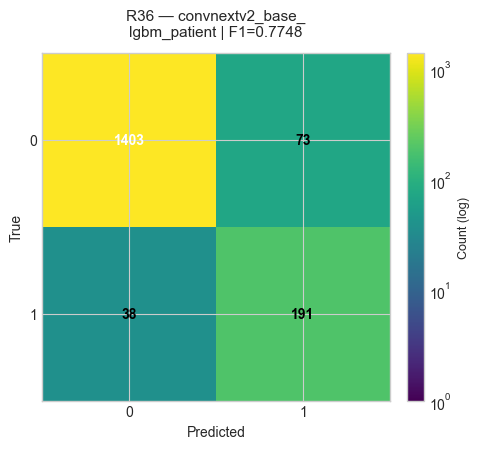

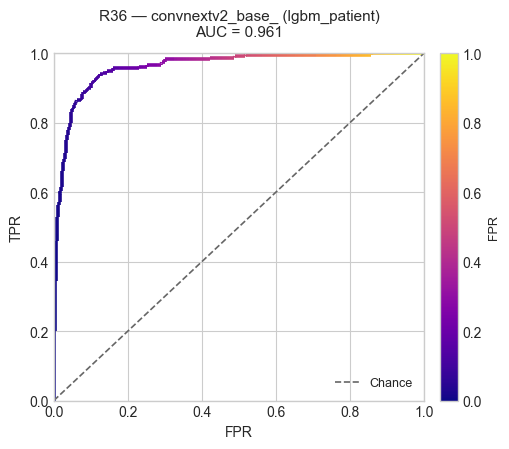


════════════════════════════════════════════════════════════════════════════════
[2/7] R36 — dinov3_convnext_base
  R28 hypers: arch=(128,) α=1.0000 lr=0.000358 bs=64 w=2.46
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (99.5% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Stage B] 25 models (R28 hypers, no search)
  Stage B done: 25 MLPs trained
  Per-image proba range: val=[0.001, 0.988]  test=[0.001, 0.999]
  Stage C: 14 patient features extracted (10 R35 + 4 new)
    Train: 5796 patients (789 referable, 13.6%)
    Val:   1023 patients (157 referable)
    Test:  1705 patients (229 referable)
  [D1] Flexible bilateral sweep + bootstrap (200 resamples)
    D1 best: min_eyes=2, thr=0.429→0.429(boot), proba=raw → val_F1=0.8000, test_F1=0.7640
  [D2] Patient LogReg (14 feats, C=[0.01, 0.1, 1.0, 10.0], bootstrap thr)
    D2 best: C=1.0, thr=0.835(boot) → val_F1=0.8117, test_F1=0.7851
  [D3] Patient LightGBM (14 feats, bootst

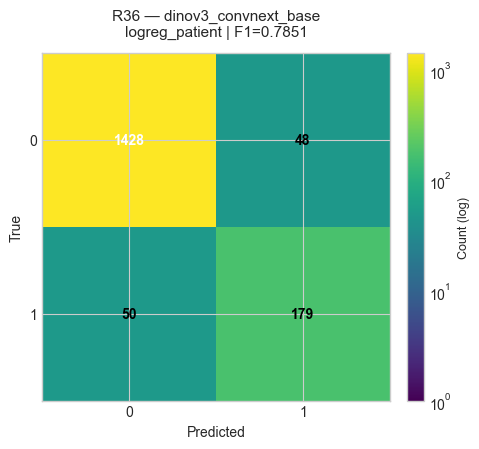

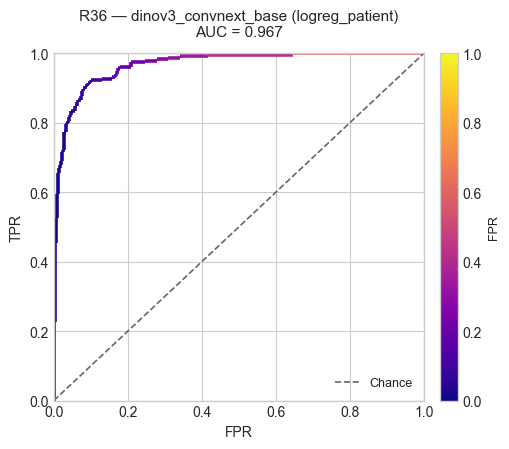


════════════════════════════════════════════════════════════════════════════════
[3/7] R36 — dinov3_vitb16
  R28 hypers: arch=(128,) α=1.0000 lr=0.000301 bs=256 w=2.45
════════════════════════════════════════════════════════════════════════════════
  PCA: 768→384 (98.7% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Stage B] 25 models (R28 hypers, no search)
  Stage B done: 25 MLPs trained
  Per-image proba range: val=[0.001, 0.999]  test=[0.001, 0.999]
  Stage C: 14 patient features extracted (10 R35 + 4 new)
    Train: 5796 patients (789 referable, 13.6%)
    Val:   1023 patients (157 referable)
    Test:  1705 patients (229 referable)
  [D1] Flexible bilateral sweep + bootstrap (200 resamples)
    D1 best: min_eyes=2, thr=0.294→0.294(boot), proba=raw → val_F1=0.8444, test_F1=0.8009
  [D2] Patient LogReg (14 feats, C=[0.01, 0.1, 1.0, 10.0], bootstrap thr)
    D2 best: C=0.1, thr=0.290(boot) → val_F1=0.8444, test_F1=0.7948
  [D3] Patient LightGBM (14 feats, bootstrap thr

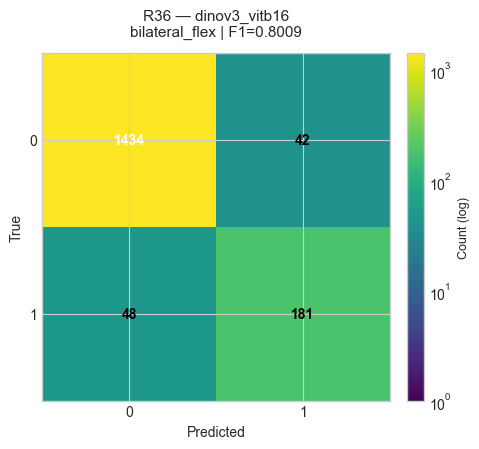

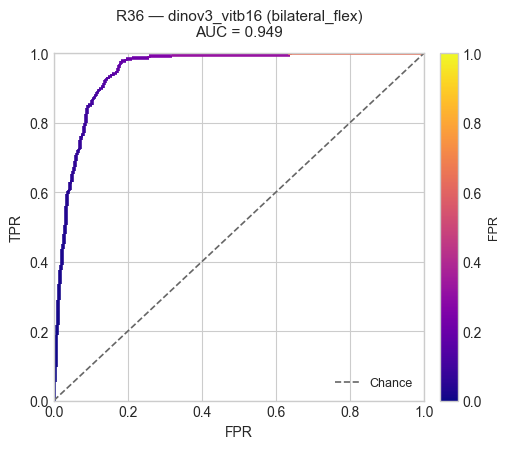


════════════════════════════════════════════════════════════════════════════════
[4/7] R36 — RETFound_dinov2_shanghai
  R28 hypers: arch=(512,) α=1.0000 lr=0.000100 bs=64 w=2.91
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.2% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Stage B] 25 models (R28 hypers, no search)
  Stage B done: 25 MLPs trained
  Per-image proba range: val=[0.001, 0.999]  test=[0.001, 0.999]
  Stage C: 14 patient features extracted (10 R35 + 4 new)
    Train: 5796 patients (789 referable, 13.6%)
    Val:   1023 patients (157 referable)
    Test:  1705 patients (229 referable)
  [D1] Flexible bilateral sweep + bootstrap (200 resamples)
    D1 best: min_eyes=2, thr=0.301→0.319(boot), proba=raw → val_F1=0.7964, test_F1=0.7514
  [D2] Patient LogReg (14 feats, C=[0.01, 0.1, 1.0, 10.0], bootstrap thr)
    D2 best: C=10.0, thr=0.630(boot) → val_F1=0.8276, test_F1=0.7787
  [D3] Patient LightGBM (14 feats, b

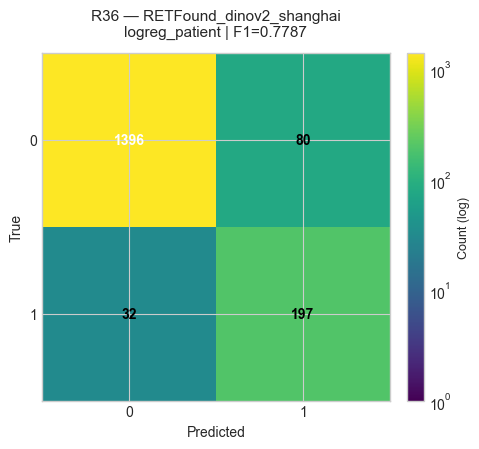

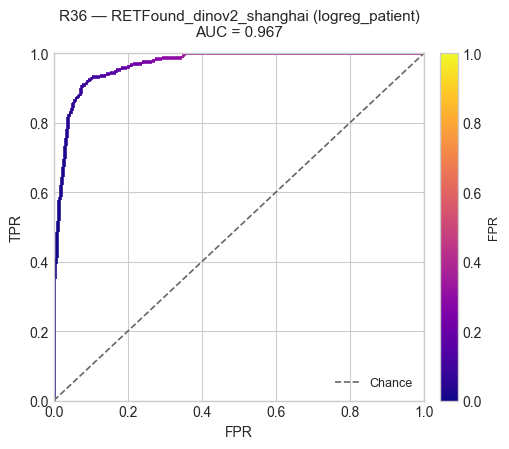


════════════════════════════════════════════════════════════════════════════════
[5/7] R36 — RETFound_mae_natureCFP
  R28 hypers: arch=(512,) α=0.0010 lr=0.000210 bs=64 w=3.37
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (99.3% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Stage B] 25 models (R28 hypers, no search)
  Stage B done: 25 MLPs trained
  Per-image proba range: val=[0.001, 0.999]  test=[0.001, 0.985]
  Stage C: 14 patient features extracted (10 R35 + 4 new)
    Train: 5796 patients (789 referable, 13.6%)
    Val:   1023 patients (157 referable)
    Test:  1705 patients (229 referable)
  [D1] Flexible bilateral sweep + bootstrap (200 resamples)


KeyboardInterrupt: 

In [10]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 11 — R36 Per-Encoder Main Loop
# ═══════════════════════════════════════════════════════════════════════

print('═' * 80)
print('R36 — Richer Features + Bootstrap Threshold Stabilization')
print('═' * 80)

r36_results = []
t0_global = time.time()

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)

    # ── Checkpoint: skip if results already exist ──────────────────
    chk_dir = R36_DIR / f'{emb_idx:02d}_{sname}'
    chk_hp  = chk_dir / 'hyperparameters.json'
    if chk_hp.exists():
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — CACHED, loading')
        with open(chk_hp) as _f:
            prev = json.load(_f)
        r36_results.append({
            'embedding':   sname,
            'best_method': prev.get('best_method', '?'),
            'val_f1':      prev['val_referable_f1'],
            'test_f1':     prev['test_referable_f1'],
            'test_prec':   prev['test_referable_precision'],
            'test_rec':    prev['test_referable_recall'],
            'test_auc':    prev['test_referable_auc'],
            'test_ba':     prev['test_referable_bal_acc'],
            'd1_val_f1':   prev.get('d1_flex_val_f1', 0),
            'd2_val_f1':   prev.get('d2_logreg_val_f1', 0),
            'd3_val_f1':   prev.get('d3_lgbm_val_f1', 0),
            'time_s': 0,
        })
        continue

    # ── Check R28 hyperparameters ─────────────────────────────────
    if sname not in r28_hypers:
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — SKIPPED, no R28 hypers')
        continue

    hp = r28_hypers[sname]
    barch  = ast.literal_eval(hp['architecture']) if isinstance(hp['architecture'], str) else tuple(hp['architecture'])
    balpha = hp['alpha']
    blr    = hp['lr']
    bbs    = hp['batch_size']
    bw     = hp['pos_weight']

    print(f'\n{"═"*80}')
    print(f'[{emb_idx+1}/{len(embedding_files)}] R36 — {sname}')
    print(f'  R28 hypers: arch={barch} α={balpha:.4f} lr={blr:.6f} bs={bbs} w={bw:.2f}')
    print(f'{"═"*80}')
    t0 = time.time()

    # ══════════════════════════════════════════════════════════════
    # STAGE A: Feature prep (identical to R31/R35)
    # ══════════════════════════════════════════════════════════════

    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)

    b_train = df[df['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
    b_val   = df[df['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
    b_test  = df[df['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()

    X_tr_emb = b_train[ds.feature_cols].to_numpy(dtype=np.float32)
    X_va_emb = b_val[ds.feature_cols].to_numpy(dtype=np.float32)
    X_te_emb = b_test[ds.feature_cols].to_numpy(dtype=np.float32)

    yb_train = b_train[TASK].to_numpy(dtype=int)
    yb_val   = b_val[TASK].to_numpy(dtype=int)
    yb_test  = b_test[TASK].to_numpy(dtype=int)

    pids_tr = b_train['patient_id'].to_numpy()
    pids_va = b_val['patient_id'].to_numpy()
    pids_te = b_test['patient_id'].to_numpy()

    emb_dim_raw = X_tr_emb.shape[1]

    # ── PCA ───────────────────────────────────────────────────────
    nc = min(PCA_COMPONENTS, emb_dim_raw, X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca.fit_transform(X_tr_emb)
    X_va_pca = pca.transform(X_va_emb)
    X_te_pca = pca.transform(X_te_emb)
    var_exp = pca.explained_variance_ratio_.sum()
    print(f'  PCA: {emb_dim_raw}→{nc} ({var_exp:.1%} var)')

    # ── MI Selection ──────────────────────────────────────────────
    if MI_SELECTION:
        X_tr_sel, (X_va_sel, X_te_sel), mi_mask, _ = mi_select_features(
            X_tr_pca, yb_train, [X_va_pca, X_te_pca],
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS,
            random_state=RANDOM_SEED,
        )
        n_kept = mi_mask.sum()
        print(f'  MI: {nc}→{n_kept}')
    else:
        X_tr_sel, X_va_sel, X_te_sel = X_tr_pca, X_va_pca, X_te_pca
        n_kept = nc

    # ── Metadata ──────────────────────────────────────────────────
    X_tr_meta, ms = encode_metadata(b_train, METADATA_COLS)
    X_va_meta, _  = encode_metadata(b_val, METADATA_COLS, fit_stats=ms)
    X_te_meta, _  = encode_metadata(b_test, METADATA_COLS, fit_stats=ms)
    meta_dim = X_tr_meta.shape[1]

    # ── OD masking ────────────────────────────────────────────────
    rng_hp = np.random.default_rng(RANDOM_SEED)
    od_tr, miss_tr = _mask_od(b_train['optic_disc'], OD_P_MASK_BASE, rng_hp, OD_CORRUPT)
    X_tr_full = np.hstack([X_tr_sel, X_tr_meta, od_tr, miss_tr])
    ndim = X_tr_full.shape[1]
    print(f'  Dims: {n_kept} PCA + {meta_dim} meta + 2 OD = {ndim}')

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_full)
    X_tr_s = _apply_od_weights(X_tr_s, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    rng_v = np.random.default_rng(RANDOM_SEED + 7000)
    rng_t = np.random.default_rng(RANDOM_SEED + 9999)
    od_v, miss_v = _mask_od(b_val['optic_disc'],  OD_TEST_P_MASK, rng_v)
    od_t, miss_t = _mask_od(b_test['optic_disc'], OD_TEST_P_MASK, rng_t)

    X_va_s = scaler.transform(np.hstack([X_va_sel, X_va_meta, od_v, miss_v]))
    X_te_s = scaler.transform(np.hstack([X_te_sel, X_te_meta, od_t, miss_t]))
    X_va_s = _apply_od_weights(X_va_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
    X_te_s = _apply_od_weights(X_te_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # ══════════════════════════════════════════════════════════════
    # STAGE B: 25-Bag Ensemble (identical to R31/R35)
    # ══════════════════════════════════════════════════════════════
    barchs = [barch, make_wider(barch), make_deeper(barch),
              make_narrower(barch), make_shallower(barch)]
    print(f'  [Stage B] {N_BAGS} models (R28 hypers, no search)')

    cal_p = {}
    cal_l = {}
    bag_tr_proba = []
    bag_va_proba = []
    bag_te_proba = []

    for s_idx, seed in enumerate(BAG_SEEDS):
        upids = np.unique(pids_tr)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
        plm = b_train.groupby('patient_id')[TASK].max().to_dict()
        pl  = np.array([plm[p] for p in upids])
        ti, vi = next(sss.split(upids, pl))
        itr_pids = set(upids[ti])
        iva_pids = set(upids[vi])

        tr_m = np.isin(pids_tr, list(itr_pids))
        va_m = np.isin(pids_tr, list(iva_pids))

        rng_pm = np.random.default_rng(seed + 90000)
        pm_seed = float(rng_pm.uniform(OD_P_MASK_RANGE[0], OD_P_MASK_RANGE[1]))

        rng_it = np.random.default_rng(seed + 10000)
        od_it, miss_it = _mask_od(
            b_train.iloc[np.where(tr_m)[0]]['optic_disc'], pm_seed, rng_it, OD_CORRUPT)
        X_it = scaler.transform(np.hstack([X_tr_sel[tr_m], X_tr_meta[tr_m], od_it, miss_it]))
        X_it = _apply_od_weights(X_it, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_it = yb_train[tr_m]

        rng_iv = np.random.default_rng(seed + 20000)
        od_iv, miss_iv = _mask_od(
            b_train.iloc[np.where(va_m)[0]]['optic_disc'], pm_seed, rng_iv, OD_CORRUPT)
        X_iv = scaler.transform(np.hstack([X_tr_sel[va_m], X_tr_meta[va_m], od_iv, miss_iv]))
        X_iv = _apply_od_weights(X_iv, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_iv = yb_train[va_m]

        svp = []
        for a_idx, arch_v in enumerate(barchs):
            mlp = MLPClassifier(
                hidden_layer_sizes=arch_v, alpha=balpha,
                learning_rate='adaptive',
                learning_rate_init=blr, batch_size=bbs,
                max_iter=MLP_MAX_ITER, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=MLP_PATIENCE,
                random_state=seed + a_idx,
            )
            sw = make_sample_weights(y_it, bw)
            mlp.fit(X_it, y_it, sample_weight=sw)

            svp.append(mlp.predict_proba(X_iv)[:, 1])
            bag_tr_proba.append(mlp.predict_proba(X_tr_s)[:, 1])
            bag_va_proba.append(mlp.predict_proba(X_va_s)[:, 1])
            bag_te_proba.append(mlp.predict_proba(X_te_s)[:, 1])

        cal_p[seed] = np.mean(svp, axis=0)
        cal_l[seed] = y_iv

    # ── Calibration ───────────────────────────────────────────────
    cp = np.concatenate([cal_p[s] for s in BAG_SEEDS])
    cl = np.concatenate([cal_l[s] for s in BAG_SEEDS])
    iso = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')
    iso.fit(cp, cl)

    avg_tr_raw = np.mean(bag_tr_proba, axis=0)
    avg_va_raw = np.mean(bag_va_proba, axis=0)
    avg_te_raw = np.mean(bag_te_proba, axis=0)
    avg_tr_cal = iso.predict(avg_tr_raw)
    avg_va_cal = iso.predict(avg_va_raw)
    avg_te_cal = iso.predict(avg_te_raw)

    print(f'  Stage B done: {N_BAGS} MLPs trained')
    print(f'  Per-image proba range: val=[{avg_va_cal.min():.3f}, {avg_va_cal.max():.3f}]  '
          f'test=[{avg_te_cal.min():.3f}, {avg_te_cal.max():.3f}]')

    # ══════════════════════════════════════════════════════════════
    # STAGE C: Patient-level feature extraction (R36 — 14 features)
    # ══════════════════════════════════════════════════════════════

    # Positive centroid in PCA space (computed on train only)
    pos_mask_tr = yb_train == 1
    pos_centroid = X_tr_pca[pos_mask_tr].mean(axis=0)

    ref_train = build_referable_labels(b_train, TASK, BILATERAL_MIN_EYES)
    ref_val   = build_referable_labels(b_val, TASK, BILATERAL_MIN_EYES)
    ref_test  = build_referable_labels(b_test, TASK, BILATERAL_MIN_EYES)

    pf_train = extract_patient_features_r36(pids_tr, avg_tr_raw, avg_tr_cal,
                                             X_tr_pca, pos_centroid)
    pf_val   = extract_patient_features_r36(pids_va, avg_va_raw, avg_va_cal,
                                             X_va_pca, pos_centroid)
    pf_test  = extract_patient_features_r36(pids_te, avg_te_raw, avg_te_cal,
                                             X_te_pca, pos_centroid)

    com_tr = pf_train.index.intersection(ref_train.index)
    com_va = pf_val.index.intersection(ref_val.index)
    com_te = pf_test.index.intersection(ref_test.index)

    X_pat_tr = pf_train.loc[com_tr][R36_PATIENT_FEATURE_COLS].values.astype(np.float32)
    y_pat_tr = ref_train.loc[com_tr].values.astype(int)
    X_pat_va = pf_val.loc[com_va][R36_PATIENT_FEATURE_COLS].values.astype(np.float32)
    y_pat_va = ref_val.loc[com_va].values.astype(int)
    X_pat_te = pf_test.loc[com_te][R36_PATIENT_FEATURE_COLS].values.astype(np.float32)
    y_pat_te = ref_test.loc[com_te].values.astype(int)

    print(f'  Stage C: 14 patient features extracted (10 R35 + 4 new)')
    print(f'    Train: {len(com_tr)} patients ({y_pat_tr.sum()} referable, {y_pat_tr.mean():.1%})')
    print(f'    Val:   {len(com_va)} patients ({y_pat_va.sum()} referable)')
    print(f'    Test:  {len(com_te)} patients ({y_pat_te.sum()} referable)')

    # ══════════════════════════════════════════════════════════════
    # STAGE D: Three methods + hybrid selection
    # ══════════════════════════════════════════════════════════════

    methods = {}

    # ── D1: Flexible bilateral with bootstrap threshold ───────────
    print(f'  [D1] Flexible bilateral sweep + bootstrap ({BOOTSTRAP_N} resamples)')
    d1_best_f1, d1_best_t, d1_best_me, d1_best_pt = 0.0, 0.5, 2, 'raw'

    for pt_name, va_p, te_p in [
        ('cal', avg_va_cal, avg_te_cal),
        ('raw', avg_va_raw, avg_te_raw),
    ]:
        for me in FLEX_MIN_EYES:
            # Standard sweep to find best config
            bt, bf1, _ = sweep_bilateral_threshold(
                pids_va, va_p, ref_val,
                min_eyes=me, grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR,
            )
            if bf1 > d1_best_f1:
                d1_best_f1, d1_best_t, d1_best_me, d1_best_pt = bf1, bt, me, pt_name

    # Bootstrap-stabilize the threshold for the best config
    d1_va_p = avg_va_cal if d1_best_pt == 'cal' else avg_va_raw
    d1_boot_t = bootstrap_bilateral_threshold(
        pids_va, d1_va_p, ref_val,
        min_eyes=d1_best_me, n_boot=BOOTSTRAP_N,
        grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR,
        rng_seed=BOOTSTRAP_SEED,
    )

    # Evaluate D1 on test with bootstrap-stabilized threshold
    te_p_d1 = avg_te_cal if d1_best_pt == 'cal' else avg_te_raw
    d1_test_agg = bilateral_patient_predictions(pids_te, te_p_d1, d1_boot_t, d1_best_me)
    d1_com = d1_test_agg.index.intersection(ref_test.index)
    d1_yt = ref_test.loc[d1_com].values
    d1_yh = d1_test_agg.loc[d1_com, 'referable_pred'].values
    d1_yp = d1_test_agg.loc[d1_com, 'max_proba'].values
    d1_test_f1 = float(f1_score(d1_yt, d1_yh, zero_division=0))

    # Also compute val F1 at the bootstrapped threshold
    d1_va_agg = bilateral_patient_predictions(pids_va, d1_va_p, d1_boot_t, d1_best_me)
    d1_va_com = d1_va_agg.index.intersection(ref_val.index)
    d1_va_yt = ref_val.loc[d1_va_com].values
    d1_va_yh = d1_va_agg.loc[d1_va_com, 'referable_pred'].values
    d1_boot_val_f1 = float(f1_score(d1_va_yt, d1_va_yh, zero_division=0))

    methods['bilateral_flex'] = {
        'val_f1': d1_boot_val_f1, 'test_f1': d1_test_f1,
        'yt': d1_yt, 'yh': d1_yh, 'yp': d1_yp,
        'com': d1_com,
        'detail': f'min_eyes={d1_best_me}, thr={d1_boot_t:.3f}(boot), proba={d1_best_pt}',
    }
    print(f'    D1 best: min_eyes={d1_best_me}, thr={d1_best_t:.3f}→{d1_boot_t:.3f}(boot), '
          f'proba={d1_best_pt} → val_F1={d1_boot_val_f1:.4f}, test_F1={d1_test_f1:.4f}')

    # ── D2: Patient LogReg (14 features + bootstrap threshold) ────
    print(f'  [D2] Patient LogReg (14 feats, C={LR_C_VALUES}, bootstrap thr)')
    lr_model, lr_C, lr_t, lr_val_f1, lr_scaler = train_patient_logreg_r36(
        X_pat_tr, y_pat_tr, X_pat_va, y_pat_va,
        C_values=LR_C_VALUES, threshold_grid=181,
        n_boot=BOOTSTRAP_N, rng_seed=BOOTSTRAP_SEED,
    )
    lr_te_proba = lr_model.predict_proba(lr_scaler.transform(X_pat_te))[:, 1]
    lr_te_pred  = (lr_te_proba >= lr_t).astype(int)
    lr_test_f1  = float(f1_score(y_pat_te, lr_te_pred, zero_division=0))

    methods['logreg_patient'] = {
        'val_f1': lr_val_f1, 'test_f1': lr_test_f1,
        'yt': y_pat_te, 'yh': lr_te_pred, 'yp': lr_te_proba,
        'com': com_te, 'detail': f'C={lr_C}, thr={lr_t:.3f}(boot)',
    }
    print(f'    D2 best: C={lr_C}, thr={lr_t:.3f}(boot) → val_F1={lr_val_f1:.4f}, test_F1={lr_test_f1:.4f}')

    # ── D3: Patient LightGBM (14 features + bootstrap threshold) ──
    print(f'  [D3] Patient LightGBM (14 feats, bootstrap thr)')
    lgb_model, lgb_t, lgb_val_f1 = train_patient_lgbm_r36(
        X_pat_tr, y_pat_tr, X_pat_va, y_pat_va,
        lgb_params=LGB_PARAMS, threshold_grid=181,
        n_boot=BOOTSTRAP_N, rng_seed=BOOTSTRAP_SEED,
    )
    lgb_te_proba = lgb_model.predict_proba(X_pat_te)[:, 1]
    lgb_te_pred  = (lgb_te_proba >= lgb_t).astype(int)
    lgb_test_f1  = float(f1_score(y_pat_te, lgb_te_pred, zero_division=0))

    methods['lgbm_patient'] = {
        'val_f1': lgb_val_f1, 'test_f1': lgb_test_f1,
        'yt': y_pat_te, 'yh': lgb_te_pred, 'yp': lgb_te_proba,
        'com': com_te, 'detail': f'thr={lgb_t:.3f}(boot)',
    }
    print(f'    D3 best: thr={lgb_t:.3f}(boot) → val_F1={lgb_val_f1:.4f}, test_F1={lgb_test_f1:.4f}')

    # ── Hybrid selection: prefer D1 when close to best ────────────
    model_best_name = max(methods, key=lambda k: methods[k]['val_f1'])
    model_best_vf1  = methods[model_best_name]['val_f1']
    d1_vf1 = methods['bilateral_flex']['val_f1']

    if (model_best_vf1 - d1_vf1) < HYBRID_MARGIN and d1_vf1 > 0:
        best_name = 'bilateral_flex'
        print(f'\n  ★ HYBRID: D1 val_F1={d1_vf1:.4f} within {HYBRID_MARGIN} of '
              f'{model_best_name}={model_best_vf1:.4f} → prefer simpler D1')
    else:
        best_name = model_best_name
    best = methods[best_name]
    print(f'  ★ BEST METHOD: {best_name} | val_F1={best["val_f1"]:.4f} | test_F1={best["test_f1"]:.4f}')
    print(f'    {best["detail"]}')

    # ══════════════════════════════════════════════════════════════
    # STAGE E: Final evaluation + save
    # ══════════════════════════════════════════════════════════════

    yt = best['yt']
    yh = best['yh']
    yp = best['yp']

    test_f1   = float(f1_score(yt, yh, zero_division=0))
    test_prec = float(precision_score(yt, yh, zero_division=0))
    test_rec  = float(recall_score(yt, yh, zero_division=0))
    test_auc  = float(roc_auc_score(yt, yp)) if len(np.unique(yt)) > 1 else 0.0
    test_ba   = float(balanced_accuracy_score(yt, yh))

    elapsed = time.time() - t0

    print(f'\n  TEST: F1={test_f1:.4f}  Prec={test_prec:.4f}  Rec={test_rec:.4f}  '
          f'AUC={test_auc:.4f}  BalAcc={test_ba:.4f}')
    print(f'  Time: {elapsed:.0f}s')

    # ── Save ──────────────────────────────────────────────────────
    out_dir = R36_DIR / f'{emb_idx:02d}_{sname}'
    out_dir.mkdir(parents=True, exist_ok=True)

    cm = confusion_matrix(yt, yh)
    rep = classification_report(yt, yh, digits=3,
                                target_names=['Not Referable', 'Referable'])
    print(rep)

    pd.DataFrame(cm).to_csv(out_dir / 'confusion_matrix.csv', index=False)
    (out_dir / 'classification_report.txt').write_text(rep, encoding='utf-8')

    fpr, tpr, _ = roc_curve(yt, yp)
    pd.DataFrame({'fpr': fpr, 'tpr': tpr}).to_csv(out_dir / 'roc_curve.csv', index=False)

    pd.DataFrame({
        'patient_id': best['com'],
        'y_true_referable': yt,
        'y_pred_referable': yh,
        'proba': yp,
    }).to_csv(out_dir / 'patient_predictions.csv', index=False)

    method_rows = []
    for mname, mdata in methods.items():
        method_rows.append({
            'method': mname, 'val_f1': mdata['val_f1'],
            'test_f1': mdata['test_f1'], 'detail': mdata['detail'],
            'is_best': mname == best_name,
        })
    pd.DataFrame(method_rows).to_csv(out_dir / 'method_comparison.csv', index=False)

    # LightGBM feature importance
    if hasattr(lgb_model, 'feature_importances_'):
        feat_imp = pd.DataFrame({
            'feature': R36_PATIENT_FEATURE_COLS,
            'importance': lgb_model.feature_importances_,
        }).sort_values('importance', ascending=False)
        feat_imp.to_csv(out_dir / 'lgbm_feature_importance.csv', index=False)
        print(f'  LGB top features: {", ".join(feat_imp.head(5)["feature"].tolist())}')

    hp_save = {
        'track': 'R36', 'embedding': sname,
        'best_method': best_name, 'method_detail': best['detail'],
        'r28_architecture': str(barch), 'r28_alpha': float(balpha),
        'r28_lr': float(blr), 'r28_batch_size': int(bbs),
        'r28_pos_weight': float(bw),
        'pca_dim': nc, 'mi_selected': int(n_kept), 'pca_var': float(var_exp),
        'emb_dim_raw': emb_dim_raw, 'ndim': ndim,
        'n_bags': N_BAGS,
        'n_patient_features': len(R36_PATIENT_FEATURE_COLS),
        'bootstrap_n': BOOTSTRAP_N,
        'hybrid_margin': HYBRID_MARGIN,
        'd1_flex_val_f1':   float(methods['bilateral_flex']['val_f1']),
        'd1_flex_test_f1':  float(methods['bilateral_flex']['test_f1']),
        'd1_min_eyes':      d1_best_me,
        'd1_threshold_raw': float(d1_best_t),
        'd1_threshold_boot':float(d1_boot_t),
        'd1_proba_type':    d1_best_pt,
        'd2_logreg_val_f1': float(methods['logreg_patient']['val_f1']),
        'd2_logreg_test_f1':float(methods['logreg_patient']['test_f1']),
        'd2_C':             float(lr_C),
        'd2_threshold':     float(lr_t),
        'd3_lgbm_val_f1':   float(methods['lgbm_patient']['val_f1']),
        'd3_lgbm_test_f1':  float(methods['lgbm_patient']['test_f1']),
        'd3_threshold':     float(lgb_t),
        'val_referable_f1':       float(best['val_f1']),
        'test_referable_f1':      test_f1,
        'test_referable_precision': test_prec,
        'test_referable_recall':  test_rec,
        'test_referable_auc':     test_auc,
        'test_referable_bal_acc': test_ba,
        'n_test_patients': int(len(yt)),
    }
    with open(out_dir / 'hyperparameters.json', 'w') as f:
        json.dump(hp_save, f, indent=2)

    plot_confusion_matrix(cm,
        title=f'R36 — {sname}\n{best_name} | F1={test_f1:.4f}',
        save_path=out_dir / 'confusion_matrix.png', show=True)
    plot_roc_curve(fpr, tpr, test_auc,
        title=f'R36 — {sname} ({best_name})',
        save_path=out_dir / 'roc_curve.png', show=True)

    r36_results.append({
        'embedding':   sname,
        'best_method': best_name,
        'val_f1':      float(best['val_f1']),
        'test_f1':     test_f1,
        'test_prec':   test_prec,
        'test_rec':    test_rec,
        'test_auc':    test_auc,
        'test_ba':     test_ba,
        'd1_val_f1':   float(methods['bilateral_flex']['val_f1']),
        'd2_val_f1':   float(methods['logreg_patient']['val_f1']),
        'd3_val_f1':   float(methods['lgbm_patient']['val_f1']),
        'time_s':      float(elapsed),
    })

total = time.time() - t0_global
print(f'\n{"═"*80}')
print(f'R36 complete! Total: {total:.0f}s ({total/60:.1f} min)')
print(f'{"═"*80}')

r36_df = pd.DataFrame(r36_results).sort_values('test_f1', ascending=False)
r36_df.to_csv(R36_DIR / 'r36_summary.csv', index=False)

print('\n── R36 Summary (sorted by Test F1) ──')
show_cols = ['embedding', 'best_method', 'val_f1', 'test_f1',
             'test_prec', 'test_rec', 'test_auc',
             'd1_val_f1', 'd2_val_f1', 'd3_val_f1']
print(r36_df[[c for c in show_cols if c in r36_df.columns]].to_string(index=False))

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 12 — R36 vs R35 vs R31 Comparison
# ═══════════════════════════════════════════════════════════════════════

r31_known = {
    'dinov3_vitb16':              0.8009,
    'dinov3_convnext_base':       0.7640,
    'convnextv2_base_':           0.7445,
    'RETFound_dinov2_shanghai':   0.7435,
    'RETFound_mae_shanghai':      0.7286,
    'RETFound_mae_natureCFP':     0.7025,
    'vit_base_':                  0.6992,
}

r35_known = {
    'dinov3_vitb16':              0.7991,
    'dinov3_convnext_base':       0.7640,
    'convnextv2_base_':           0.7649,
    'RETFound_dinov2_shanghai':   0.7738,
    'RETFound_mae_shanghai':      0.7264,
    'RETFound_mae_natureCFP':     0.6969,
    'vit_base_':                  0.7393,
}

comp_rows = []
for _, row in r36_df.iterrows():
    enc = row['embedding']
    r31v = r31_known.get(enc, np.nan)
    r35v = r35_known.get(enc, np.nan)
    comp_rows.append({
        'Encoder': enc,
        'R31_F1': r31v,
        'R35_F1': r35v,
        'R36_F1': row['test_f1'],
        'Δ_vs_R31': row['test_f1'] - r31v if not np.isnan(r31v) else np.nan,
        'Δ_vs_R35': row['test_f1'] - r35v if not np.isnan(r35v) else np.nan,
        'R36_Method': row['best_method'],
        'R36_Prec': row['test_prec'],
        'R36_Rec': row['test_rec'],
        'R36_AUC': row['test_auc'],
    })

comp_df = pd.DataFrame(comp_rows).sort_values('R36_F1', ascending=False)
comp_df.to_csv(R36_DIR / 'r36_vs_r35_vs_r31.csv', index=False)

print('═' * 100)
print('R36 vs R35 vs R31 — Comparison')
print('═' * 100)
print(comp_df.to_string(index=False, float_format='%.4f'))
print()

n_improved_r31 = (comp_df['Δ_vs_R31'] > 0.001).sum()
n_improved_r35 = (comp_df['Δ_vs_R35'] > 0.001).sum()
n_above_80 = (comp_df['R36_F1'] >= 0.80).sum()
best_enc = comp_df.iloc[0]
print(f'Improved over R31: {n_improved_r31}/{len(comp_df)}')
print(f'Improved over R35: {n_improved_r35}/{len(comp_df)}')
print(f'Encoders ≥ 0.80:  {n_above_80}/{len(comp_df)}')
print(f'Best: {best_enc["Encoder"]} F1={best_enc["R36_F1"]:.4f} ({best_enc["R36_Method"]})')

# ── Bar chart: R31 vs R35 vs R36 ──────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5.5))
enc_labels = comp_df['Encoder'].values
x = np.arange(len(enc_labels))
w = 0.25
ax.bar(x - w, comp_df['R31_F1'].values, w, label='R31 (bilateral)', color='#4A90D9')
ax.bar(x,     comp_df['R35_F1'].values, w, label='R35 (patient model)', color='#FF6B35')
ax.bar(x + w, comp_df['R36_F1'].values, w, label='R36 (richer + bootstrap)', color='#2ECC71')
ax.axhline(y=0.80, color='red', linestyle='--', alpha=0.5, label='0.80 target')
ax.set_xticks(x)
ax.set_xticklabels(enc_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Test F1 (Referable Glaucoma)')
ax.set_title('R36 vs R35 vs R31 — Richer Features + Bootstrap Threshold')
ax.legend(fontsize=9)
ax.set_ylim(0.65, 0.86)

for i, (r31v, r35v, r36v) in enumerate(
    zip(comp_df['R31_F1'], comp_df['R35_F1'], comp_df['R36_F1'])):
    delta = r36v - r31v
    color = 'green' if delta > 0.001 else ('red' if delta < -0.001 else 'gray')
    ax.text(i + w, r36v + 0.004, f'{delta:+.3f}', ha='center', va='bottom',
            fontsize=7.5, color=color, fontweight='bold')

plt.tight_layout()
fig.savefig(R36_DIR / 'r36_vs_r35_vs_r31.png', dpi=160, bbox_inches='tight')
plt.show()

print('\nDone!')

# R37 — Trimmed Features (7) + Fast Bootstrap

**Changes vs R36:**
1. **Trimmed patient features** (7 instead of 14): Keep only high-importance features from R36 LGB analysis:
   - `max_proba`, `second_max`, `mean_proba`, `std_proba` — core proba summaries
   - `cal_raw_gap` — calibration reliability signal
   - `emb_dist_to_pos_centroid` — geometric signal (R36's #1 feature)
   - `n_eyes` — structural context
2. **Dropped 7 dead-weight features**: `min_proba`, `proba_range`, `n_above_02/03/05`, `asymmetry_ratio`, `max_minus_mean`
3. **Vectorized bootstrap** — pre-compute patient predictions for all thresholds, then numpy-index (100× faster than R36's per-iteration groupby)

**Stage 1 unchanged**: Same R28 params → 25-bag ensemble → isotonic calibration
**Rationale**: Fewer features with ~789 positive patients = less overfitting → tighter val-test gap

In [7]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 14 — R37 Config + Fast Bootstrap
# ═══════════════════════════════════════════════════════════════════════

# ─── Trimmed patient features (7 total) ───────────────────────────
R37_FEATURE_COLS = [
    'max_proba', 'second_max', 'mean_proba', 'std_proba',
    'cal_raw_gap', 'emb_dist_to_pos_centroid', 'n_eyes',
]

R37_DIR = RESULTS_DIR / 'r37_per_encoder'
R37_DIR.mkdir(parents=True, exist_ok=True)


def bootstrap_bilateral_fast(pids, probas, y_ref_patient,
                              min_eyes=2, n_boot=200,
                              grid_size=301, floor=0.05, rng_seed=42):
    """
    Vectorized bootstrap bilateral threshold.
    Pre-computes patient predictions for ALL thresholds in one pass,
    then uses pure numpy indexing for each bootstrap resample.
    ~100× faster than R36's per-iteration pandas groupby.
    """
    rng = np.random.default_rng(rng_seed)
    thresholds = np.linspace(floor, 0.99, grid_size)

    # ── Pre-compute per-patient eye probas ────────────────────────
    unique_pids = np.unique(pids)
    com = np.intersect1d(unique_pids, y_ref_patient.index.values)
    n = len(com)
    pid_to_idx = {pid: i for i, pid in enumerate(com)}

    # Collect per-patient eye probabilities
    pat_eye_probas = [None] * n
    for i, pid in enumerate(com):
        pat_eye_probas[i] = probas[pids == pid]

    # ── Pre-compute predictions for all thresholds ────────────────
    # Shape: (grid_size, n_patients) — int8
    preds_all = np.zeros((grid_size, n), dtype=np.int8)
    for t_idx, t in enumerate(thresholds):
        for p_idx in range(n):
            n_pos = int(np.sum(pat_eye_probas[p_idx] >= t))
            preds_all[t_idx, p_idx] = int(n_pos >= min_eyes)

    # True labels
    y_true = np.array([int(y_ref_patient.loc[pid]) for pid in com])

    # ── Bootstrap: numpy indexing only ────────────────────────────
    best_ts = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_boot = y_true[idx]
        preds_boot = preds_all[:, idx]  # (grid_size, n)

        # Vectorized F1 for all thresholds simultaneously
        tp = ((preds_boot == 1) & (y_boot == 1)).sum(axis=1)
        fp = ((preds_boot == 1) & (y_boot == 0)).sum(axis=1)
        fn = ((preds_boot == 0) & (y_boot == 1)).sum(axis=1)
        denom = 2 * tp + fp + fn
        f1 = np.where(denom > 0, 2.0 * tp / denom, 0.0)

        best_ts.append(thresholds[f1.argmax()])

    return float(np.median(best_ts))


print(f'R37 config OK')
print(f'  Patient features: {len(R37_FEATURE_COLS)} (trimmed from 14)')
print(f'  Features: {R37_FEATURE_COLS}')
print(f'  Bootstrap: {BOOTSTRAP_N} resamples (vectorized)')
print(f'  Results dir: {R37_DIR}')

R37 config OK
  Patient features: 7 (trimmed from 14)
  Features: ['max_proba', 'second_max', 'mean_proba', 'std_proba', 'cal_raw_gap', 'emb_dist_to_pos_centroid', 'n_eyes']
  Bootstrap: 200 resamples (vectorized)
  Results dir: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r35_patient_model_cascade\r37_per_encoder


════════════════════════════════════════════════════════════════════════════════
R37 — Trimmed Features (7) + Fast Bootstrap
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
[1/7] R37 — convnextv2_base_
  R28 hypers: arch=(128,) α=1.0000 lr=0.000100 bs=64 w=4.07
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.8% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Stage B] 25 models (R28 hypers, no search)
  Stage B done: 25 MLPs trained
  Per-image proba: val=[0.001, 0.999]  test=[0.001, 0.999]
  Stage C: 7 patient features (trimmed from 14)
    Train: 5796 patients (789 ref, 13.6%)
    Val:   1023 patients (157 ref)
    Test:  1705 patients (229 ref)
  [D1] Flexible bilateral + fast bootstrap (200×)
    D1: min_eyes=2, thr=0.432→0.439(boot), proba=raw → val_F1=0.7802, test_F1=0.7495
  [D2] Patient LogReg (7 feats

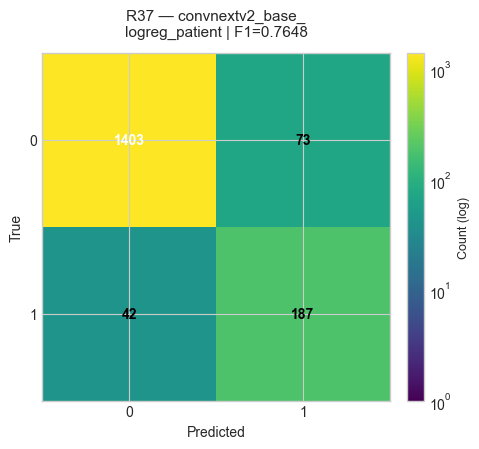

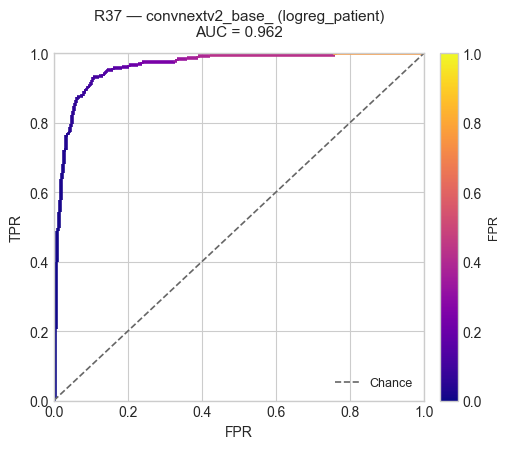


════════════════════════════════════════════════════════════════════════════════
[2/7] R37 — dinov3_convnext_base
  R28 hypers: arch=(128,) α=1.0000 lr=0.000358 bs=64 w=2.46
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (99.5% var)


KeyboardInterrupt: 

In [12]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 15 — R37 Per-Encoder Main Loop (trimmed features + fast bootstrap)
# ═══════════════════════════════════════════════════════════════════════

print('═' * 80)
print('R37 — Trimmed Features (7) + Fast Bootstrap')
print('═' * 80)

r37_results = []
t0_global = time.time()

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)

    # ── Checkpoint ────────────────────────────────────────────────
    chk_dir = R37_DIR / f'{emb_idx:02d}_{sname}'
    chk_hp  = chk_dir / 'hyperparameters.json'
    if chk_hp.exists():
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — CACHED')
        with open(chk_hp) as _f:
            prev = json.load(_f)
        r37_results.append({
            'embedding': sname, 'best_method': prev.get('best_method','?'),
            'val_f1': prev['val_referable_f1'], 'test_f1': prev['test_referable_f1'],
            'test_prec': prev['test_referable_precision'],
            'test_rec': prev['test_referable_recall'],
            'test_auc': prev['test_referable_auc'],
            'test_ba': prev['test_referable_bal_acc'],
            'd1_val_f1': prev.get('d1_flex_val_f1',0),
            'd2_val_f1': prev.get('d2_logreg_val_f1',0),
            'd3_val_f1': prev.get('d3_lgbm_val_f1',0),
            'time_s': 0,
        })
        continue

    if sname not in r28_hypers:
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — SKIPPED')
        continue

    hp = r28_hypers[sname]
    barch  = ast.literal_eval(hp['architecture']) if isinstance(hp['architecture'], str) else tuple(hp['architecture'])
    balpha = hp['alpha']
    blr    = hp['lr']
    bbs    = hp['batch_size']
    bw     = hp['pos_weight']

    print(f'\n{"═"*80}')
    print(f'[{emb_idx+1}/{len(embedding_files)}] R37 — {sname}')
    print(f'  R28 hypers: arch={barch} α={balpha:.4f} lr={blr:.6f} bs={bbs} w={bw:.2f}')
    print(f'{"═"*80}')
    t0 = time.time()

    # ══════════════════════════════════════════════════════════════
    # STAGE A: Feature prep (identical to R31/R35/R36)
    # ══════════════════════════════════════════════════════════════
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)

    b_train = df[df['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
    b_val   = df[df['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
    b_test  = df[df['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()

    X_tr_emb = b_train[ds.feature_cols].to_numpy(dtype=np.float32)
    X_va_emb = b_val[ds.feature_cols].to_numpy(dtype=np.float32)
    X_te_emb = b_test[ds.feature_cols].to_numpy(dtype=np.float32)

    yb_train = b_train[TASK].to_numpy(dtype=int)
    yb_val   = b_val[TASK].to_numpy(dtype=int)
    yb_test  = b_test[TASK].to_numpy(dtype=int)

    pids_tr = b_train['patient_id'].to_numpy()
    pids_va = b_val['patient_id'].to_numpy()
    pids_te = b_test['patient_id'].to_numpy()

    emb_dim_raw = X_tr_emb.shape[1]

    # ── PCA ───────────────────────────────────────────────────────
    nc = min(PCA_COMPONENTS, emb_dim_raw, X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca.fit_transform(X_tr_emb)
    X_va_pca = pca.transform(X_va_emb)
    X_te_pca = pca.transform(X_te_emb)
    var_exp = pca.explained_variance_ratio_.sum()
    print(f'  PCA: {emb_dim_raw}→{nc} ({var_exp:.1%} var)')

    # ── MI Selection ──────────────────────────────────────────────
    if MI_SELECTION:
        X_tr_sel, (X_va_sel, X_te_sel), mi_mask, _ = mi_select_features(
            X_tr_pca, yb_train, [X_va_pca, X_te_pca],
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS, random_state=RANDOM_SEED,
        )
        n_kept = mi_mask.sum()
        print(f'  MI: {nc}→{n_kept}')
    else:
        X_tr_sel, X_va_sel, X_te_sel = X_tr_pca, X_va_pca, X_te_pca
        n_kept = nc

    # ── Metadata + OD ─────────────────────────────────────────────
    X_tr_meta, ms = encode_metadata(b_train, METADATA_COLS)
    X_va_meta, _  = encode_metadata(b_val, METADATA_COLS, fit_stats=ms)
    X_te_meta, _  = encode_metadata(b_test, METADATA_COLS, fit_stats=ms)
    meta_dim = X_tr_meta.shape[1]

    rng_hp = np.random.default_rng(RANDOM_SEED)
    od_tr, miss_tr = _mask_od(b_train['optic_disc'], OD_P_MASK_BASE, rng_hp, OD_CORRUPT)
    X_tr_full = np.hstack([X_tr_sel, X_tr_meta, od_tr, miss_tr])
    ndim = X_tr_full.shape[1]
    print(f'  Dims: {n_kept} PCA + {meta_dim} meta + 2 OD = {ndim}')

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_full)
    X_tr_s = _apply_od_weights(X_tr_s, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    rng_v = np.random.default_rng(RANDOM_SEED + 7000)
    rng_t = np.random.default_rng(RANDOM_SEED + 9999)
    od_v, miss_v = _mask_od(b_val['optic_disc'],  OD_TEST_P_MASK, rng_v)
    od_t, miss_t = _mask_od(b_test['optic_disc'], OD_TEST_P_MASK, rng_t)

    X_va_s = scaler.transform(np.hstack([X_va_sel, X_va_meta, od_v, miss_v]))
    X_te_s = scaler.transform(np.hstack([X_te_sel, X_te_meta, od_t, miss_t]))
    X_va_s = _apply_od_weights(X_va_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
    X_te_s = _apply_od_weights(X_te_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # ══════════════════════════════════════════════════════════════
    # STAGE B: 25-Bag Ensemble (identical to R31/R35/R36)
    # ══════════════════════════════════════════════════════════════
    barchs = [barch, make_wider(barch), make_deeper(barch),
              make_narrower(barch), make_shallower(barch)]
    print(f'  [Stage B] {N_BAGS} models (R28 hypers, no search)')

    cal_p, cal_l = {}, {}
    bag_tr_proba, bag_va_proba, bag_te_proba = [], [], []

    for s_idx, seed in enumerate(BAG_SEEDS):
        upids = np.unique(pids_tr)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
        plm = b_train.groupby('patient_id')[TASK].max().to_dict()
        pl  = np.array([plm[p] for p in upids])
        ti, vi = next(sss.split(upids, pl))
        itr_pids = set(upids[ti])
        iva_pids = set(upids[vi])

        tr_m = np.isin(pids_tr, list(itr_pids))
        va_m = np.isin(pids_tr, list(iva_pids))

        rng_pm = np.random.default_rng(seed + 90000)
        pm_seed = float(rng_pm.uniform(OD_P_MASK_RANGE[0], OD_P_MASK_RANGE[1]))

        rng_it = np.random.default_rng(seed + 10000)
        od_it, miss_it = _mask_od(
            b_train.iloc[np.where(tr_m)[0]]['optic_disc'], pm_seed, rng_it, OD_CORRUPT)
        X_it = scaler.transform(np.hstack([X_tr_sel[tr_m], X_tr_meta[tr_m], od_it, miss_it]))
        X_it = _apply_od_weights(X_it, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_it = yb_train[tr_m]

        rng_iv = np.random.default_rng(seed + 20000)
        od_iv, miss_iv = _mask_od(
            b_train.iloc[np.where(va_m)[0]]['optic_disc'], pm_seed, rng_iv, OD_CORRUPT)
        X_iv = scaler.transform(np.hstack([X_tr_sel[va_m], X_tr_meta[va_m], od_iv, miss_iv]))
        X_iv = _apply_od_weights(X_iv, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_iv = yb_train[va_m]

        svp = []
        for a_idx, arch_v in enumerate(barchs):
            mlp = MLPClassifier(
                hidden_layer_sizes=arch_v, alpha=balpha,
                learning_rate='adaptive', learning_rate_init=blr,
                batch_size=bbs, max_iter=MLP_MAX_ITER,
                early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=MLP_PATIENCE, random_state=seed + a_idx,
            )
            sw = make_sample_weights(y_it, bw)
            mlp.fit(X_it, y_it, sample_weight=sw)

            svp.append(mlp.predict_proba(X_iv)[:, 1])
            bag_tr_proba.append(mlp.predict_proba(X_tr_s)[:, 1])
            bag_va_proba.append(mlp.predict_proba(X_va_s)[:, 1])
            bag_te_proba.append(mlp.predict_proba(X_te_s)[:, 1])

        cal_p[seed] = np.mean(svp, axis=0)
        cal_l[seed] = y_iv

    # ── Calibration ───────────────────────────────────────────────
    cp = np.concatenate([cal_p[s] for s in BAG_SEEDS])
    cl = np.concatenate([cal_l[s] for s in BAG_SEEDS])
    iso = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')
    iso.fit(cp, cl)

    avg_tr_raw = np.mean(bag_tr_proba, axis=0)
    avg_va_raw = np.mean(bag_va_proba, axis=0)
    avg_te_raw = np.mean(bag_te_proba, axis=0)
    avg_tr_cal = iso.predict(avg_tr_raw)
    avg_va_cal = iso.predict(avg_va_raw)
    avg_te_cal = iso.predict(avg_te_raw)

    print(f'  Stage B done: {N_BAGS} MLPs trained')
    print(f'  Per-image proba: val=[{avg_va_cal.min():.3f}, {avg_va_cal.max():.3f}]  '
          f'test=[{avg_te_cal.min():.3f}, {avg_te_cal.max():.3f}]')

    # ══════════════════════════════════════════════════════════════
    # STAGE C: Patient features — 7 trimmed (reuse R36 extraction)
    # ══════════════════════════════════════════════════════════════
    pos_mask_tr = yb_train == 1
    pos_centroid = X_tr_pca[pos_mask_tr].mean(axis=0)

    ref_train = build_referable_labels(b_train, TASK, BILATERAL_MIN_EYES)
    ref_val   = build_referable_labels(b_val, TASK, BILATERAL_MIN_EYES)
    ref_test  = build_referable_labels(b_test, TASK, BILATERAL_MIN_EYES)

    # Extract all 14 features, then select the 7 we want
    pf_train = extract_patient_features_r36(pids_tr, avg_tr_raw, avg_tr_cal,
                                             X_tr_pca, pos_centroid)
    pf_val   = extract_patient_features_r36(pids_va, avg_va_raw, avg_va_cal,
                                             X_va_pca, pos_centroid)
    pf_test  = extract_patient_features_r36(pids_te, avg_te_raw, avg_te_cal,
                                             X_te_pca, pos_centroid)

    com_tr = pf_train.index.intersection(ref_train.index)
    com_va = pf_val.index.intersection(ref_val.index)
    com_te = pf_test.index.intersection(ref_test.index)

    # ★ KEY CHANGE: use only 7 trimmed features
    X_pat_tr = pf_train.loc[com_tr][R37_FEATURE_COLS].values.astype(np.float32)
    y_pat_tr = ref_train.loc[com_tr].values.astype(int)
    X_pat_va = pf_val.loc[com_va][R37_FEATURE_COLS].values.astype(np.float32)
    y_pat_va = ref_val.loc[com_va].values.astype(int)
    X_pat_te = pf_test.loc[com_te][R37_FEATURE_COLS].values.astype(np.float32)
    y_pat_te = ref_test.loc[com_te].values.astype(int)

    print(f'  Stage C: {len(R37_FEATURE_COLS)} patient features (trimmed from 14)')
    print(f'    Train: {len(com_tr)} patients ({y_pat_tr.sum()} ref, {y_pat_tr.mean():.1%})')
    print(f'    Val:   {len(com_va)} patients ({y_pat_va.sum()} ref)')
    print(f'    Test:  {len(com_te)} patients ({y_pat_te.sum()} ref)')

    # ══════════════════════════════════════════════════════════════
    # STAGE D: Three methods + hybrid selection (fast bootstrap)
    # ══════════════════════════════════════════════════════════════
    methods = {}

    # ── D1: Flexible bilateral + fast bootstrap ───────────────────
    print(f'  [D1] Flexible bilateral + fast bootstrap ({BOOTSTRAP_N}×)')
    d1_best_f1, d1_best_t, d1_best_me, d1_best_pt = 0.0, 0.5, 2, 'raw'

    for pt_name, va_p, te_p in [
        ('cal', avg_va_cal, avg_te_cal),
        ('raw', avg_va_raw, avg_te_raw),
    ]:
        for me in FLEX_MIN_EYES:
            bt, bf1, _ = sweep_bilateral_threshold(
                pids_va, va_p, ref_val,
                min_eyes=me, grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR,
            )
            if bf1 > d1_best_f1:
                d1_best_f1, d1_best_t, d1_best_me, d1_best_pt = bf1, bt, me, pt_name

    # Fast vectorized bootstrap
    d1_va_p = avg_va_cal if d1_best_pt == 'cal' else avg_va_raw
    d1_boot_t = bootstrap_bilateral_fast(
        pids_va, d1_va_p, ref_val,
        min_eyes=d1_best_me, n_boot=BOOTSTRAP_N,
        grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR, rng_seed=BOOTSTRAP_SEED,
    )

    te_p_d1 = avg_te_cal if d1_best_pt == 'cal' else avg_te_raw
    d1_test_agg = bilateral_patient_predictions(pids_te, te_p_d1, d1_boot_t, d1_best_me)
    d1_com = d1_test_agg.index.intersection(ref_test.index)
    d1_yt = ref_test.loc[d1_com].values
    d1_yh = d1_test_agg.loc[d1_com, 'referable_pred'].values
    d1_yp = d1_test_agg.loc[d1_com, 'max_proba'].values
    d1_test_f1 = float(f1_score(d1_yt, d1_yh, zero_division=0))

    d1_va_agg = bilateral_patient_predictions(pids_va, d1_va_p, d1_boot_t, d1_best_me)
    d1_va_com = d1_va_agg.index.intersection(ref_val.index)
    d1_va_yt = ref_val.loc[d1_va_com].values
    d1_va_yh = d1_va_agg.loc[d1_va_com, 'referable_pred'].values
    d1_boot_val_f1 = float(f1_score(d1_va_yt, d1_va_yh, zero_division=0))

    methods['bilateral_flex'] = {
        'val_f1': d1_boot_val_f1, 'test_f1': d1_test_f1,
        'yt': d1_yt, 'yh': d1_yh, 'yp': d1_yp, 'com': d1_com,
        'detail': f'min_eyes={d1_best_me}, thr={d1_boot_t:.3f}(boot), proba={d1_best_pt}',
    }
    print(f'    D1: min_eyes={d1_best_me}, thr={d1_best_t:.3f}→{d1_boot_t:.3f}(boot), '
          f'proba={d1_best_pt} → val_F1={d1_boot_val_f1:.4f}, test_F1={d1_test_f1:.4f}')

    # ── D2: Patient LogReg (7 features + bootstrap threshold) ─────
    print(f'  [D2] Patient LogReg (7 feats, C={LR_C_VALUES})')
    lr_model, lr_C, lr_t, lr_val_f1, lr_scaler = train_patient_logreg_r36(
        X_pat_tr, y_pat_tr, X_pat_va, y_pat_va,
        C_values=LR_C_VALUES, threshold_grid=181,
        n_boot=BOOTSTRAP_N, rng_seed=BOOTSTRAP_SEED,
    )
    lr_te_proba = lr_model.predict_proba(lr_scaler.transform(X_pat_te))[:, 1]
    lr_te_pred  = (lr_te_proba >= lr_t).astype(int)
    lr_test_f1  = float(f1_score(y_pat_te, lr_te_pred, zero_division=0))

    methods['logreg_patient'] = {
        'val_f1': lr_val_f1, 'test_f1': lr_test_f1,
        'yt': y_pat_te, 'yh': lr_te_pred, 'yp': lr_te_proba, 'com': com_te,
        'detail': f'C={lr_C}, thr={lr_t:.3f}(boot)',
    }
    print(f'    D2: C={lr_C}, thr={lr_t:.3f}(boot) → val_F1={lr_val_f1:.4f}, test_F1={lr_test_f1:.4f}')

    # ── D3: Patient LightGBM (7 features + bootstrap threshold) ───
    print(f'  [D3] Patient LightGBM (7 feats)')
    lgb_model, lgb_t, lgb_val_f1 = train_patient_lgbm_r36(
        X_pat_tr, y_pat_tr, X_pat_va, y_pat_va,
        lgb_params=LGB_PARAMS, threshold_grid=181,
        n_boot=BOOTSTRAP_N, rng_seed=BOOTSTRAP_SEED,
    )
    lgb_te_proba = lgb_model.predict_proba(X_pat_te)[:, 1]
    lgb_te_pred  = (lgb_te_proba >= lgb_t).astype(int)
    lgb_test_f1  = float(f1_score(y_pat_te, lgb_te_pred, zero_division=0))

    methods['lgbm_patient'] = {
        'val_f1': lgb_val_f1, 'test_f1': lgb_test_f1,
        'yt': y_pat_te, 'yh': lgb_te_pred, 'yp': lgb_te_proba, 'com': com_te,
        'detail': f'thr={lgb_t:.3f}(boot)',
    }
    print(f'    D3: thr={lgb_t:.3f}(boot) → val_F1={lgb_val_f1:.4f}, test_F1={lgb_test_f1:.4f}')

    # ── Hybrid selection ──────────────────────────────────────────
    model_best_name = max(methods, key=lambda k: methods[k]['val_f1'])
    model_best_vf1  = methods[model_best_name]['val_f1']
    d1_vf1 = methods['bilateral_flex']['val_f1']

    if (model_best_vf1 - d1_vf1) < HYBRID_MARGIN and d1_vf1 > 0:
        best_name = 'bilateral_flex'
        print(f'  ★ HYBRID: D1 within {HYBRID_MARGIN} of {model_best_name} → prefer D1')
    else:
        best_name = model_best_name
    best = methods[best_name]
    print(f'  ★ BEST: {best_name} | val_F1={best["val_f1"]:.4f} | test_F1={best["test_f1"]:.4f}')
    print(f'    {best["detail"]}')

    # ══════════════════════════════════════════════════════════════
    # STAGE E: Save results
    # ══════════════════════════════════════════════════════════════
    yt, yh, yp = best['yt'], best['yh'], best['yp']
    test_f1   = float(f1_score(yt, yh, zero_division=0))
    test_prec = float(precision_score(yt, yh, zero_division=0))
    test_rec  = float(recall_score(yt, yh, zero_division=0))
    test_auc  = float(roc_auc_score(yt, yp)) if len(np.unique(yt)) > 1 else 0.0
    test_ba   = float(balanced_accuracy_score(yt, yh))
    elapsed = time.time() - t0

    print(f'\n  TEST: F1={test_f1:.4f}  Prec={test_prec:.4f}  Rec={test_rec:.4f}  '
          f'AUC={test_auc:.4f}  BalAcc={test_ba:.4f}')
    print(f'  Time: {elapsed:.0f}s')

    out_dir = R37_DIR / f'{emb_idx:02d}_{sname}'
    out_dir.mkdir(parents=True, exist_ok=True)

    cm = confusion_matrix(yt, yh)
    rep = classification_report(yt, yh, digits=3,
                                target_names=['Not Referable', 'Referable'])
    print(rep)

    pd.DataFrame(cm).to_csv(out_dir / 'confusion_matrix.csv', index=False)
    (out_dir / 'classification_report.txt').write_text(rep, encoding='utf-8')

    fpr, tpr, _ = roc_curve(yt, yp)
    pd.DataFrame({'fpr': fpr, 'tpr': tpr}).to_csv(out_dir / 'roc_curve.csv', index=False)

    pd.DataFrame({
        'patient_id': best['com'], 'y_true': yt, 'y_pred': yh, 'proba': yp,
    }).to_csv(out_dir / 'patient_predictions.csv', index=False)

    method_rows = []
    for mname, mdata in methods.items():
        method_rows.append({
            'method': mname, 'val_f1': mdata['val_f1'],
            'test_f1': mdata['test_f1'], 'detail': mdata['detail'],
            'is_best': mname == best_name,
        })
    pd.DataFrame(method_rows).to_csv(out_dir / 'method_comparison.csv', index=False)

    if hasattr(lgb_model, 'feature_importances_'):
        feat_imp = pd.DataFrame({
            'feature': R37_FEATURE_COLS,
            'importance': lgb_model.feature_importances_,
        }).sort_values('importance', ascending=False)
        feat_imp.to_csv(out_dir / 'lgbm_feature_importance.csv', index=False)
        print(f'  LGB features: {", ".join(feat_imp["feature"].tolist())}')

    hp_save = {
        'track': 'R37', 'embedding': sname,
        'best_method': best_name, 'method_detail': best['detail'],
        'r28_architecture': str(barch), 'r28_alpha': float(balpha),
        'r28_lr': float(blr), 'r28_batch_size': int(bbs),
        'r28_pos_weight': float(bw),
        'pca_dim': nc, 'mi_selected': int(n_kept), 'pca_var': float(var_exp),
        'n_patient_features': len(R37_FEATURE_COLS),
        'patient_features': R37_FEATURE_COLS,
        'bootstrap_n': BOOTSTRAP_N, 'hybrid_margin': HYBRID_MARGIN,
        'd1_flex_val_f1':   float(methods['bilateral_flex']['val_f1']),
        'd1_flex_test_f1':  float(methods['bilateral_flex']['test_f1']),
        'd1_min_eyes': d1_best_me, 'd1_threshold_boot': float(d1_boot_t),
        'd1_proba_type': d1_best_pt,
        'd2_logreg_val_f1': float(methods['logreg_patient']['val_f1']),
        'd2_logreg_test_f1':float(methods['logreg_patient']['test_f1']),
        'd2_C': float(lr_C), 'd2_threshold': float(lr_t),
        'd3_lgbm_val_f1':   float(methods['lgbm_patient']['val_f1']),
        'd3_lgbm_test_f1':  float(methods['lgbm_patient']['test_f1']),
        'd3_threshold': float(lgb_t),
        'val_referable_f1': float(best['val_f1']),
        'test_referable_f1': test_f1,
        'test_referable_precision': test_prec,
        'test_referable_recall': test_rec,
        'test_referable_auc': test_auc,
        'test_referable_bal_acc': test_ba,
        'n_test_patients': int(len(yt)),
    }
    with open(out_dir / 'hyperparameters.json', 'w') as f:
        json.dump(hp_save, f, indent=2)

    plot_confusion_matrix(cm,
        title=f'R37 — {sname}\n{best_name} | F1={test_f1:.4f}',
        save_path=out_dir / 'confusion_matrix.png', show=True)
    plot_roc_curve(fpr, tpr, test_auc,
        title=f'R37 — {sname} ({best_name})',
        save_path=out_dir / 'roc_curve.png', show=True)

    r37_results.append({
        'embedding': sname, 'best_method': best_name,
        'val_f1': float(best['val_f1']), 'test_f1': test_f1,
        'test_prec': test_prec, 'test_rec': test_rec,
        'test_auc': test_auc, 'test_ba': test_ba,
        'd1_val_f1': float(methods['bilateral_flex']['val_f1']),
        'd2_val_f1': float(methods['logreg_patient']['val_f1']),
        'd3_val_f1': float(methods['lgbm_patient']['val_f1']),
        'time_s': float(elapsed),
    })

total = time.time() - t0_global
print(f'\n{"═"*80}')
print(f'R37 complete! Total: {total:.0f}s ({total/60:.1f} min)')
print(f'{"═"*80}')

r37_df = pd.DataFrame(r37_results).sort_values('test_f1', ascending=False)
r37_df.to_csv(R37_DIR / 'r37_summary.csv', index=False)

print('\n── R37 Summary (sorted by Test F1) ──')
show_cols = ['embedding', 'best_method', 'val_f1', 'test_f1',
             'test_prec', 'test_rec', 'test_auc',
             'd1_val_f1', 'd2_val_f1', 'd3_val_f1']
print(r37_df[[c for c in show_cols if c in r37_df.columns]].to_string(index=False))

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Cell 16 — R37 vs R36 vs R31 Comparison
# ═══════════════════════════════════════════════════════════════════════

r31_known = {
    'dinov3_vitb16':              0.8009,
    'dinov3_convnext_base':       0.7640,
    'convnextv2_base_':           0.7445,
    'RETFound_dinov2_shanghai':   0.7435,
    'RETFound_mae_shanghai':      0.7286,
    'RETFound_mae_natureCFP':     0.7025,
    'vit_base_':                  0.6992,
}

r36_known = {
    'convnextv2_base_':           0.7748,
    'dinov3_convnext_base':       0.7851,
    'dinov3_vitb16':              0.8009,
    'RETFound_dinov2_shanghai':   0.7787,
}

comp_rows = []
for _, row in r37_df.iterrows():
    enc = row['embedding']
    r31v = r31_known.get(enc, np.nan)
    r36v = r36_known.get(enc, np.nan)
    comp_rows.append({
        'Encoder': enc,
        'R31_F1': r31v,
        'R36_F1': r36v,
        'R37_F1': row['test_f1'],
        'Δ_vs_R31': row['test_f1'] - r31v if not np.isnan(r31v) else np.nan,
        'R37_Method': row['best_method'],
        'R37_Prec': row['test_prec'],
        'R37_Rec': row['test_rec'],
        'R37_AUC': row['test_auc'],
    })

comp_df = pd.DataFrame(comp_rows).sort_values('R37_F1', ascending=False)
comp_df.to_csv(R37_DIR / 'r37_comparison.csv', index=False)

print('═' * 100)
print('R37 vs R31 — Comparison (trimmed 7 features)')
print('═' * 100)
print(comp_df.to_string(index=False, float_format='%.4f'))
print()

n_improved = (comp_df['Δ_vs_R31'] > 0.001).sum()
n_above_80 = (comp_df['R37_F1'] >= 0.80).sum()
best_enc = comp_df.iloc[0]
print(f'Improved over R31: {n_improved}/{len(comp_df)}')
print(f'Encoders ≥ 0.80:  {n_above_80}/{len(comp_df)}')
print(f'Best: {best_enc["Encoder"]} F1={best_enc["R37_F1"]:.4f} ({best_enc["R37_Method"]})')

# ── Bar chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5.5))
enc_labels = comp_df['Encoder'].values
x = np.arange(len(enc_labels))
w = 0.3
ax.bar(x - w/2, comp_df['R31_F1'].values, w, label='R31 (bilateral)', color='#4A90D9')
ax.bar(x + w/2, comp_df['R37_F1'].values, w, label='R37 (trimmed 7-feat)', color='#2ECC71')
ax.axhline(y=0.80, color='red', linestyle='--', alpha=0.5, label='0.80 target')
ax.set_xticks(x)
ax.set_xticklabels(enc_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Test F1 (Referable Glaucoma)')
ax.set_title('R37 vs R31 — Trimmed Patient Features (7)')
ax.legend(fontsize=9)
ax.set_ylim(0.65, 0.86)

for i, (r31v, r37v) in enumerate(
    zip(comp_df['R31_F1'], comp_df['R37_F1'])):
    delta = r37v - r31v
    color = 'green' if delta > 0.001 else ('red' if delta < -0.001 else 'gray')
    ax.text(i + w/2, r37v + 0.004, f'{delta:+.3f}', ha='center', va='bottom',
            fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
fig.savefig(R37_DIR / 'r37_vs_r31.png', dpi=160, bbox_inches='tight')
plt.show()

print('\nDone!')

# R38 — MLP-Only Pipeline (No LogReg / No LightGBM)

**Approach**: Pure MLP at both stages:
- **Stage 1**: 25-bag eye-level MLP ensemble (unchanged from R31/R35/R36/R37)
- **Stage 2**: Patient-level MLP on 7 trimmed features (replaces LogReg + LightGBM)
  - Small architectures: sweep (16,), (32,), (64,), (32,16), (64,32)
  - class_weight='balanced' via sample_weight, early stopping
  - Bootstrap threshold stabilization (200 resamples)
  - Hybrid selection: prefer D1 bilateral when within 0.01 of D2 MLP

**Changes from R37**: D2 and D3 replaced by single D2 MLP patient model

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# R38 Config + Patient MLP Helper
# ═══════════════════════════════════════════════════════════════════════

R38_DIR = RESULTS_DIR / 'r38_mlp_only'
R38_DIR.mkdir(parents=True, exist_ok=True)

R38_FEATURE_COLS = [
    'max_proba', 'second_max', 'mean_proba', 'std_proba',
    'cal_raw_gap', 'emb_dist_to_pos_centroid', 'n_eyes',
]

# Patient-level MLP architecture candidates (small — only 7 inputs)
PATIENT_MLP_ARCHS = [(16,), (32,), (64,), (32, 16), (64, 32)]
PATIENT_MLP_SEEDS = [42, 123, 456]  # 3 seeds per arch → 15 models, pick best


def train_patient_mlp_r38(X_tr, y_tr, X_va, y_va,
                           archs=None, seeds=None,
                           n_boot=200, rng_seed=42):
    """
    Train patient-level MLP. Sweep architectures × seeds,
    bootstrap-stabilize threshold, return best on val F1.

    Returns: (best_model, best_arch, best_threshold, best_val_f1, scaler)
    """
    if archs is None:
        archs = PATIENT_MLP_ARCHS
    if seeds is None:
        seeds = PATIENT_MLP_SEEDS

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    # Class-balanced sample weights
    pos_w = max(1.0, (y_tr == 0).sum() / max(1, (y_tr == 1).sum()))
    sw = make_sample_weights(y_tr, pos_w)

    best_vf1 = 0.0
    best_model, best_arch, best_t = None, None, 0.5

    for arch in archs:
        for seed in seeds:
            mlp = MLPClassifier(
                hidden_layer_sizes=arch,
                alpha=0.01,                   # moderate L2
                learning_rate='adaptive',
                learning_rate_init=0.001,
                batch_size=min(64, len(X_tr_s)),
                max_iter=500,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=20,
                random_state=seed,
            )
            mlp.fit(X_tr_s, y_tr, sample_weight=sw)
            val_proba = mlp.predict_proba(X_va_s)[:, 1]

            # Bootstrap-stabilized threshold
            bt = bootstrap_threshold(y_va, val_proba,
                                     n_boot=n_boot,
                                     grid_size=181,
                                     rng_seed=rng_seed)
            preds = (val_proba >= bt).astype(int)
            f1 = f1_score(y_va, preds, zero_division=0)

            if f1 > best_vf1:
                best_vf1 = f1
                best_model = mlp
                best_arch = arch
                best_t = bt

    return best_model, best_arch, best_t, best_vf1, scaler


print(f'R38 config OK — MLP-only pipeline')
print(f'  Patient features: {len(R38_FEATURE_COLS)} (trimmed)')
print(f'  Patient MLP archs: {PATIENT_MLP_ARCHS}')
print(f'  Seeds per arch: {len(PATIENT_MLP_SEEDS)} → {len(PATIENT_MLP_ARCHS)*len(PATIENT_MLP_SEEDS)} candidates')
print(f'  Bootstrap: {BOOTSTRAP_N} resamples')
print(f'  Results dir: {R38_DIR}')

R38 config OK — MLP-only pipeline
  Patient features: 7 (trimmed)
  Patient MLP archs: [(16,), (32,), (64,), (32, 16), (64, 32)]
  Seeds per arch: 3 → 15 candidates
  Bootstrap: 200 resamples
  Results dir: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r35_patient_model_cascade\r38_mlp_only


════════════════════════════════════════════════════════════════════════════════
R38 — MLP-Only Pipeline (No LogReg / No LightGBM)
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
[1/7] R38 — convnextv2_base_
  R28 hypers: arch=(128,) α=1.0000 lr=0.000100 bs=64 w=4.07
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.8% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Stage B] 25 eye-level MLPs (R28 hypers)
  Stage B: 25 eye-level MLPs trained
  Per-image proba: val=[0.001, 0.999]  test=[0.001, 0.999]
  Stage C: 7 patient features
    Train: 5796 patients (789 ref, 13.6%)
    Val:   1023 patients (157 ref)
    Test:  1705 patients (229 ref)
  [D1] Bilateral flex + fast bootstrap (200×)
    D1: min_eyes=2, thr=0.432→0.439(boot), proba=raw → val_F1=0.7802, test_F1=0.7495
  [D2] Patient MLP (5 archs × 3 seeds)
    D

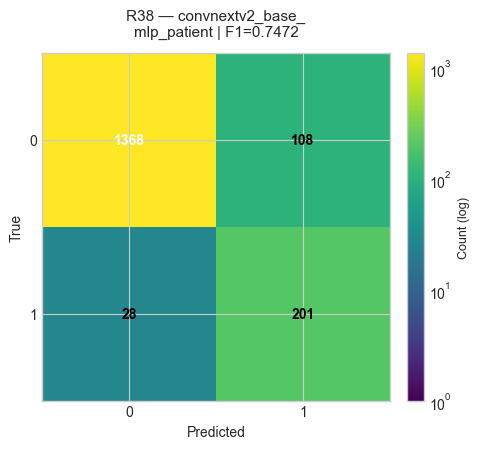

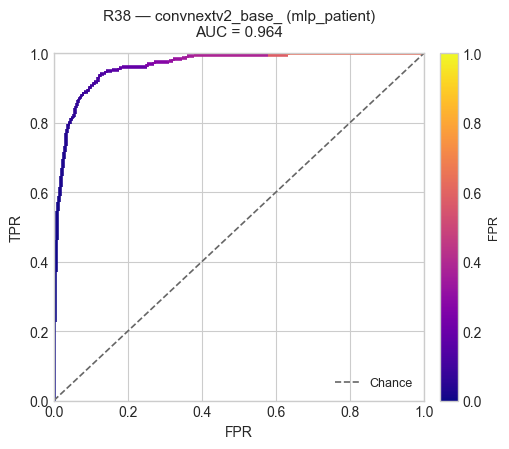


════════════════════════════════════════════════════════════════════════════════
[2/7] R38 — dinov3_convnext_base
  R28 hypers: arch=(128,) α=1.0000 lr=0.000358 bs=64 w=2.46
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (99.5% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Stage B] 25 eye-level MLPs (R28 hypers)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# R38 Per-Encoder Main Loop — MLP-Only (D1 bilateral + D2 patient MLP)
# ═══════════════════════════════════════════════════════════════════════

print('═' * 80)
print('R38 — MLP-Only Pipeline (No LogReg / No LightGBM)')
print('═' * 80)

r38_results = []
t0_global = time.time()

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)

    # ── Checkpoint ────────────────────────────────────────────────
    chk_dir = R38_DIR / f'{emb_idx:02d}_{sname}'
    chk_hp  = chk_dir / 'hyperparameters.json'
    if chk_hp.exists():
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — CACHED')
        with open(chk_hp) as _f:
            prev = json.load(_f)
        r38_results.append({
            'embedding': sname, 'best_method': prev.get('best_method','?'),
            'val_f1': prev['val_referable_f1'], 'test_f1': prev['test_referable_f1'],
            'test_prec': prev['test_referable_precision'],
            'test_rec': prev['test_referable_recall'],
            'test_auc': prev['test_referable_auc'],
            'test_ba': prev['test_referable_bal_acc'],
            'd1_val_f1': prev.get('d1_flex_val_f1', 0),
            'd2_val_f1': prev.get('d2_mlp_val_f1', 0),
            'time_s': 0,
        })
        continue

    if sname not in r28_hypers:
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — SKIPPED')
        continue

    hp = r28_hypers[sname]
    barch  = ast.literal_eval(hp['architecture']) if isinstance(hp['architecture'], str) else tuple(hp['architecture'])
    balpha = hp['alpha']
    blr    = hp['lr']
    bbs    = hp['batch_size']
    bw     = hp['pos_weight']

    print(f'\n{"═"*80}')
    print(f'[{emb_idx+1}/{len(embedding_files)}] R38 — {sname}')
    print(f'  R28 hypers: arch={barch} α={balpha:.4f} lr={blr:.6f} bs={bbs} w={bw:.2f}')
    print(f'{"═"*80}')
    t0 = time.time()

    # ══════════════════════════════════════════════════════════════
    # STAGE A: Feature prep (identical to R31/R35/R36/R37)
    # ══════════════════════════════════════════════════════════════
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)

    b_train = df[df['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
    b_val   = df[df['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
    b_test  = df[df['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()

    X_tr_emb = b_train[ds.feature_cols].to_numpy(dtype=np.float32)
    X_va_emb = b_val[ds.feature_cols].to_numpy(dtype=np.float32)
    X_te_emb = b_test[ds.feature_cols].to_numpy(dtype=np.float32)

    yb_train = b_train[TASK].to_numpy(dtype=int)
    yb_val   = b_val[TASK].to_numpy(dtype=int)
    yb_test  = b_test[TASK].to_numpy(dtype=int)

    pids_tr = b_train['patient_id'].to_numpy()
    pids_va = b_val['patient_id'].to_numpy()
    pids_te = b_test['patient_id'].to_numpy()

    emb_dim_raw = X_tr_emb.shape[1]

    # ── PCA ───────────────────────────────────────────────────────
    nc = min(PCA_COMPONENTS, emb_dim_raw, X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca.fit_transform(X_tr_emb)
    X_va_pca = pca.transform(X_va_emb)
    X_te_pca = pca.transform(X_te_emb)
    var_exp = pca.explained_variance_ratio_.sum()
    print(f'  PCA: {emb_dim_raw}→{nc} ({var_exp:.1%} var)')

    # ── MI Selection ──────────────────────────────────────────────
    if MI_SELECTION:
        X_tr_sel, (X_va_sel, X_te_sel), mi_mask, _ = mi_select_features(
            X_tr_pca, yb_train, [X_va_pca, X_te_pca],
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS, random_state=RANDOM_SEED,
        )
        n_kept = mi_mask.sum()
        print(f'  MI: {nc}→{n_kept}')
    else:
        X_tr_sel, X_va_sel, X_te_sel = X_tr_pca, X_va_pca, X_te_pca
        n_kept = nc

    # ── Metadata + OD ─────────────────────────────────────────────
    X_tr_meta, ms = encode_metadata(b_train, METADATA_COLS)
    X_va_meta, _  = encode_metadata(b_val, METADATA_COLS, fit_stats=ms)
    X_te_meta, _  = encode_metadata(b_test, METADATA_COLS, fit_stats=ms)
    meta_dim = X_tr_meta.shape[1]

    rng_hp = np.random.default_rng(RANDOM_SEED)
    od_tr, miss_tr = _mask_od(b_train['optic_disc'], OD_P_MASK_BASE, rng_hp, OD_CORRUPT)
    X_tr_full = np.hstack([X_tr_sel, X_tr_meta, od_tr, miss_tr])
    ndim = X_tr_full.shape[1]
    print(f'  Dims: {n_kept} PCA + {meta_dim} meta + 2 OD = {ndim}')

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_full)
    X_tr_s = _apply_od_weights(X_tr_s, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    rng_v = np.random.default_rng(RANDOM_SEED + 7000)
    rng_t = np.random.default_rng(RANDOM_SEED + 9999)
    od_v, miss_v = _mask_od(b_val['optic_disc'],  OD_TEST_P_MASK, rng_v)
    od_t, miss_t = _mask_od(b_test['optic_disc'], OD_TEST_P_MASK, rng_t)

    X_va_s = scaler.transform(np.hstack([X_va_sel, X_va_meta, od_v, miss_v]))
    X_te_s = scaler.transform(np.hstack([X_te_sel, X_te_meta, od_t, miss_t]))
    X_va_s = _apply_od_weights(X_va_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
    X_te_s = _apply_od_weights(X_te_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # ══════════════════════════════════════════════════════════════
    # STAGE B: 25-Bag Eye-Level MLP Ensemble (identical)
    # ══════════════════════════════════════════════════════════════
    barchs = [barch, make_wider(barch), make_deeper(barch),
              make_narrower(barch), make_shallower(barch)]
    print(f'  [Stage B] {N_BAGS} eye-level MLPs (R28 hypers)')

    cal_p, cal_l = {}, {}
    bag_tr_proba, bag_va_proba, bag_te_proba = [], [], []

    for s_idx, seed in enumerate(BAG_SEEDS):
        upids = np.unique(pids_tr)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
        plm = b_train.groupby('patient_id')[TASK].max().to_dict()
        pl  = np.array([plm[p] for p in upids])
        ti, vi = next(sss.split(upids, pl))
        itr_pids = set(upids[ti])
        iva_pids = set(upids[vi])

        tr_m = np.isin(pids_tr, list(itr_pids))
        va_m = np.isin(pids_tr, list(iva_pids))

        rng_pm = np.random.default_rng(seed + 90000)
        pm_seed = float(rng_pm.uniform(OD_P_MASK_RANGE[0], OD_P_MASK_RANGE[1]))

        rng_it = np.random.default_rng(seed + 10000)
        od_it, miss_it = _mask_od(
            b_train.iloc[np.where(tr_m)[0]]['optic_disc'], pm_seed, rng_it, OD_CORRUPT)
        X_it = scaler.transform(np.hstack([X_tr_sel[tr_m], X_tr_meta[tr_m], od_it, miss_it]))
        X_it = _apply_od_weights(X_it, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_it = yb_train[tr_m]

        rng_iv = np.random.default_rng(seed + 20000)
        od_iv, miss_iv = _mask_od(
            b_train.iloc[np.where(va_m)[0]]['optic_disc'], pm_seed, rng_iv, OD_CORRUPT)
        X_iv = scaler.transform(np.hstack([X_tr_sel[va_m], X_tr_meta[va_m], od_iv, miss_iv]))
        X_iv = _apply_od_weights(X_iv, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_iv = yb_train[va_m]

        svp = []
        for a_idx, arch_v in enumerate(barchs):
            mlp = MLPClassifier(
                hidden_layer_sizes=arch_v, alpha=balpha,
                learning_rate='adaptive', learning_rate_init=blr,
                batch_size=bbs, max_iter=MLP_MAX_ITER,
                early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=MLP_PATIENCE, random_state=seed + a_idx,
            )
            sw = make_sample_weights(y_it, bw)
            mlp.fit(X_it, y_it, sample_weight=sw)

            svp.append(mlp.predict_proba(X_iv)[:, 1])
            bag_tr_proba.append(mlp.predict_proba(X_tr_s)[:, 1])
            bag_va_proba.append(mlp.predict_proba(X_va_s)[:, 1])
            bag_te_proba.append(mlp.predict_proba(X_te_s)[:, 1])

        cal_p[seed] = np.mean(svp, axis=0)
        cal_l[seed] = y_iv

    # ── Calibration ───────────────────────────────────────────────
    cp = np.concatenate([cal_p[s] for s in BAG_SEEDS])
    cl = np.concatenate([cal_l[s] for s in BAG_SEEDS])
    iso = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')
    iso.fit(cp, cl)

    avg_tr_raw = np.mean(bag_tr_proba, axis=0)
    avg_va_raw = np.mean(bag_va_proba, axis=0)
    avg_te_raw = np.mean(bag_te_proba, axis=0)
    avg_tr_cal = iso.predict(avg_tr_raw)
    avg_va_cal = iso.predict(avg_va_raw)
    avg_te_cal = iso.predict(avg_te_raw)

    print(f'  Stage B: {N_BAGS} eye-level MLPs trained')
    print(f'  Per-image proba: val=[{avg_va_cal.min():.3f}, {avg_va_cal.max():.3f}]  '
          f'test=[{avg_te_cal.min():.3f}, {avg_te_cal.max():.3f}]')

    # ══════════════════════════════════════════════════════════════
    # STAGE C: Patient features (7 trimmed)
    # ══════════════════════════════════════════════════════════════
    pos_mask_tr = yb_train == 1
    pos_centroid = X_tr_pca[pos_mask_tr].mean(axis=0)

    ref_train = build_referable_labels(b_train, TASK, BILATERAL_MIN_EYES)
    ref_val   = build_referable_labels(b_val, TASK, BILATERAL_MIN_EYES)
    ref_test  = build_referable_labels(b_test, TASK, BILATERAL_MIN_EYES)

    pf_train = extract_patient_features_r36(pids_tr, avg_tr_raw, avg_tr_cal,
                                             X_tr_pca, pos_centroid)
    pf_val   = extract_patient_features_r36(pids_va, avg_va_raw, avg_va_cal,
                                             X_va_pca, pos_centroid)
    pf_test  = extract_patient_features_r36(pids_te, avg_te_raw, avg_te_cal,
                                             X_te_pca, pos_centroid)

    com_tr = pf_train.index.intersection(ref_train.index)
    com_va = pf_val.index.intersection(ref_val.index)
    com_te = pf_test.index.intersection(ref_test.index)

    X_pat_tr = pf_train.loc[com_tr][R38_FEATURE_COLS].values.astype(np.float32)
    y_pat_tr = ref_train.loc[com_tr].values.astype(int)
    X_pat_va = pf_val.loc[com_va][R38_FEATURE_COLS].values.astype(np.float32)
    y_pat_va = ref_val.loc[com_va].values.astype(int)
    X_pat_te = pf_test.loc[com_te][R38_FEATURE_COLS].values.astype(np.float32)
    y_pat_te = ref_test.loc[com_te].values.astype(int)

    print(f'  Stage C: {len(R38_FEATURE_COLS)} patient features')
    print(f'    Train: {len(com_tr)} patients ({y_pat_tr.sum()} ref, {y_pat_tr.mean():.1%})')
    print(f'    Val:   {len(com_va)} patients ({y_pat_va.sum()} ref)')
    print(f'    Test:  {len(com_te)} patients ({y_pat_te.sum()} ref)')

    # ══════════════════════════════════════════════════════════════
    # STAGE D: D1 bilateral + D2 patient MLP (NO LogReg, NO LightGBM)
    # ══════════════════════════════════════════════════════════════
    methods = {}

    # ── D1: Flexible bilateral + fast bootstrap ───────────────────
    print(f'  [D1] Bilateral flex + fast bootstrap ({BOOTSTRAP_N}×)')
    d1_best_f1, d1_best_t, d1_best_me, d1_best_pt = 0.0, 0.5, 2, 'raw'

    for pt_name, va_p, te_p in [
        ('cal', avg_va_cal, avg_te_cal),
        ('raw', avg_va_raw, avg_te_raw),
    ]:
        for me in FLEX_MIN_EYES:
            bt, bf1, _ = sweep_bilateral_threshold(
                pids_va, va_p, ref_val,
                min_eyes=me, grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR,
            )
            if bf1 > d1_best_f1:
                d1_best_f1, d1_best_t, d1_best_me, d1_best_pt = bf1, bt, me, pt_name

    d1_va_p = avg_va_cal if d1_best_pt == 'cal' else avg_va_raw
    d1_boot_t = bootstrap_bilateral_fast(
        pids_va, d1_va_p, ref_val,
        min_eyes=d1_best_me, n_boot=BOOTSTRAP_N,
        grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR, rng_seed=BOOTSTRAP_SEED,
    )

    te_p_d1 = avg_te_cal if d1_best_pt == 'cal' else avg_te_raw
    d1_test_agg = bilateral_patient_predictions(pids_te, te_p_d1, d1_boot_t, d1_best_me)
    d1_com = d1_test_agg.index.intersection(ref_test.index)
    d1_yt = ref_test.loc[d1_com].values
    d1_yh = d1_test_agg.loc[d1_com, 'referable_pred'].values
    d1_yp = d1_test_agg.loc[d1_com, 'max_proba'].values
    d1_test_f1 = float(f1_score(d1_yt, d1_yh, zero_division=0))

    d1_va_agg = bilateral_patient_predictions(pids_va, d1_va_p, d1_boot_t, d1_best_me)
    d1_va_com = d1_va_agg.index.intersection(ref_val.index)
    d1_va_yt = ref_val.loc[d1_va_com].values
    d1_va_yh = d1_va_agg.loc[d1_va_com, 'referable_pred'].values
    d1_boot_val_f1 = float(f1_score(d1_va_yt, d1_va_yh, zero_division=0))

    methods['bilateral_flex'] = {
        'val_f1': d1_boot_val_f1, 'test_f1': d1_test_f1,
        'yt': d1_yt, 'yh': d1_yh, 'yp': d1_yp, 'com': d1_com,
        'detail': f'min_eyes={d1_best_me}, thr={d1_boot_t:.3f}(boot), proba={d1_best_pt}',
    }
    print(f'    D1: min_eyes={d1_best_me}, thr={d1_best_t:.3f}→{d1_boot_t:.3f}(boot), '
          f'proba={d1_best_pt} → val_F1={d1_boot_val_f1:.4f}, test_F1={d1_test_f1:.4f}')

    # ── D2: Patient-level MLP (5 archs × 3 seeds = 15 candidates) ─
    print(f'  [D2] Patient MLP ({len(PATIENT_MLP_ARCHS)} archs × {len(PATIENT_MLP_SEEDS)} seeds)')
    mlp_model, mlp_arch, mlp_t, mlp_val_f1, mlp_scaler = train_patient_mlp_r38(
        X_pat_tr, y_pat_tr, X_pat_va, y_pat_va,
        archs=PATIENT_MLP_ARCHS, seeds=PATIENT_MLP_SEEDS,
        n_boot=BOOTSTRAP_N, rng_seed=BOOTSTRAP_SEED,
    )
    mlp_te_proba = mlp_model.predict_proba(mlp_scaler.transform(X_pat_te))[:, 1]
    mlp_te_pred  = (mlp_te_proba >= mlp_t).astype(int)
    mlp_test_f1  = float(f1_score(y_pat_te, mlp_te_pred, zero_division=0))

    methods['mlp_patient'] = {
        'val_f1': mlp_val_f1, 'test_f1': mlp_test_f1,
        'yt': y_pat_te, 'yh': mlp_te_pred, 'yp': mlp_te_proba, 'com': com_te,
        'detail': f'arch={mlp_arch}, thr={mlp_t:.3f}(boot)',
    }
    print(f'    D2: arch={mlp_arch}, thr={mlp_t:.3f}(boot) → '
          f'val_F1={mlp_val_f1:.4f}, test_F1={mlp_test_f1:.4f}')

    # ── Hybrid selection ──────────────────────────────────────────
    d2_vf1 = methods['mlp_patient']['val_f1']
    d1_vf1 = methods['bilateral_flex']['val_f1']

    if (d2_vf1 - d1_vf1) < HYBRID_MARGIN and d1_vf1 > 0:
        best_name = 'bilateral_flex'
        print(f'  ★ HYBRID: D1 within {HYBRID_MARGIN} of mlp_patient → prefer D1')
    else:
        best_name = max(methods, key=lambda k: methods[k]['val_f1'])
    best = methods[best_name]
    print(f'  ★ BEST: {best_name} | val_F1={best["val_f1"]:.4f} | test_F1={best["test_f1"]:.4f}')
    print(f'    {best["detail"]}')

    # ══════════════════════════════════════════════════════════════
    # STAGE E: Save results
    # ══════════════════════════════════════════════════════════════
    yt, yh, yp = best['yt'], best['yh'], best['yp']
    test_f1   = float(f1_score(yt, yh, zero_division=0))
    test_prec = float(precision_score(yt, yh, zero_division=0))
    test_rec  = float(recall_score(yt, yh, zero_division=0))
    test_auc  = float(roc_auc_score(yt, yp)) if len(np.unique(yt)) > 1 else 0.0
    test_ba   = float(balanced_accuracy_score(yt, yh))
    elapsed = time.time() - t0

    print(f'\n  TEST: F1={test_f1:.4f}  Prec={test_prec:.4f}  Rec={test_rec:.4f}  '
          f'AUC={test_auc:.4f}  BalAcc={test_ba:.4f}')
    print(f'  Time: {elapsed:.0f}s')

    out_dir = R38_DIR / f'{emb_idx:02d}_{sname}'
    out_dir.mkdir(parents=True, exist_ok=True)

    cm = confusion_matrix(yt, yh)
    rep = classification_report(yt, yh, digits=3,
                                target_names=['Not Referable', 'Referable'])
    print(rep)

    pd.DataFrame(cm).to_csv(out_dir / 'confusion_matrix.csv', index=False)
    (out_dir / 'classification_report.txt').write_text(rep, encoding='utf-8')

    fpr, tpr, _ = roc_curve(yt, yp)
    pd.DataFrame({'fpr': fpr, 'tpr': tpr}).to_csv(out_dir / 'roc_curve.csv', index=False)

    pd.DataFrame({
        'patient_id': best['com'], 'y_true': yt, 'y_pred': yh, 'proba': yp,
    }).to_csv(out_dir / 'patient_predictions.csv', index=False)

    method_rows = []
    for mname, mdata in methods.items():
        method_rows.append({
            'method': mname, 'val_f1': mdata['val_f1'],
            'test_f1': mdata['test_f1'], 'detail': mdata['detail'],
            'is_best': mname == best_name,
        })
    pd.DataFrame(method_rows).to_csv(out_dir / 'method_comparison.csv', index=False)

    hp_save = {
        'track': 'R38', 'embedding': sname,
        'pipeline': 'MLP-only (eye MLP ensemble + patient MLP)',
        'best_method': best_name, 'method_detail': best['detail'],
        'r28_architecture': str(barch), 'r28_alpha': float(balpha),
        'r28_lr': float(blr), 'r28_batch_size': int(bbs),
        'r28_pos_weight': float(bw),
        'pca_dim': nc, 'mi_selected': int(n_kept), 'pca_var': float(var_exp),
        'n_patient_features': len(R38_FEATURE_COLS),
        'patient_features': R38_FEATURE_COLS,
        'bootstrap_n': BOOTSTRAP_N, 'hybrid_margin': HYBRID_MARGIN,
        'd1_flex_val_f1':   float(methods['bilateral_flex']['val_f1']),
        'd1_flex_test_f1':  float(methods['bilateral_flex']['test_f1']),
        'd1_min_eyes': d1_best_me, 'd1_threshold_boot': float(d1_boot_t),
        'd1_proba_type': d1_best_pt,
        'd2_mlp_val_f1':    float(methods['mlp_patient']['val_f1']),
        'd2_mlp_test_f1':   float(methods['mlp_patient']['test_f1']),
        'd2_mlp_arch': str(mlp_arch), 'd2_mlp_threshold': float(mlp_t),
        'val_referable_f1': float(best['val_f1']),
        'test_referable_f1': test_f1,
        'test_referable_precision': test_prec,
        'test_referable_recall': test_rec,
        'test_referable_auc': test_auc,
        'test_referable_bal_acc': test_ba,
        'n_test_patients': int(len(yt)),
    }
    with open(out_dir / 'hyperparameters.json', 'w') as f:
        json.dump(hp_save, f, indent=2)

    plot_confusion_matrix(cm,
        title=f'R38 — {sname}\n{best_name} | F1={test_f1:.4f}',
        save_path=out_dir / 'confusion_matrix.png', show=True)
    plot_roc_curve(fpr, tpr, test_auc,
        title=f'R38 — {sname} ({best_name})',
        save_path=out_dir / 'roc_curve.png', show=True)

    r38_results.append({
        'embedding': sname, 'best_method': best_name,
        'val_f1': float(best['val_f1']), 'test_f1': test_f1,
        'test_prec': test_prec, 'test_rec': test_rec,
        'test_auc': test_auc, 'test_ba': test_ba,
        'd1_val_f1': float(methods['bilateral_flex']['val_f1']),
        'd2_val_f1': float(methods['mlp_patient']['val_f1']),
        'time_s': float(elapsed),
    })

total = time.time() - t0_global
print(f'\n{"═"*80}')
print(f'R38 complete! Total: {total:.0f}s ({total/60:.1f} min)')
print(f'{"═"*80}')

r38_df = pd.DataFrame(r38_results).sort_values('test_f1', ascending=False)
r38_df.to_csv(R38_DIR / 'r38_summary.csv', index=False)

print('\n── R38 Summary (sorted by Test F1) ──')
show_cols = ['embedding', 'best_method', 'val_f1', 'test_f1',
             'test_prec', 'test_rec', 'test_auc',
             'd1_val_f1', 'd2_val_f1']
print(r38_df[[c for c in show_cols if c in r38_df.columns]].to_string(index=False))

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# R38 vs R37 vs R31 Comparison
# ═══════════════════════════════════════════════════════════════════════
r31_known = {
    'convnextv2_base_':             0.7445,
    'dinov3_convnext_base':         0.7640,
    'dinov3_vitb16':                0.8009,
    'RETFound_dinov2_shanghai':     0.7435,
    'RETFound_mae_natureCFP':       0.7025,
    'RETFound_mae_shanghai':        0.7286,
    'vit_base_':                    0.6992,
}

# Try to load R37 from its saved summary
r37_map = {}
r37_csv = Path('results/brset_patient_eval_glaucoma/checkpoint_run16b/r37_summary.csv')
if r37_csv.exists():
    _r37 = pd.read_csv(r37_csv)
    r37_map = dict(zip(_r37['embedding'], _r37['test_f1']))
else:
    # fallback: try loading individual checkpoints
    r37_dir = Path('results/brset_patient_eval_glaucoma/checkpoint_run16b')
    if r37_dir.exists():
        for sub in sorted(r37_dir.iterdir()):
            hp_f = sub / 'hyperparameters.json'
            if hp_f.exists():
                with open(hp_f) as f:
                    h = json.load(f)
                if h.get('track') == 'R37':
                    r37_map[h['embedding']] = h['test_referable_f1']

print('═' * 80)
print('R38 vs R37 vs R31 — Referable Glaucoma Test F1')
print('═' * 80)

rows = []
for _, row in r38_df.iterrows():
    enc = row['embedding']
    r38_f1 = row['test_f1']
    r31_f1 = r31_known.get(enc, None)
    r37_f1 = r37_map.get(enc, None)

    delta_31 = (r38_f1 - r31_f1) if r31_f1 is not None else None
    delta_37 = (r38_f1 - r37_f1) if r37_f1 is not None else None

    rows.append({
        'embedding': enc,
        'R31_F1': f'{r31_f1:.4f}' if r31_f1 else '—',
        'R37_F1': f'{r37_f1:.4f}' if r37_f1 else '—',
        'R38_F1': f'{r38_f1:.4f}',
        'R38_method': row['best_method'],
        'Δ_vs_R31': f'{delta_31:+.4f}' if delta_31 is not None else '—',
        'Δ_vs_R37': f'{delta_37:+.4f}' if delta_37 is not None else '—',
    })

cdf = pd.DataFrame(rows)
print(cdf.to_string(index=False))

n_above_80 = sum(1 for _, r in r38_df.iterrows() if r['test_f1'] >= 0.80)
n_improved = sum(1 for row in rows
                 if row['Δ_vs_R31'] != '—' and float(row['Δ_vs_R31']) > 0)

print(f'\n≥0.80 F1: {n_above_80} / {len(r38_df)} encoders')
print(f'Improved vs R31: {n_improved} / {len(r38_df)} encoders')
print(f'Goal: ≥3 encoders at ≥0.80 F1')

## R39 — Augmentation-Only (MLP-only, NO HP retune)

**HP re-tuning removed** — it overfit on noisy val (157 positive patients).  
Uses R28 proven hyperparameters + eye-level augmentation (noise, feature dropout, OD mask widening).

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# R39 Config — Augmentation-Only + MLP-only (NO HP retune)
# ═══════════════════════════════════════════════════════════════════════

R39_DIR = RESULTS_DIR / 'r39_retune_augment'
R39_DIR.mkdir(parents=True, exist_ok=True)

# ─── Eye-level augmentation ──────────────────────────────────────
R39_NOISE_STD     = 0.05    # Gaussian noise σ on standardized PCA features
R39_FEAT_DROP     = 0.05    # fraction of PCA columns zeroed per bag
R39_OD_MASK_RANGE = (0.20, 0.85)  # widened from (0.35, 0.70)
R39_OD_CORRUPT    = 0.15          # increased from 0.10

# ─── Patient features + MLP (same setup as R38) ──────────────────
R39_FEATURE_COLS = [
    'max_proba', 'second_max', 'mean_proba', 'std_proba',
    'cal_raw_gap', 'emb_dist_to_pos_centroid', 'n_eyes',
]
R39_PAT_ARCHS = [(16,), (32,), (64,), (32, 16), (64, 32)]
R39_PAT_SEEDS = [42, 123, 456]


def train_pat_mlp_r39(X_tr, y_tr, X_va, y_va,
                       archs=None, seeds=None,
                       n_boot=200, rng_seed=42):
    """Patient MLP: sweep archs × seeds, bootstrap threshold, return best."""
    if archs is None: archs = R39_PAT_ARCHS
    if seeds is None: seeds = R39_PAT_SEEDS

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_va_s = sc.transform(X_va)

    pos_w = max(1.0, (y_tr == 0).sum() / max(1, (y_tr == 1).sum()))
    sw = make_sample_weights(y_tr, pos_w)

    best_vf1 = 0.0
    best_model, best_arch, best_t = None, None, 0.5

    for arch in archs:
        for seed in seeds:
            mlp = MLPClassifier(
                hidden_layer_sizes=arch, alpha=0.01,
                learning_rate='adaptive', learning_rate_init=0.001,
                batch_size=min(64, len(X_tr_s)),
                max_iter=500, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=20,
                random_state=seed,
            )
            mlp.fit(X_tr_s, y_tr, sample_weight=sw)
            val_proba = mlp.predict_proba(X_va_s)[:, 1]

            bt = bootstrap_threshold(y_va, val_proba,
                                     n_boot=n_boot, grid_size=181,
                                     rng_seed=rng_seed)
            preds = (val_proba >= bt).astype(int)
            f1 = f1_score(y_va, preds, zero_division=0)

            if f1 > best_vf1:
                best_vf1, best_model, best_arch, best_t = f1, mlp, arch, bt

    return best_model, best_arch, best_t, best_vf1, sc


print(f'R39 config OK — Augmentation-Only + MLP-only (NO HP retune)')
print(f'  Augmentation: noise_std={R39_NOISE_STD}, feat_drop={R39_FEAT_DROP}, '
      f'OD_range={R39_OD_MASK_RANGE}, OD_corrupt={R39_OD_CORRUPT}')
print(f'  Patient features: {len(R39_FEATURE_COLS)} (MLP-only)')
print(f'  Results dir: {R39_DIR}')

R39 config OK — Augmentation-Only + MLP-only (NO HP retune)
  Augmentation: noise_std=0.05, feat_drop=0.05, OD_range=(0.2, 0.85), OD_corrupt=0.15
  Patient features: 7 (MLP-only)
  Results dir: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r35_patient_model_cascade\r39_retune_augment


════════════════════════════════════════════════════════════════════════════════
R39 — Eye-level Augmentation + R28 Hypers + MLP-only Stage 2
  (HP re-tune REMOVED — it overfit on val)
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
[1/7] R39 — convnextv2_base_
  R28 hypers (KEPT): arch=(128,) α=1.0000 lr=0.000100 bs=64 w=4.07
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.8% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Stage B] 25 MLPs (R28 hypers + noise=0.05 + drop=0.05 + OD_range=(0.2, 0.85))
  Stage B done: 25 eye-level MLPs (R28 hypers + augmented)
  Per-image proba: val=[0.001, 0.999]  test=[0.001, 0.999]
  Stage C: 7 patient features
    Train: 5796 (789 ref)  Val: 1023 (157 ref)  Test: 1705 (229 ref)
  [D1] Bilateral flex + fast bootstrap (200×)
    D1: min_eyes=2, thr=0.385→0.451(boot), proba=ra

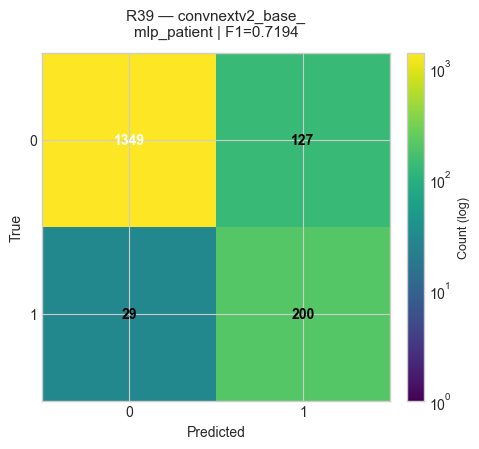

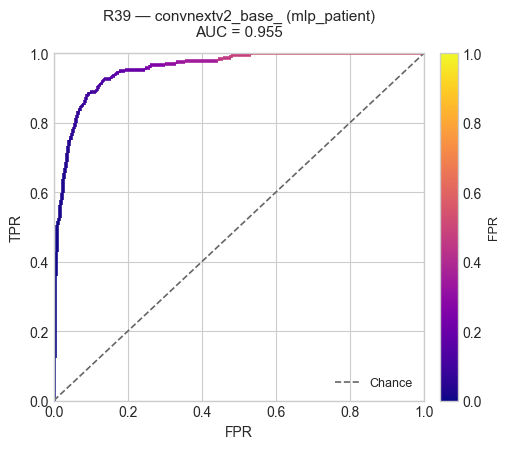


════════════════════════════════════════════════════════════════════════════════
[2/7] R39 — dinov3_convnext_base
  R28 hypers (KEPT): arch=(128,) α=1.0000 lr=0.000358 bs=64 w=2.46
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (99.5% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Stage B] 25 MLPs (R28 hypers + noise=0.05 + drop=0.05 + OD_range=(0.2, 0.85))


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# R39 Per-Encoder Main Loop — Augmentation-Only + MLP-only (NO HP retune)
# ═══════════════════════════════════════════════════════════════════════

print('═' * 80)
print('R39 — Eye-level Augmentation + R28 Hypers + MLP-only Stage 2')
print('  (HP re-tune REMOVED — it overfit on val)')
print('═' * 80)

r39_results = []
t0_global = time.time()

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)

    # ── Checkpoint ────────────────────────────────────────────────
    chk_dir = R39_DIR / f'{emb_idx:02d}_{sname}'
    chk_hp  = chk_dir / 'hyperparameters.json'
    if chk_hp.exists():
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — CACHED')
        with open(chk_hp) as _f:
            prev = json.load(_f)
        r39_results.append({
            'embedding': sname, 'best_method': prev.get('best_method','?'),
            'val_f1': prev['val_referable_f1'], 'test_f1': prev['test_referable_f1'],
            'test_prec': prev['test_referable_precision'],
            'test_rec': prev['test_referable_recall'],
            'test_auc': prev['test_referable_auc'],
            'test_ba': prev['test_referable_bal_acc'],
            'd1_val_f1': prev.get('d1_flex_val_f1', 0),
            'd2_val_f1': prev.get('d2_mlp_val_f1', 0),
            'time_s': 0,
        })
        continue

    if sname not in r28_hypers:
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — SKIPPED')
        continue

    hp = r28_hypers[sname]
    barch  = ast.literal_eval(hp['architecture']) if isinstance(hp['architecture'], str) else tuple(hp['architecture'])
    balpha = hp['alpha']
    blr    = hp['lr']
    bbs    = hp['batch_size']
    bw     = hp['pos_weight']

    print(f'\n{"═"*80}')
    print(f'[{emb_idx+1}/{len(embedding_files)}] R39 — {sname}')
    print(f'  R28 hypers (KEPT): arch={barch} α={balpha:.4f} lr={blr:.6f} bs={bbs} w={bw:.2f}')
    print(f'{"═"*80}')
    t0 = time.time()

    # ══════════════════════════════════════════════════════════════
    # STAGE A: Feature prep (identical to R37)
    # ══════════════════════════════════════════════════════════════
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)

    b_train = df[df['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
    b_val   = df[df['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
    b_test  = df[df['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()

    X_tr_emb = b_train[ds.feature_cols].to_numpy(dtype=np.float32)
    X_va_emb = b_val[ds.feature_cols].to_numpy(dtype=np.float32)
    X_te_emb = b_test[ds.feature_cols].to_numpy(dtype=np.float32)

    yb_train = b_train[TASK].to_numpy(dtype=int)
    yb_val   = b_val[TASK].to_numpy(dtype=int)
    yb_test  = b_test[TASK].to_numpy(dtype=int)

    pids_tr = b_train['patient_id'].to_numpy()
    pids_va = b_val['patient_id'].to_numpy()
    pids_te = b_test['patient_id'].to_numpy()

    emb_dim_raw = X_tr_emb.shape[1]

    # ── PCA ───────────────────────────────────────────────────────
    nc = min(PCA_COMPONENTS, emb_dim_raw, X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca.fit_transform(X_tr_emb)
    X_va_pca = pca.transform(X_va_emb)
    X_te_pca = pca.transform(X_te_emb)
    var_exp = pca.explained_variance_ratio_.sum()
    print(f'  PCA: {emb_dim_raw}→{nc} ({var_exp:.1%} var)')

    # ── MI Selection ──────────────────────────────────────────────
    if MI_SELECTION:
        X_tr_sel, (X_va_sel, X_te_sel), mi_mask, _ = mi_select_features(
            X_tr_pca, yb_train, [X_va_pca, X_te_pca],
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS, random_state=RANDOM_SEED,
        )
        n_kept = mi_mask.sum()
        print(f'  MI: {nc}→{n_kept}')
    else:
        X_tr_sel, X_va_sel, X_te_sel = X_tr_pca, X_va_pca, X_te_pca
        n_kept = nc

    # ── Metadata + OD ─────────────────────────────────────────────
    X_tr_meta, ms = encode_metadata(b_train, METADATA_COLS)
    X_va_meta, _  = encode_metadata(b_val, METADATA_COLS, fit_stats=ms)
    X_te_meta, _  = encode_metadata(b_test, METADATA_COLS, fit_stats=ms)
    meta_dim = X_tr_meta.shape[1]

    rng_hp = np.random.default_rng(RANDOM_SEED)
    od_tr, miss_tr = _mask_od(b_train['optic_disc'], OD_P_MASK_BASE, rng_hp, OD_CORRUPT)
    X_tr_full = np.hstack([X_tr_sel, X_tr_meta, od_tr, miss_tr])
    ndim = X_tr_full.shape[1]
    print(f'  Dims: {n_kept} PCA + {meta_dim} meta + 2 OD = {ndim}')

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_full)
    X_tr_s = _apply_od_weights(X_tr_s, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    rng_v = np.random.default_rng(RANDOM_SEED + 7000)
    rng_t = np.random.default_rng(RANDOM_SEED + 9999)
    od_v, miss_v = _mask_od(b_val['optic_disc'],  OD_TEST_P_MASK, rng_v)
    od_t, miss_t = _mask_od(b_test['optic_disc'], OD_TEST_P_MASK, rng_t)

    X_va_s = scaler.transform(np.hstack([X_va_sel, X_va_meta, od_v, miss_v]))
    X_te_s = scaler.transform(np.hstack([X_te_sel, X_te_meta, od_t, miss_t]))
    X_va_s = _apply_od_weights(X_va_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
    X_te_s = _apply_od_weights(X_te_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # ── Build patient labels ──────────────────────────────────────
    ref_train = build_referable_labels(b_train, TASK, BILATERAL_MIN_EYES)
    ref_val   = build_referable_labels(b_val,   TASK, BILATERAL_MIN_EYES)
    ref_test  = build_referable_labels(b_test,  TASK, BILATERAL_MIN_EYES)

    # ══════════════════════════════════════════════════════════════
    # STAGE B: 25-Bag Ensemble — R28 hypers + AUGMENTATION
    # ══════════════════════════════════════════════════════════════
    barchs = [barch, make_wider(barch), make_deeper(barch),
              make_narrower(barch), make_shallower(barch)]
    print(f'  [Stage B] {N_BAGS} MLPs (R28 hypers + noise={R39_NOISE_STD} '
          f'+ drop={R39_FEAT_DROP} + OD_range={R39_OD_MASK_RANGE})')

    cal_p, cal_l = {}, {}
    bag_tr_proba, bag_va_proba, bag_te_proba = [], [], []

    for s_idx, seed in enumerate(BAG_SEEDS):
        upids = np.unique(pids_tr)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
        plm = b_train.groupby('patient_id')[TASK].max().to_dict()
        pl  = np.array([plm[p] for p in upids])
        ti, vi = next(sss.split(upids, pl))
        itr_pids = set(upids[ti])
        iva_pids = set(upids[vi])

        tr_m = np.isin(pids_tr, list(itr_pids))
        va_m = np.isin(pids_tr, list(iva_pids))

        # OD masking — R39: widened range + higher corrupt
        rng_pm = np.random.default_rng(seed + 90000)
        pm_seed = float(rng_pm.uniform(R39_OD_MASK_RANGE[0], R39_OD_MASK_RANGE[1]))

        rng_it = np.random.default_rng(seed + 10000)
        od_it, miss_it = _mask_od(
            b_train.iloc[np.where(tr_m)[0]]['optic_disc'],
            pm_seed, rng_it, R39_OD_CORRUPT)
        X_it = scaler.transform(np.hstack([X_tr_sel[tr_m], X_tr_meta[tr_m], od_it, miss_it]))
        X_it = _apply_od_weights(X_it, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_it = yb_train[tr_m]

        rng_iv = np.random.default_rng(seed + 20000)
        od_iv, miss_iv = _mask_od(
            b_train.iloc[np.where(va_m)[0]]['optic_disc'],
            pm_seed, rng_iv, R39_OD_CORRUPT)
        X_iv = scaler.transform(np.hstack([X_tr_sel[va_m], X_tr_meta[va_m], od_iv, miss_iv]))
        X_iv = _apply_od_weights(X_iv, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_iv = yb_train[va_m]

        svp = []
        for a_idx, arch_v in enumerate(barchs):
            # ── R39 AUGMENTATION (training data only) ─────────────
            rng_aug = np.random.default_rng(seed * 100 + a_idx + 50000)
            X_it_aug = X_it.copy()

            # 1. Gaussian noise on PCA features (first n_kept cols)
            noise = rng_aug.normal(0, R39_NOISE_STD,
                                   (X_it_aug.shape[0], n_kept)).astype(np.float32)
            X_it_aug[:, :n_kept] += noise

            # 2. Feature column dropout on PCA features
            n_drop = max(1, int(R39_FEAT_DROP * n_kept))
            drop_cols = rng_aug.choice(n_kept, size=n_drop, replace=False)
            X_it_aug[:, drop_cols] = 0.0

            # ── Train with R28 hypers (proven, no retune) ─────────
            mlp = MLPClassifier(
                hidden_layer_sizes=arch_v,
                alpha=balpha,                 # R28 original
                learning_rate='adaptive',
                learning_rate_init=blr,       # R28 original
                batch_size=bbs,
                max_iter=MLP_MAX_ITER,
                early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=MLP_PATIENCE,
                random_state=seed + a_idx,
            )
            sw = make_sample_weights(y_it, bw)  # R28 original
            mlp.fit(X_it_aug, y_it, sample_weight=sw)

            # Predictions on CLEAN data (no augmentation)
            svp.append(mlp.predict_proba(X_iv)[:, 1])
            bag_tr_proba.append(mlp.predict_proba(X_tr_s)[:, 1])
            bag_va_proba.append(mlp.predict_proba(X_va_s)[:, 1])
            bag_te_proba.append(mlp.predict_proba(X_te_s)[:, 1])

        cal_p[seed] = np.mean(svp, axis=0)
        cal_l[seed] = y_iv

    # ── Calibration ───────────────────────────────────────────────
    cp = np.concatenate([cal_p[s] for s in BAG_SEEDS])
    cl = np.concatenate([cal_l[s] for s in BAG_SEEDS])
    iso = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')
    iso.fit(cp, cl)

    avg_tr_raw = np.mean(bag_tr_proba, axis=0)
    avg_va_raw = np.mean(bag_va_proba, axis=0)
    avg_te_raw = np.mean(bag_te_proba, axis=0)
    avg_tr_cal = iso.predict(avg_tr_raw)
    avg_va_cal = iso.predict(avg_va_raw)
    avg_te_cal = iso.predict(avg_te_raw)

    print(f'  Stage B done: {N_BAGS} eye-level MLPs (R28 hypers + augmented)')
    print(f'  Per-image proba: val=[{avg_va_cal.min():.3f}, {avg_va_cal.max():.3f}]  '
          f'test=[{avg_te_cal.min():.3f}, {avg_te_cal.max():.3f}]')

    # ══════════════════════════════════════════════════════════════
    # STAGE C: Patient features (7 trimmed)
    # ══════════════════════════════════════════════════════════════
    pos_mask_tr = yb_train == 1
    pos_centroid = X_tr_pca[pos_mask_tr].mean(axis=0)

    pf_train = extract_patient_features_r36(pids_tr, avg_tr_raw, avg_tr_cal,
                                             X_tr_pca, pos_centroid)
    pf_val   = extract_patient_features_r36(pids_va, avg_va_raw, avg_va_cal,
                                             X_va_pca, pos_centroid)
    pf_test  = extract_patient_features_r36(pids_te, avg_te_raw, avg_te_cal,
                                             X_te_pca, pos_centroid)

    com_tr = pf_train.index.intersection(ref_train.index)
    com_va = pf_val.index.intersection(ref_val.index)
    com_te = pf_test.index.intersection(ref_test.index)

    X_pat_tr = pf_train.loc[com_tr][R39_FEATURE_COLS].values.astype(np.float32)
    y_pat_tr = ref_train.loc[com_tr].values.astype(int)
    X_pat_va = pf_val.loc[com_va][R39_FEATURE_COLS].values.astype(np.float32)
    y_pat_va = ref_val.loc[com_va].values.astype(int)
    X_pat_te = pf_test.loc[com_te][R39_FEATURE_COLS].values.astype(np.float32)
    y_pat_te = ref_test.loc[com_te].values.astype(int)

    print(f'  Stage C: {len(R39_FEATURE_COLS)} patient features')
    print(f'    Train: {len(com_tr)} ({y_pat_tr.sum()} ref)  '
          f'Val: {len(com_va)} ({y_pat_va.sum()} ref)  '
          f'Test: {len(com_te)} ({y_pat_te.sum()} ref)')

    # ══════════════════════════════════════════════════════════════
    # STAGE D: D1 bilateral + D2 patient MLP (MLP-only)
    # ══════════════════════════════════════════════════════════════
    methods = {}

    # ── D1: Flexible bilateral + fast bootstrap ───────────────────
    print(f'  [D1] Bilateral flex + fast bootstrap ({BOOTSTRAP_N}×)')
    d1_best_f1, d1_best_t, d1_best_me, d1_best_pt = 0.0, 0.5, 2, 'raw'

    for pt_name, va_p, te_p in [
        ('cal', avg_va_cal, avg_te_cal),
        ('raw', avg_va_raw, avg_te_raw),
    ]:
        for me in FLEX_MIN_EYES:
            bt, bf1, _ = sweep_bilateral_threshold(
                pids_va, va_p, ref_val,
                min_eyes=me, grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR,
            )
            if bf1 > d1_best_f1:
                d1_best_f1, d1_best_t, d1_best_me, d1_best_pt = bf1, bt, me, pt_name

    d1_va_p = avg_va_cal if d1_best_pt == 'cal' else avg_va_raw
    d1_boot_t = bootstrap_bilateral_fast(
        pids_va, d1_va_p, ref_val,
        min_eyes=d1_best_me, n_boot=BOOTSTRAP_N,
        grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR, rng_seed=BOOTSTRAP_SEED,
    )

    te_p_d1 = avg_te_cal if d1_best_pt == 'cal' else avg_te_raw
    d1_test_agg = bilateral_patient_predictions(pids_te, te_p_d1, d1_boot_t, d1_best_me)
    d1_com = d1_test_agg.index.intersection(ref_test.index)
    d1_yt = ref_test.loc[d1_com].values
    d1_yh = d1_test_agg.loc[d1_com, 'referable_pred'].values
    d1_yp = d1_test_agg.loc[d1_com, 'max_proba'].values
    d1_test_f1 = float(f1_score(d1_yt, d1_yh, zero_division=0))

    d1_va_agg = bilateral_patient_predictions(pids_va, d1_va_p, d1_boot_t, d1_best_me)
    d1_va_com = d1_va_agg.index.intersection(ref_val.index)
    d1_va_yt = ref_val.loc[d1_va_com].values
    d1_va_yh = d1_va_agg.loc[d1_va_com, 'referable_pred'].values
    d1_boot_val_f1 = float(f1_score(d1_va_yt, d1_va_yh, zero_division=0))

    methods['bilateral_flex'] = {
        'val_f1': d1_boot_val_f1, 'test_f1': d1_test_f1,
        'yt': d1_yt, 'yh': d1_yh, 'yp': d1_yp, 'com': d1_com,
        'detail': f'min_eyes={d1_best_me}, thr={d1_boot_t:.3f}(boot), proba={d1_best_pt}',
    }
    print(f'    D1: min_eyes={d1_best_me}, thr={d1_best_t:.3f}→{d1_boot_t:.3f}(boot), '
          f'proba={d1_best_pt} → val_F1={d1_boot_val_f1:.4f}, test_F1={d1_test_f1:.4f}')

    # ── D2: Patient MLP (5 archs × 3 seeds = 15 candidates) ──────
    print(f'  [D2] Patient MLP ({len(R39_PAT_ARCHS)} archs × {len(R39_PAT_SEEDS)} seeds)')
    mlp_model, mlp_arch, mlp_t, mlp_val_f1, mlp_scaler = train_pat_mlp_r39(
        X_pat_tr, y_pat_tr, X_pat_va, y_pat_va,
        archs=R39_PAT_ARCHS, seeds=R39_PAT_SEEDS,
        n_boot=BOOTSTRAP_N, rng_seed=BOOTSTRAP_SEED,
    )
    mlp_te_proba = mlp_model.predict_proba(mlp_scaler.transform(X_pat_te))[:, 1]
    mlp_te_pred  = (mlp_te_proba >= mlp_t).astype(int)
    mlp_test_f1  = float(f1_score(y_pat_te, mlp_te_pred, zero_division=0))

    methods['mlp_patient'] = {
        'val_f1': mlp_val_f1, 'test_f1': mlp_test_f1,
        'yt': y_pat_te, 'yh': mlp_te_pred, 'yp': mlp_te_proba, 'com': com_te,
        'detail': f'arch={mlp_arch}, thr={mlp_t:.3f}(boot)',
    }
    print(f'    D2: arch={mlp_arch}, thr={mlp_t:.3f}(boot) → '
          f'val_F1={mlp_val_f1:.4f}, test_F1={mlp_test_f1:.4f}')

    # ── Hybrid selection ──────────────────────────────────────────
    d2_vf1 = methods['mlp_patient']['val_f1']
    d1_vf1 = methods['bilateral_flex']['val_f1']

    if (d2_vf1 - d1_vf1) < HYBRID_MARGIN and d1_vf1 > 0:
        best_name = 'bilateral_flex'
        print(f'  ★ HYBRID: D1 within {HYBRID_MARGIN} of mlp_patient → prefer D1')
    else:
        best_name = max(methods, key=lambda k: methods[k]['val_f1'])
    best = methods[best_name]
    print(f'  ★ BEST: {best_name} | val_F1={best["val_f1"]:.4f} | test_F1={best["test_f1"]:.4f}')
    print(f'    {best["detail"]}')

    # ══════════════════════════════════════════════════════════════
    # STAGE E: Save results
    # ══════════════════════════════════════════════════════════════
    yt, yh, yp = best['yt'], best['yh'], best['yp']
    test_f1   = float(f1_score(yt, yh, zero_division=0))
    test_prec = float(precision_score(yt, yh, zero_division=0))
    test_rec  = float(recall_score(yt, yh, zero_division=0))
    test_auc  = float(roc_auc_score(yt, yp)) if len(np.unique(yt)) > 1 else 0.0
    test_ba   = float(balanced_accuracy_score(yt, yh))
    elapsed = time.time() - t0

    print(f'\n  TEST: F1={test_f1:.4f}  Prec={test_prec:.4f}  Rec={test_rec:.4f}  '
          f'AUC={test_auc:.4f}  BalAcc={test_ba:.4f}')
    print(f'  Time: {elapsed:.0f}s')

    out_dir = R39_DIR / f'{emb_idx:02d}_{sname}'
    out_dir.mkdir(parents=True, exist_ok=True)

    cm = confusion_matrix(yt, yh)
    rep = classification_report(yt, yh, digits=3,
                                target_names=['Not Referable', 'Referable'])
    print(rep)

    pd.DataFrame(cm).to_csv(out_dir / 'confusion_matrix.csv', index=False)
    (out_dir / 'classification_report.txt').write_text(rep, encoding='utf-8')

    fpr, tpr, _ = roc_curve(yt, yp)
    pd.DataFrame({'fpr': fpr, 'tpr': tpr}).to_csv(out_dir / 'roc_curve.csv', index=False)

    pd.DataFrame({
        'patient_id': best['com'], 'y_true': yt, 'y_pred': yh, 'proba': yp,
    }).to_csv(out_dir / 'patient_predictions.csv', index=False)

    method_rows = []
    for mname, mdata in methods.items():
        method_rows.append({
            'method': mname, 'val_f1': mdata['val_f1'],
            'test_f1': mdata['test_f1'], 'detail': mdata['detail'],
            'is_best': mname == best_name,
        })
    pd.DataFrame(method_rows).to_csv(out_dir / 'method_comparison.csv', index=False)

    hp_save = {
        'track': 'R39', 'embedding': sname,
        'pipeline': 'MLP-only + R28 hypers + augmentation (no HP retune)',
        'best_method': best_name, 'method_detail': best['detail'],
        'r28_architecture': str(barch), 'r28_alpha': float(balpha),
        'r28_lr': float(blr), 'r28_batch_size': int(bbs),
        'r28_pos_weight': float(bw),
        'r39_noise_std': R39_NOISE_STD, 'r39_feat_drop': R39_FEAT_DROP,
        'r39_od_mask_range': list(R39_OD_MASK_RANGE),
        'r39_od_corrupt': R39_OD_CORRUPT,
        'pca_dim': nc, 'mi_selected': int(n_kept), 'pca_var': float(var_exp),
        'n_patient_features': len(R39_FEATURE_COLS),
        'patient_features': R39_FEATURE_COLS,
        'bootstrap_n': BOOTSTRAP_N, 'hybrid_margin': HYBRID_MARGIN,
        'd1_flex_val_f1':  float(methods['bilateral_flex']['val_f1']),
        'd1_flex_test_f1': float(methods['bilateral_flex']['test_f1']),
        'd1_min_eyes': d1_best_me, 'd1_threshold_boot': float(d1_boot_t),
        'd1_proba_type': d1_best_pt,
        'd2_mlp_val_f1':  float(methods['mlp_patient']['val_f1']),
        'd2_mlp_test_f1': float(methods['mlp_patient']['test_f1']),
        'd2_mlp_arch': str(mlp_arch), 'd2_mlp_threshold': float(mlp_t),
        'val_referable_f1': float(best['val_f1']),
        'test_referable_f1': test_f1,
        'test_referable_precision': test_prec,
        'test_referable_recall': test_rec,
        'test_referable_auc': test_auc,
        'test_referable_bal_acc': test_ba,
        'n_test_patients': int(len(yt)),
    }
    with open(out_dir / 'hyperparameters.json', 'w') as f:
        json.dump(hp_save, f, indent=2)

    plot_confusion_matrix(cm,
        title=f'R39 — {sname}\n{best_name} | F1={test_f1:.4f}',
        save_path=out_dir / 'confusion_matrix.png', show=True)
    plot_roc_curve(fpr, tpr, test_auc,
        title=f'R39 — {sname} ({best_name})',
        save_path=out_dir / 'roc_curve.png', show=True)

    r39_results.append({
        'embedding': sname, 'best_method': best_name,
        'val_f1': float(best['val_f1']), 'test_f1': test_f1,
        'test_prec': test_prec, 'test_rec': test_rec,
        'test_auc': test_auc, 'test_ba': test_ba,
        'd1_val_f1': float(methods['bilateral_flex']['val_f1']),
        'd2_val_f1': float(methods['mlp_patient']['val_f1']),
        'time_s': float(elapsed),
    })

total = time.time() - t0_global
print(f'\n{"═"*80}')
print(f'R39 complete! Total: {total:.0f}s ({total/60:.1f} min)')
print(f'{"═"*80}')

r39_df = pd.DataFrame(r39_results).sort_values('test_f1', ascending=False)
r39_df.to_csv(R39_DIR / 'r39_summary.csv', index=False)

print('\n── R39 Summary (sorted by Test F1) ──')
show_cols = ['embedding', 'best_method', 'val_f1', 'test_f1',
             'test_prec', 'test_rec', 'test_auc',
             'd1_val_f1', 'd2_val_f1']
print(r39_df[[c for c in show_cols if c in r39_df.columns]].to_string(index=False))

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# R39 vs R31 Comparison
# ═══════════════════════════════════════════════════════════════════════
r31_known = {
    'convnextv2_base_':             0.7445,
    'dinov3_convnext_base':         0.7640,
    'dinov3_vitb16':                0.8009,
    'RETFound_dinov2_shanghai':     0.7435,
    'RETFound_mae_natureCFP':       0.7025,
    'RETFound_mae_shanghai':        0.7286,
    'vit_base_':                    0.6992,
}

r36_known = {
    'convnextv2_base_':             0.7748,
    'dinov3_convnext_base':         0.7851,
    'dinov3_vitb16':                0.8009,
    'RETFound_dinov2_shanghai':     0.7787,
}

print('═' * 80)
print('R39 vs R36 vs R31 — Referable Glaucoma Test F1')
print('═' * 80)

rows = []
for _, row in r39_df.iterrows():
    enc = row['embedding']
    r39_f1 = row['test_f1']
    r31_f1 = r31_known.get(enc, None)
    r36_f1 = r36_known.get(enc, None)

    d31 = (r39_f1 - r31_f1) if r31_f1 is not None else None
    d36 = (r39_f1 - r36_f1) if r36_f1 is not None else None

    rows.append({
        'embedding': enc,
        'R31_F1': f'{r31_f1:.4f}' if r31_f1 else '—',
        'R36_F1': f'{r36_f1:.4f}' if r36_f1 else '—',
        'R39_F1': f'{r39_f1:.4f}',
        'method': row['best_method'],
        'hp_chg': '★' if row.get('hp_changed', False) else '',
        'Δ_vs_R31': f'{d31:+.4f}' if d31 is not None else '—',
        'Δ_vs_R36': f'{d36:+.4f}' if d36 is not None else '—',
    })

cdf = pd.DataFrame(rows)
print(cdf.to_string(index=False))

n_above_80 = sum(1 for _, r in r39_df.iterrows() if r['test_f1'] >= 0.80)
n_improved = sum(1 for row in rows
                 if row['Δ_vs_R31'] != '—' and float(row['Δ_vs_R31']) > 0)

print(f'\n≥0.80 F1: {n_above_80} / {len(r39_df)} encoders')
print(f'Improved vs R31: {n_improved} / {len(r39_df)} encoders')
print(f'Goal: ≥3 encoders at ≥0.80 F1')

## R40 — Complete R36 Pipeline + D4 Soft-Vote Ensemble

**What works (keeping):** R37's pipeline — 7 trimmed patient features, R28 eye-level hypers, 25-bag MLP ensemble, isotonic calibration, LogReg + LightGBM + bilateral flex + bootstrap + hybrid selection.

**What's new:** D4 soft-vote — averages patient-level probabilities from D1 (bilateral max_proba), D2 (LogReg), and D3 (LightGBM), then applies bootstrap-stabilized threshold. Reduces variance by combining 3 diverse decision mechanisms.

**Goal:** Complete all 7 encoders and push ≥3 to ≥0.80 F1.

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# R40 Config
# ═══════════════════════════════════════════════════════════════════════

R40_DIR = RESULTS_DIR / 'r40_soft_vote'
R40_DIR.mkdir(parents=True, exist_ok=True)

R40_FEATURE_COLS = [
    'max_proba', 'second_max', 'mean_proba', 'std_proba',
    'cal_raw_gap', 'emb_dist_to_pos_centroid', 'n_eyes',
]

# Soft-vote weights — equal weight for simplicity; could tune later
R40_VOTE_WEIGHTS = [1.0, 1.0, 1.0]  # D1, D2, D3

print(f'R40 config OK — R37 pipeline + D4 soft-vote')
print(f'  Patient features: {len(R40_FEATURE_COLS)} (trimmed)')
print(f'  Methods: D1 bilateral, D2 LogReg, D3 LightGBM, D4 soft-vote')
print(f'  Vote weights: {R40_VOTE_WEIGHTS}')
print(f'  Results dir: {R40_DIR}')

R40 config OK — R37 pipeline + D4 soft-vote
  Patient features: 7 (trimmed)
  Methods: D1 bilateral, D2 LogReg, D3 LightGBM, D4 soft-vote
  Vote weights: [1.0, 1.0, 1.0]
  Results dir: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r35_patient_model_cascade\r40_soft_vote


════════════════════════════════════════════════════════════════════════════════
R40 — R37 Pipeline + D4 Soft-Vote Ensemble
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
[1/7] R40 — convnextv2_base_
  R28 hypers: arch=(128,) α=1.0000 lr=0.000100 bs=64 w=4.07
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.8% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Stage B] 25 models (R28 hypers)
  Stage B done: 25 MLPs trained
  Per-image proba: val=[0.001, 0.999]  test=[0.001, 0.999]
  Stage C: 7 patient features
    Train: 5796 (789 ref)  Val: 1023 (157 ref)  Test: 1705 (229 ref)
  [D1] Bilateral flex + fast bootstrap (200×)
    D1: min_eyes=2, thr=0.432→0.439(boot), proba=raw → val_F1=0.7802, test_F1=0.7495
  [D2] Patient LogReg (7 feats, C=[0.01, 0.1, 1.0, 10.0])
    D2: C=0.1, thr=0.720(boot) → val_F1=0.8013, t

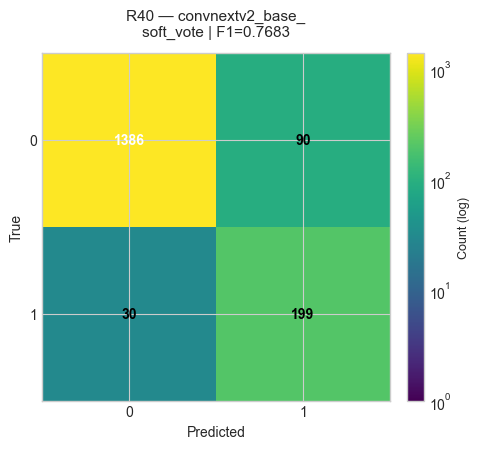

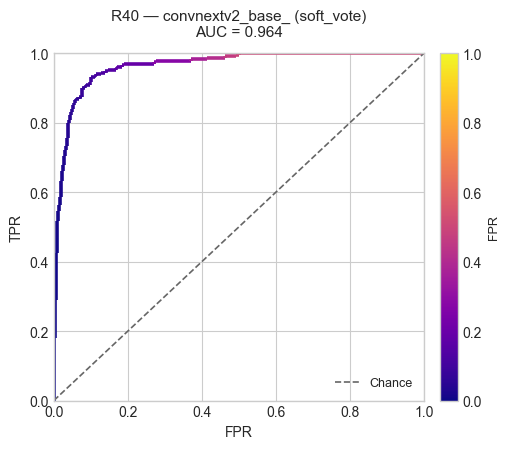


════════════════════════════════════════════════════════════════════════════════
[2/7] R40 — dinov3_convnext_base
  R28 hypers: arch=(128,) α=1.0000 lr=0.000358 bs=64 w=2.46
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (99.5% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Stage B] 25 models (R28 hypers)
  Stage B done: 25 MLPs trained
  Per-image proba: val=[0.001, 0.988]  test=[0.001, 0.999]
  Stage C: 7 patient features
    Train: 5796 (789 ref)  Val: 1023 (157 ref)  Test: 1705 (229 ref)
  [D1] Bilateral flex + fast bootstrap (200×)
    D1: min_eyes=2, thr=0.429→0.429(boot), proba=raw → val_F1=0.8000, test_F1=0.7640
  [D2] Patient LogReg (7 feats, C=[0.01, 0.1, 1.0, 10.0])
    D2: C=1.0, thr=0.855(boot) → val_F1=0.8013, test_F1=0.7758
  [D3] Patient LightGBM (7 feats)
    D3: thr=0.865(boot) → val_F1=0.8013, test_F1=0.7717
  [D4] Soft-vote (D1 + D2 + D3)
    D4: thr=0.820(boot) → val_F1=0.8013, test_F1=0.7883
  ★ HYBRI

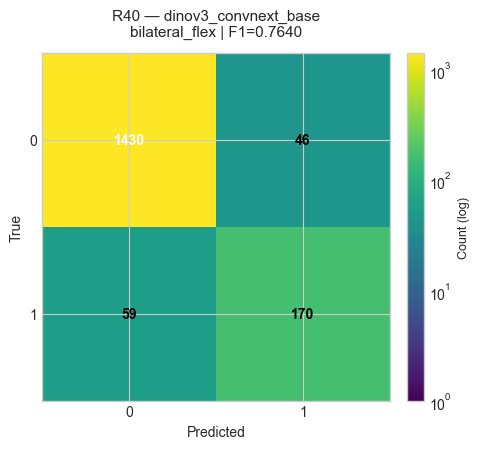

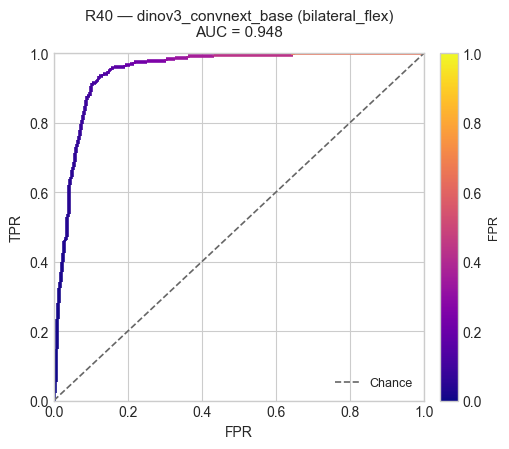


════════════════════════════════════════════════════════════════════════════════
[3/7] R40 — dinov3_vitb16
  R28 hypers: arch=(128,) α=1.0000 lr=0.000301 bs=256 w=2.45
════════════════════════════════════════════════════════════════════════════════
  PCA: 768→384 (98.7% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Stage B] 25 models (R28 hypers)
  Stage B done: 25 MLPs trained
  Per-image proba: val=[0.001, 0.999]  test=[0.001, 0.999]
  Stage C: 7 patient features
    Train: 5796 (789 ref)  Val: 1023 (157 ref)  Test: 1705 (229 ref)
  [D1] Bilateral flex + fast bootstrap (200×)
    D1: min_eyes=2, thr=0.294→0.294(boot), proba=raw → val_F1=0.8444, test_F1=0.8009
  [D2] Patient LogReg (7 feats, C=[0.01, 0.1, 1.0, 10.0])
    D2: C=1.0, thr=0.360(boot) → val_F1=0.8462, test_F1=0.7982
  [D3] Patient LightGBM (7 feats)
    D3: thr=0.125(boot) → val_F1=0.8435, test_F1=0.7991
  [D4] Soft-vote (D1 + D2 + D3)
    D4: thr=0.485(boot) → val_F1=0.8377, test_F1=0.8036
  ★ HYBRID: D1 w

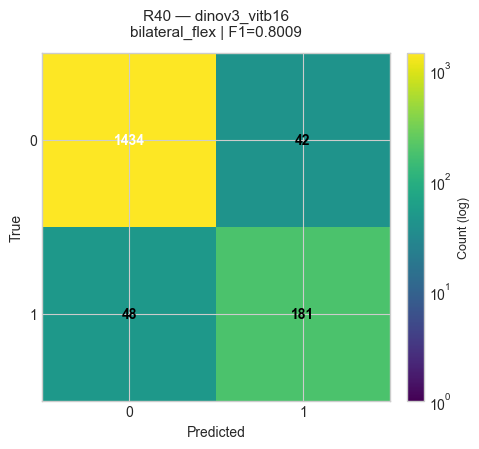

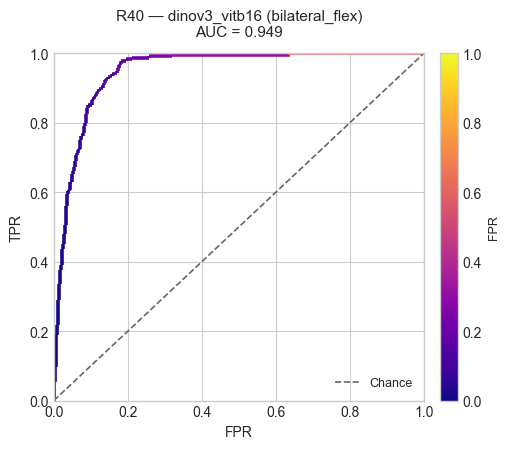


════════════════════════════════════════════════════════════════════════════════
[4/7] R40 — RETFound_dinov2_shanghai
  R28 hypers: arch=(512,) α=1.0000 lr=0.000100 bs=64 w=2.91
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.2% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Stage B] 25 models (R28 hypers)
  Stage B done: 25 MLPs trained
  Per-image proba: val=[0.001, 0.999]  test=[0.001, 0.999]
  Stage C: 7 patient features
    Train: 5796 (789 ref)  Val: 1023 (157 ref)  Test: 1705 (229 ref)
  [D1] Bilateral flex + fast bootstrap (200×)
    D1: min_eyes=2, thr=0.301→0.319(boot), proba=raw → val_F1=0.7964, test_F1=0.7514
  [D2] Patient LogReg (7 feats, C=[0.01, 0.1, 1.0, 10.0])
    D2: C=0.1, thr=0.575(boot) → val_F1=0.8239, test_F1=0.7780
  [D3] Patient LightGBM (7 feats)
    D3: thr=0.665(boot) → val_F1=0.8179, test_F1=0.7708
  [D4] Soft-vote (D1 + D2 + D3)
    D4: thr=0.580(boot) → val_F1=0.8261, test_F1=0.7836
  ★ B

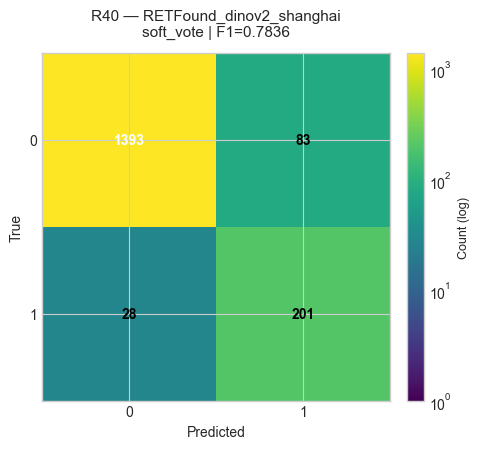

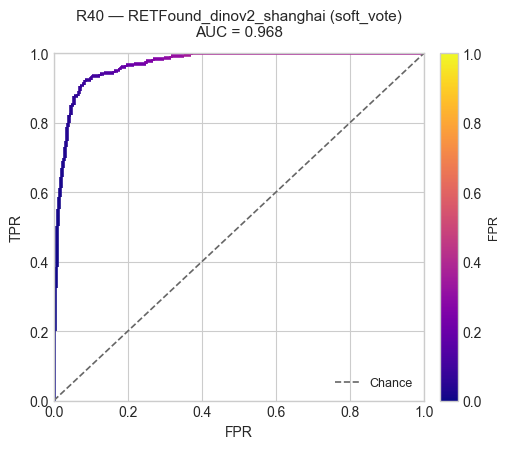


════════════════════════════════════════════════════════════════════════════════
[5/7] R40 — RETFound_mae_natureCFP
  R28 hypers: arch=(512,) α=0.0010 lr=0.000210 bs=64 w=3.37
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (99.3% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Stage B] 25 models (R28 hypers)
  Stage B done: 25 MLPs trained
  Per-image proba: val=[0.001, 0.999]  test=[0.001, 0.985]
  Stage C: 7 patient features
    Train: 5796 (789 ref)  Val: 1023 (157 ref)  Test: 1705 (229 ref)
  [D1] Bilateral flex + fast bootstrap (200×)
    D1: min_eyes=2, thr=0.460→0.442(boot), proba=raw → val_F1=0.7657, test_F1=0.6960
  [D2] Patient LogReg (7 feats, C=[0.01, 0.1, 1.0, 10.0])
    D2: C=0.1, thr=0.715(boot) → val_F1=0.7667, test_F1=0.7020
  [D3] Patient LightGBM (7 feats)
    D3: thr=0.555(boot) → val_F1=0.7342, test_F1=0.7056
  [D4] Soft-vote (D1 + D2 + D3)
    D4: thr=0.450(boot) → val_F1=0.7616, test_F1=0.6988
  ★ HYB

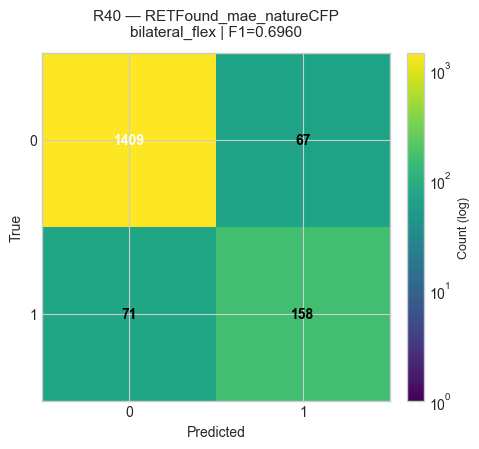

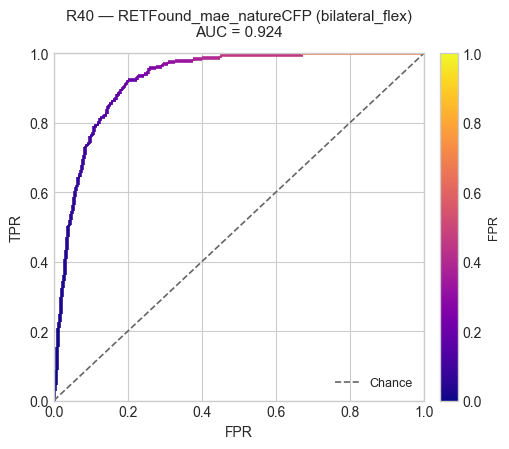


════════════════════════════════════════════════════════════════════════════════
[6/7] R40 — RETFound_mae_shanghai
  R28 hypers: arch=(256,) α=0.0014 lr=0.002000 bs=64 w=1.00
════════════════════════════════════════════════════════════════════════════════
  PCA: 1024→384 (98.9% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Stage B] 25 models (R28 hypers)
  Stage B done: 25 MLPs trained
  Per-image proba: val=[0.004, 0.999]  test=[0.004, 0.968]
  Stage C: 7 patient features
    Train: 5796 (789 ref)  Val: 1023 (157 ref)  Test: 1705 (229 ref)
  [D1] Bilateral flex + fast bootstrap (200×)
    D1: min_eyes=2, thr=0.219→0.219(boot), proba=raw → val_F1=0.8367, test_F1=0.7285
  [D2] Patient LogReg (7 feats, C=[0.01, 0.1, 1.0, 10.0])
    D2: C=10.0, thr=0.200(boot) → val_F1=0.8361, test_F1=0.7240
  [D3] Patient LightGBM (7 feats)
    D3: thr=0.170(boot) → val_F1=0.8400, test_F1=0.7359
  [D4] Soft-vote (D1 + D2 + D3)
    D4: thr=0.425(boot) → val_F1=0.8446, test_F1=0.7273
  ★ HYB

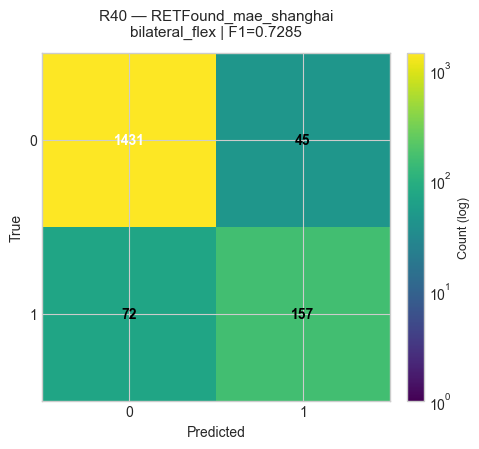

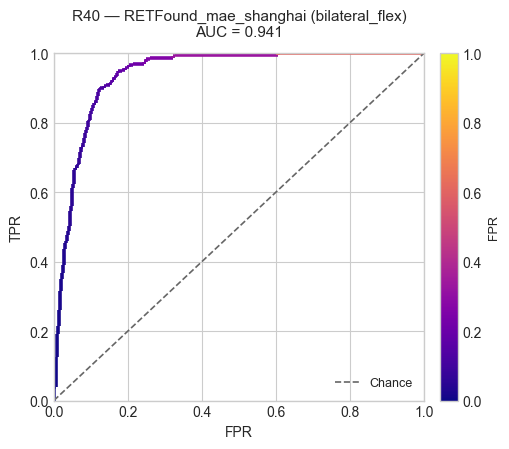


════════════════════════════════════════════════════════════════════════════════
[7/7] R40 — vit_base_
  R28 hypers: arch=(256,) α=0.0010 lr=0.002000 bs=256 w=2.62
════════════════════════════════════════════════════════════════════════════════
  PCA: 768→384 (98.9% var)
  MI: 384→384
  Dims: 384 PCA + 5 meta + 2 OD = 391
  [Stage B] 25 models (R28 hypers)
  Stage B done: 25 MLPs trained
  Per-image proba: val=[0.006, 0.999]  test=[0.001, 0.999]
  Stage C: 7 patient features
    Train: 5796 (789 ref)  Val: 1023 (157 ref)  Test: 1705 (229 ref)
  [D1] Bilateral flex + fast bootstrap (200×)
    D1: min_eyes=2, thr=0.219→0.219(boot), proba=raw → val_F1=0.7919, test_F1=0.6992
  [D2] Patient LogReg (7 feats, C=[0.01, 0.1, 1.0, 10.0])
    D2: C=1.0, thr=0.325(boot) → val_F1=0.7890, test_F1=0.7344
  [D3] Patient LightGBM (7 feats)
    D3: thr=0.295(boot) → val_F1=0.7926, test_F1=0.7243
  [D4] Soft-vote (D1 + D2 + D3)
    D4: thr=0.580(boot) → val_F1=0.7949, test_F1=0.7414
  ★ HYBRID: D1 withi

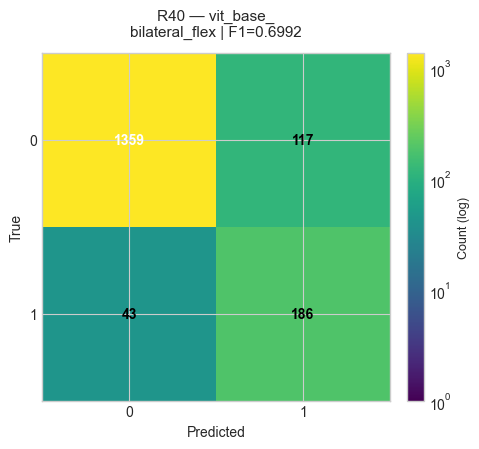

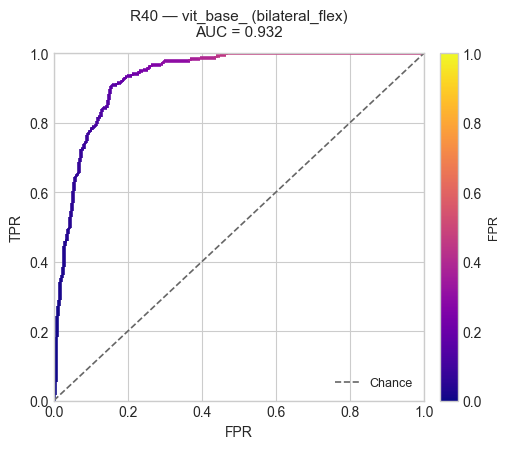


════════════════════════════════════════════════════════════════════════════════
R40 complete! Total: 5877s (97.9 min)
════════════════════════════════════════════════════════════════════════════════

── R40 Summary (sorted by Test F1) ──
               embedding    best_method   val_f1  test_f1  test_prec  test_rec  test_auc  d1_test_f1  d2_test_f1  d3_test_f1  d4_test_f1
           dinov3_vitb16 bilateral_flex 0.844444 0.800885   0.811659  0.790393  0.948628    0.800885    0.798226    0.799127    0.803571
RETFound_dinov2_shanghai      soft_vote 0.826087 0.783626   0.707746  0.877729  0.967897    0.751423    0.777996    0.770791    0.783626
        convnextv2_base_      soft_vote 0.815710 0.768340   0.688581  0.868996  0.964355    0.749491    0.764826    0.769531    0.768340
    dinov3_convnext_base bilateral_flex 0.800000 0.764045   0.787037  0.742358  0.948276    0.764045    0.775785    0.771689    0.788288
   RETFound_mae_shanghai bilateral_flex 0.836735 0.728538   0.777228  0.685

In [9]:
# ═══════════════════════════════════════════════════════════════════════
# R40 Per-Encoder Main Loop — R37 + D4 Soft-Vote
# ═══════════════════════════════════════════════════════════════════════

print('═' * 80)
print('R40 — R37 Pipeline + D4 Soft-Vote Ensemble')
print('═' * 80)

r40_results = []
t0_global = time.time()

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)

    # ── Checkpoint ────────────────────────────────────────────────
    chk_dir = R40_DIR / f'{emb_idx:02d}_{sname}'
    chk_hp  = chk_dir / 'hyperparameters.json'
    if chk_hp.exists():
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — CACHED')
        with open(chk_hp) as _f:
            prev = json.load(_f)
        r40_results.append({
            'embedding': sname, 'best_method': prev.get('best_method','?'),
            'val_f1': prev['val_referable_f1'], 'test_f1': prev['test_referable_f1'],
            'test_prec': prev['test_referable_precision'],
            'test_rec': prev['test_referable_recall'],
            'test_auc': prev['test_referable_auc'],
            'test_ba': prev['test_referable_bal_acc'],
            'd1_val_f1': prev.get('d1_flex_val_f1', 0),
            'd2_val_f1': prev.get('d2_logreg_val_f1', 0),
            'd3_val_f1': prev.get('d3_lgbm_val_f1', 0),
            'd4_val_f1': prev.get('d4_vote_val_f1', 0),
            'time_s': 0,
        })
        continue

    if sname not in r28_hypers:
        print(f'\n[{emb_idx+1}/{len(embedding_files)}] {sname} — SKIPPED')
        continue

    hp = r28_hypers[sname]
    barch  = ast.literal_eval(hp['architecture']) if isinstance(hp['architecture'], str) else tuple(hp['architecture'])
    balpha = hp['alpha']
    blr    = hp['lr']
    bbs    = hp['batch_size']
    bw     = hp['pos_weight']

    print(f'\n{"═"*80}')
    print(f'[{emb_idx+1}/{len(embedding_files)}] R40 — {sname}')
    print(f'  R28 hypers: arch={barch} α={balpha:.4f} lr={blr:.6f} bs={bbs} w={bw:.2f}')
    print(f'{"═"*80}')
    t0 = time.time()

    # ══════════════════════════════════════════════════════════════
    # STAGE A: Feature prep (identical to R37)
    # ══════════════════════════════════════════════════════════════
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME, embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)

    b_train = df[df['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
    b_val   = df[df['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
    b_test  = df[df['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()

    X_tr_emb = b_train[ds.feature_cols].to_numpy(dtype=np.float32)
    X_va_emb = b_val[ds.feature_cols].to_numpy(dtype=np.float32)
    X_te_emb = b_test[ds.feature_cols].to_numpy(dtype=np.float32)

    yb_train = b_train[TASK].to_numpy(dtype=int)
    yb_val   = b_val[TASK].to_numpy(dtype=int)
    yb_test  = b_test[TASK].to_numpy(dtype=int)

    pids_tr = b_train['patient_id'].to_numpy()
    pids_va = b_val['patient_id'].to_numpy()
    pids_te = b_test['patient_id'].to_numpy()

    emb_dim_raw = X_tr_emb.shape[1]

    # ── PCA ───────────────────────────────────────────────────────
    nc = min(PCA_COMPONENTS, emb_dim_raw, X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca.fit_transform(X_tr_emb)
    X_va_pca = pca.transform(X_va_emb)
    X_te_pca = pca.transform(X_te_emb)
    var_exp = pca.explained_variance_ratio_.sum()
    print(f'  PCA: {emb_dim_raw}→{nc} ({var_exp:.1%} var)')

    # ── MI Selection ──────────────────────────────────────────────
    if MI_SELECTION:
        X_tr_sel, (X_va_sel, X_te_sel), mi_mask, _ = mi_select_features(
            X_tr_pca, yb_train, [X_va_pca, X_te_pca],
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS, random_state=RANDOM_SEED,
        )
        n_kept = mi_mask.sum()
        print(f'  MI: {nc}→{n_kept}')
    else:
        X_tr_sel, X_va_sel, X_te_sel = X_tr_pca, X_va_pca, X_te_pca
        n_kept = nc

    # ── Metadata + OD ─────────────────────────────────────────────
    X_tr_meta, ms = encode_metadata(b_train, METADATA_COLS)
    X_va_meta, _  = encode_metadata(b_val, METADATA_COLS, fit_stats=ms)
    X_te_meta, _  = encode_metadata(b_test, METADATA_COLS, fit_stats=ms)
    meta_dim = X_tr_meta.shape[1]

    rng_hp = np.random.default_rng(RANDOM_SEED)
    od_tr, miss_tr = _mask_od(b_train['optic_disc'], OD_P_MASK_BASE, rng_hp, OD_CORRUPT)
    X_tr_full = np.hstack([X_tr_sel, X_tr_meta, od_tr, miss_tr])
    ndim = X_tr_full.shape[1]
    print(f'  Dims: {n_kept} PCA + {meta_dim} meta + 2 OD = {ndim}')

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_full)
    X_tr_s = _apply_od_weights(X_tr_s, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    rng_v = np.random.default_rng(RANDOM_SEED + 7000)
    rng_t = np.random.default_rng(RANDOM_SEED + 9999)
    od_v, miss_v = _mask_od(b_val['optic_disc'],  OD_TEST_P_MASK, rng_v)
    od_t, miss_t = _mask_od(b_test['optic_disc'], OD_TEST_P_MASK, rng_t)

    X_va_s = scaler.transform(np.hstack([X_va_sel, X_va_meta, od_v, miss_v]))
    X_te_s = scaler.transform(np.hstack([X_te_sel, X_te_meta, od_t, miss_t]))
    X_va_s = _apply_od_weights(X_va_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
    X_te_s = _apply_od_weights(X_te_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # ══════════════════════════════════════════════════════════════
    # STAGE B: 25-Bag Ensemble (identical to R37)
    # ══════════════════════════════════════════════════════════════
    barchs = [barch, make_wider(barch), make_deeper(barch),
              make_narrower(barch), make_shallower(barch)]
    print(f'  [Stage B] {N_BAGS} models (R28 hypers)')

    cal_p, cal_l = {}, {}
    bag_tr_proba, bag_va_proba, bag_te_proba = [], [], []

    for s_idx, seed in enumerate(BAG_SEEDS):
        upids = np.unique(pids_tr)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
        plm = b_train.groupby('patient_id')[TASK].max().to_dict()
        pl  = np.array([plm[p] for p in upids])
        ti, vi = next(sss.split(upids, pl))
        itr_pids = set(upids[ti])
        iva_pids = set(upids[vi])

        tr_m = np.isin(pids_tr, list(itr_pids))
        va_m = np.isin(pids_tr, list(iva_pids))

        rng_pm = np.random.default_rng(seed + 90000)
        pm_seed = float(rng_pm.uniform(OD_P_MASK_RANGE[0], OD_P_MASK_RANGE[1]))

        rng_it = np.random.default_rng(seed + 10000)
        od_it, miss_it = _mask_od(
            b_train.iloc[np.where(tr_m)[0]]['optic_disc'], pm_seed, rng_it, OD_CORRUPT)
        X_it = scaler.transform(np.hstack([X_tr_sel[tr_m], X_tr_meta[tr_m], od_it, miss_it]))
        X_it = _apply_od_weights(X_it, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_it = yb_train[tr_m]

        rng_iv = np.random.default_rng(seed + 20000)
        od_iv, miss_iv = _mask_od(
            b_train.iloc[np.where(va_m)[0]]['optic_disc'], pm_seed, rng_iv, OD_CORRUPT)
        X_iv = scaler.transform(np.hstack([X_tr_sel[va_m], X_tr_meta[va_m], od_iv, miss_iv]))
        X_iv = _apply_od_weights(X_iv, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_iv = yb_train[va_m]

        svp = []
        for a_idx, arch_v in enumerate(barchs):
            mlp = MLPClassifier(
                hidden_layer_sizes=arch_v, alpha=balpha,
                learning_rate='adaptive', learning_rate_init=blr,
                batch_size=bbs, max_iter=MLP_MAX_ITER,
                early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=MLP_PATIENCE, random_state=seed + a_idx,
            )
            sw = make_sample_weights(y_it, bw)
            mlp.fit(X_it, y_it, sample_weight=sw)

            svp.append(mlp.predict_proba(X_iv)[:, 1])
            bag_tr_proba.append(mlp.predict_proba(X_tr_s)[:, 1])
            bag_va_proba.append(mlp.predict_proba(X_va_s)[:, 1])
            bag_te_proba.append(mlp.predict_proba(X_te_s)[:, 1])

        cal_p[seed] = np.mean(svp, axis=0)
        cal_l[seed] = y_iv

    # ── Calibration ───────────────────────────────────────────────
    cp = np.concatenate([cal_p[s] for s in BAG_SEEDS])
    cl = np.concatenate([cal_l[s] for s in BAG_SEEDS])
    iso = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')
    iso.fit(cp, cl)

    avg_tr_raw = np.mean(bag_tr_proba, axis=0)
    avg_va_raw = np.mean(bag_va_proba, axis=0)
    avg_te_raw = np.mean(bag_te_proba, axis=0)
    avg_tr_cal = iso.predict(avg_tr_raw)
    avg_va_cal = iso.predict(avg_va_raw)
    avg_te_cal = iso.predict(avg_te_raw)

    print(f'  Stage B done: {N_BAGS} MLPs trained')
    print(f'  Per-image proba: val=[{avg_va_cal.min():.3f}, {avg_va_cal.max():.3f}]  '
          f'test=[{avg_te_cal.min():.3f}, {avg_te_cal.max():.3f}]')

    # ══════════════════════════════════════════════════════════════
    # STAGE C: Patient features — 7 trimmed
    # ══════════════════════════════════════════════════════════════
    pos_mask_tr = yb_train == 1
    pos_centroid = X_tr_pca[pos_mask_tr].mean(axis=0)

    ref_train = build_referable_labels(b_train, TASK, BILATERAL_MIN_EYES)
    ref_val   = build_referable_labels(b_val, TASK, BILATERAL_MIN_EYES)
    ref_test  = build_referable_labels(b_test, TASK, BILATERAL_MIN_EYES)

    pf_train = extract_patient_features_r36(pids_tr, avg_tr_raw, avg_tr_cal,
                                             X_tr_pca, pos_centroid)
    pf_val   = extract_patient_features_r36(pids_va, avg_va_raw, avg_va_cal,
                                             X_va_pca, pos_centroid)
    pf_test  = extract_patient_features_r36(pids_te, avg_te_raw, avg_te_cal,
                                             X_te_pca, pos_centroid)

    com_tr = pf_train.index.intersection(ref_train.index)
    com_va = pf_val.index.intersection(ref_val.index)
    com_te = pf_test.index.intersection(ref_test.index)

    X_pat_tr = pf_train.loc[com_tr][R40_FEATURE_COLS].values.astype(np.float32)
    y_pat_tr = ref_train.loc[com_tr].values.astype(int)
    X_pat_va = pf_val.loc[com_va][R40_FEATURE_COLS].values.astype(np.float32)
    y_pat_va = ref_val.loc[com_va].values.astype(int)
    X_pat_te = pf_test.loc[com_te][R40_FEATURE_COLS].values.astype(np.float32)
    y_pat_te = ref_test.loc[com_te].values.astype(int)

    print(f'  Stage C: {len(R40_FEATURE_COLS)} patient features')
    print(f'    Train: {len(com_tr)} ({y_pat_tr.sum()} ref)  '
          f'Val: {len(com_va)} ({y_pat_va.sum()} ref)  '
          f'Test: {len(com_te)} ({y_pat_te.sum()} ref)')

    # ══════════════════════════════════════════════════════════════
    # STAGE D: D1 bilateral + D2 LogReg + D3 LightGBM + D4 soft-vote
    # ══════════════════════════════════════════════════════════════
    methods = {}

    # ── D1: Flexible bilateral + fast bootstrap ───────────────────
    print(f'  [D1] Bilateral flex + fast bootstrap ({BOOTSTRAP_N}×)')
    d1_best_f1, d1_best_t, d1_best_me, d1_best_pt = 0.0, 0.5, 2, 'raw'

    for pt_name, va_p, te_p in [
        ('cal', avg_va_cal, avg_te_cal),
        ('raw', avg_va_raw, avg_te_raw),
    ]:
        for me in FLEX_MIN_EYES:
            bt, bf1, _ = sweep_bilateral_threshold(
                pids_va, va_p, ref_val,
                min_eyes=me, grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR,
            )
            if bf1 > d1_best_f1:
                d1_best_f1, d1_best_t, d1_best_me, d1_best_pt = bf1, bt, me, pt_name

    d1_va_p = avg_va_cal if d1_best_pt == 'cal' else avg_va_raw
    d1_boot_t = bootstrap_bilateral_fast(
        pids_va, d1_va_p, ref_val,
        min_eyes=d1_best_me, n_boot=BOOTSTRAP_N,
        grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR, rng_seed=BOOTSTRAP_SEED,
    )

    te_p_d1 = avg_te_cal if d1_best_pt == 'cal' else avg_te_raw
    d1_test_agg = bilateral_patient_predictions(pids_te, te_p_d1, d1_boot_t, d1_best_me)
    d1_com = d1_test_agg.index.intersection(ref_test.index)
    d1_yt = ref_test.loc[d1_com].values
    d1_yh = d1_test_agg.loc[d1_com, 'referable_pred'].values
    d1_yp = d1_test_agg.loc[d1_com, 'max_proba'].values
    d1_test_f1 = float(f1_score(d1_yt, d1_yh, zero_division=0))

    d1_va_agg = bilateral_patient_predictions(pids_va, d1_va_p, d1_boot_t, d1_best_me)
    d1_va_com = d1_va_agg.index.intersection(ref_val.index)
    d1_va_yt = ref_val.loc[d1_va_com].values
    d1_va_yh = d1_va_agg.loc[d1_va_com, 'referable_pred'].values
    d1_boot_val_f1 = float(f1_score(d1_va_yt, d1_va_yh, zero_division=0))

    methods['bilateral_flex'] = {
        'val_f1': d1_boot_val_f1, 'test_f1': d1_test_f1,
        'yt': d1_yt, 'yh': d1_yh, 'yp': d1_yp, 'com': d1_com,
        'detail': f'min_eyes={d1_best_me}, thr={d1_boot_t:.3f}(boot), proba={d1_best_pt}',
    }
    print(f'    D1: min_eyes={d1_best_me}, thr={d1_best_t:.3f}→{d1_boot_t:.3f}(boot), '
          f'proba={d1_best_pt} → val_F1={d1_boot_val_f1:.4f}, test_F1={d1_test_f1:.4f}')

    # ── D2: Patient LogReg ────────────────────────────────────────
    print(f'  [D2] Patient LogReg (7 feats, C={LR_C_VALUES})')
    lr_model, lr_C, lr_t, lr_val_f1, lr_scaler = train_patient_logreg_r36(
        X_pat_tr, y_pat_tr, X_pat_va, y_pat_va,
        C_values=LR_C_VALUES, threshold_grid=181,
        n_boot=BOOTSTRAP_N, rng_seed=BOOTSTRAP_SEED,
    )
    lr_va_proba = lr_model.predict_proba(lr_scaler.transform(X_pat_va))[:, 1]
    lr_te_proba = lr_model.predict_proba(lr_scaler.transform(X_pat_te))[:, 1]
    lr_te_pred  = (lr_te_proba >= lr_t).astype(int)
    lr_test_f1  = float(f1_score(y_pat_te, lr_te_pred, zero_division=0))

    methods['logreg_patient'] = {
        'val_f1': lr_val_f1, 'test_f1': lr_test_f1,
        'yt': y_pat_te, 'yh': lr_te_pred, 'yp': lr_te_proba, 'com': com_te,
        'detail': f'C={lr_C}, thr={lr_t:.3f}(boot)',
    }
    print(f'    D2: C={lr_C}, thr={lr_t:.3f}(boot) → '
          f'val_F1={lr_val_f1:.4f}, test_F1={lr_test_f1:.4f}')

    # ── D3: Patient LightGBM ─────────────────────────────────────
    print(f'  [D3] Patient LightGBM (7 feats)')
    lgb_model, lgb_t, lgb_val_f1 = train_patient_lgbm_r36(
        X_pat_tr, y_pat_tr, X_pat_va, y_pat_va,
        lgb_params=LGB_PARAMS, threshold_grid=181,
        n_boot=BOOTSTRAP_N, rng_seed=BOOTSTRAP_SEED,
    )
    lgb_va_proba = lgb_model.predict_proba(X_pat_va)[:, 1]
    lgb_te_proba = lgb_model.predict_proba(X_pat_te)[:, 1]
    lgb_te_pred  = (lgb_te_proba >= lgb_t).astype(int)
    lgb_test_f1  = float(f1_score(y_pat_te, lgb_te_pred, zero_division=0))

    methods['lgbm_patient'] = {
        'val_f1': lgb_val_f1, 'test_f1': lgb_test_f1,
        'yt': y_pat_te, 'yh': lgb_te_pred, 'yp': lgb_te_proba, 'com': com_te,
        'detail': f'thr={lgb_t:.3f}(boot)',
    }
    print(f'    D3: thr={lgb_t:.3f}(boot) → '
          f'val_F1={lgb_val_f1:.4f}, test_F1={lgb_test_f1:.4f}')

    # ── D4: Soft-vote ensemble (D1 + D2 + D3) ────────────────────
    print(f'  [D4] Soft-vote (D1 + D2 + D3)')

    # Align D1 probabilities to patient-level (same index as D2/D3)
    # D1 gives max_proba per patient; D2/D3 give model probas on com_te
    d1_te_agg_full = bilateral_patient_predictions(pids_te, te_p_d1, d1_boot_t, d1_best_me)
    d1_va_agg_full = bilateral_patient_predictions(pids_va, d1_va_p, d1_boot_t, d1_best_me)

    # Patient probas for voting — use max_proba from D1
    d1_va_vote = d1_va_agg_full.reindex(com_va)['max_proba'].values.astype(np.float32)
    d1_te_vote = d1_te_agg_full.reindex(com_te)['max_proba'].values.astype(np.float32)

    w = np.array(R40_VOTE_WEIGHTS, dtype=np.float32)
    w = w / w.sum()  # normalize

    vote_va_proba = w[0] * d1_va_vote + w[1] * lr_va_proba + w[2] * lgb_va_proba
    vote_te_proba = w[0] * d1_te_vote + w[1] * lr_te_proba + w[2] * lgb_te_proba

    # Bootstrap-stabilized threshold for D4
    vote_t = bootstrap_threshold(y_pat_va, vote_va_proba,
                                  n_boot=BOOTSTRAP_N, grid_size=181,
                                  rng_seed=BOOTSTRAP_SEED)
    vote_va_pred = (vote_va_proba >= vote_t).astype(int)
    vote_va_f1 = float(f1_score(y_pat_va, vote_va_pred, zero_division=0))
    vote_te_pred = (vote_te_proba >= vote_t).astype(int)
    vote_te_f1 = float(f1_score(y_pat_te, vote_te_pred, zero_division=0))

    methods['soft_vote'] = {
        'val_f1': vote_va_f1, 'test_f1': vote_te_f1,
        'yt': y_pat_te, 'yh': vote_te_pred, 'yp': vote_te_proba, 'com': com_te,
        'detail': f'w={w.tolist()}, thr={vote_t:.3f}(boot)',
    }
    print(f'    D4: thr={vote_t:.3f}(boot) → '
          f'val_F1={vote_va_f1:.4f}, test_F1={vote_te_f1:.4f}')

    # ── Hybrid selection ──────────────────────────────────────────
    # Pick best on val, but prefer D1 if within margin
    model_best_name = max(methods, key=lambda k: methods[k]['val_f1'])
    model_best_vf1  = methods[model_best_name]['val_f1']
    d1_vf1 = methods['bilateral_flex']['val_f1']

    if (model_best_vf1 - d1_vf1) < HYBRID_MARGIN and d1_vf1 > 0:
        best_name = 'bilateral_flex'
        print(f'  ★ HYBRID: D1 within {HYBRID_MARGIN} of {model_best_name} → prefer D1')
    else:
        best_name = model_best_name
    best = methods[best_name]
    print(f'  ★ BEST: {best_name} | val_F1={best["val_f1"]:.4f} | test_F1={best["test_f1"]:.4f}')
    print(f'    {best["detail"]}')

    # ══════════════════════════════════════════════════════════════
    # STAGE E: Save results
    # ══════════════════════════════════════════════════════════════
    yt, yh, yp = best['yt'], best['yh'], best['yp']
    test_f1   = float(f1_score(yt, yh, zero_division=0))
    test_prec = float(precision_score(yt, yh, zero_division=0))
    test_rec  = float(recall_score(yt, yh, zero_division=0))
    test_auc  = float(roc_auc_score(yt, yp)) if len(np.unique(yt)) > 1 else 0.0
    test_ba   = float(balanced_accuracy_score(yt, yh))
    elapsed = time.time() - t0

    print(f'\n  TEST: F1={test_f1:.4f}  Prec={test_prec:.4f}  Rec={test_rec:.4f}  '
          f'AUC={test_auc:.4f}  BalAcc={test_ba:.4f}')
    print(f'  Time: {elapsed:.0f}s')

    out_dir = R40_DIR / f'{emb_idx:02d}_{sname}'
    out_dir.mkdir(parents=True, exist_ok=True)

    cm = confusion_matrix(yt, yh)
    rep = classification_report(yt, yh, digits=3,
                                target_names=['Not Referable', 'Referable'])
    print(rep)

    pd.DataFrame(cm).to_csv(out_dir / 'confusion_matrix.csv', index=False)
    (out_dir / 'classification_report.txt').write_text(rep, encoding='utf-8')

    fpr, tpr, _ = roc_curve(yt, yp)
    pd.DataFrame({'fpr': fpr, 'tpr': tpr}).to_csv(out_dir / 'roc_curve.csv', index=False)

    pd.DataFrame({
        'patient_id': best['com'], 'y_true': yt, 'y_pred': yh, 'proba': yp,
    }).to_csv(out_dir / 'patient_predictions.csv', index=False)

    method_rows = []
    for mname, mdata in methods.items():
        method_rows.append({
            'method': mname, 'val_f1': mdata['val_f1'],
            'test_f1': mdata['test_f1'], 'detail': mdata['detail'],
            'is_best': mname == best_name,
        })
    pd.DataFrame(method_rows).to_csv(out_dir / 'method_comparison.csv', index=False)

    if hasattr(lgb_model, 'feature_importances_'):
        feat_imp = pd.DataFrame({
            'feature': R40_FEATURE_COLS,
            'importance': lgb_model.feature_importances_,
        }).sort_values('importance', ascending=False)
        feat_imp.to_csv(out_dir / 'lgbm_feature_importance.csv', index=False)

    hp_save = {
        'track': 'R40', 'embedding': sname,
        'pipeline': 'R37 + D4 soft-vote',
        'best_method': best_name, 'method_detail': best['detail'],
        'r28_architecture': str(barch), 'r28_alpha': float(balpha),
        'r28_lr': float(blr), 'r28_batch_size': int(bbs),
        'r28_pos_weight': float(bw),
        'pca_dim': nc, 'mi_selected': int(n_kept), 'pca_var': float(var_exp),
        'n_patient_features': len(R40_FEATURE_COLS),
        'patient_features': R40_FEATURE_COLS,
        'bootstrap_n': BOOTSTRAP_N, 'hybrid_margin': HYBRID_MARGIN,
        'vote_weights': R40_VOTE_WEIGHTS,
        'd1_flex_val_f1':   float(methods['bilateral_flex']['val_f1']),
        'd1_flex_test_f1':  float(methods['bilateral_flex']['test_f1']),
        'd1_min_eyes': d1_best_me, 'd1_threshold_boot': float(d1_boot_t),
        'd1_proba_type': d1_best_pt,
        'd2_logreg_val_f1': float(methods['logreg_patient']['val_f1']),
        'd2_logreg_test_f1':float(methods['logreg_patient']['test_f1']),
        'd2_C': float(lr_C), 'd2_threshold': float(lr_t),
        'd3_lgbm_val_f1':   float(methods['lgbm_patient']['val_f1']),
        'd3_lgbm_test_f1':  float(methods['lgbm_patient']['test_f1']),
        'd3_threshold': float(lgb_t),
        'd4_vote_val_f1':   float(methods['soft_vote']['val_f1']),
        'd4_vote_test_f1':  float(methods['soft_vote']['test_f1']),
        'd4_vote_threshold': float(vote_t),
        'val_referable_f1': float(best['val_f1']),
        'test_referable_f1': test_f1,
        'test_referable_precision': test_prec,
        'test_referable_recall': test_rec,
        'test_referable_auc': test_auc,
        'test_referable_bal_acc': test_ba,
        'n_test_patients': int(len(yt)),
    }
    with open(out_dir / 'hyperparameters.json', 'w') as f:
        json.dump(hp_save, f, indent=2)

    plot_confusion_matrix(cm,
        title=f'R40 — {sname}\n{best_name} | F1={test_f1:.4f}',
        save_path=out_dir / 'confusion_matrix.png', show=True)
    plot_roc_curve(fpr, tpr, test_auc,
        title=f'R40 — {sname} ({best_name})',
        save_path=out_dir / 'roc_curve.png', show=True)

    r40_results.append({
        'embedding': sname, 'best_method': best_name,
        'val_f1': float(best['val_f1']), 'test_f1': test_f1,
        'test_prec': test_prec, 'test_rec': test_rec,
        'test_auc': test_auc, 'test_ba': test_ba,
        'd1_val_f1': float(methods['bilateral_flex']['val_f1']),
        'd2_val_f1': float(methods['logreg_patient']['val_f1']),
        'd3_val_f1': float(methods['lgbm_patient']['val_f1']),
        'd4_val_f1': float(methods['soft_vote']['val_f1']),
        'd1_test_f1': float(methods['bilateral_flex']['test_f1']),
        'd2_test_f1': float(methods['logreg_patient']['test_f1']),
        'd3_test_f1': float(methods['lgbm_patient']['test_f1']),
        'd4_test_f1': float(methods['soft_vote']['test_f1']),
        'time_s': float(elapsed),
    })

total = time.time() - t0_global
print(f'\n{"═"*80}')
print(f'R40 complete! Total: {total:.0f}s ({total/60:.1f} min)')
print(f'{"═"*80}')

r40_df = pd.DataFrame(r40_results).sort_values('test_f1', ascending=False)
r40_df.to_csv(R40_DIR / 'r40_summary.csv', index=False)

print('\n── R40 Summary (sorted by Test F1) ──')
show_cols = ['embedding', 'best_method', 'val_f1', 'test_f1',
             'test_prec', 'test_rec', 'test_auc',
             'd1_test_f1', 'd2_test_f1', 'd3_test_f1', 'd4_test_f1']
print(r40_df[[c for c in show_cols if c in r40_df.columns]].to_string(index=False))

In [10]:
# ═══════════════════════════════════════════════════════════════════════
# R40 vs R36 vs R31 Comparison
# ═══════════════════════════════════════════════════════════════════════

# Best known results from prior rounds
r31_ref = {
    'convnextv2_base_':           0.7445,
    'dinov3_convnext_base':       0.7640,
    'dinov3_vitb16':              0.8009,
    'RETFound_dinov2_shanghai':   0.7435,
    'RETFound_mae_natureCFP':     0.7025,
    'RETFound_mae_shanghai':      0.7286,
    'vit_base_':                  0.6992,
}

r36_ref = {
    'convnextv2_base_':           0.7748,
    'dinov3_convnext_base':       0.7851,
    'dinov3_vitb16':              0.8009,
    'RETFound_dinov2_shanghai':   0.7787,
}

# Build comparison table
rows = []
for _, row in r40_df.iterrows():
    enc = row['embedding']
    r40_f1 = row['test_f1']
    r31_f1 = r31_ref.get(enc, float('nan'))
    r36_f1 = r36_ref.get(enc, float('nan'))

    best_prev = max(r31_f1 if not np.isnan(r31_f1) else 0,
                    r36_f1 if not np.isnan(r36_f1) else 0)
    delta = r40_f1 - best_prev if best_prev > 0 else float('nan')

    rows.append({
        'Encoder': enc,
        'R31 F1': f'{r31_f1:.4f}' if not np.isnan(r31_f1) else '—',
        'R36 F1': f'{r36_f1:.4f}' if not np.isnan(r36_f1) else '—',
        'R40 F1': f'{r40_f1:.4f}',
        'R40 Method': row['best_method'],
        'D1(bilat)': f'{row.get("d1_test_f1", 0):.4f}',
        'D2(LR)':    f'{row.get("d2_test_f1", 0):.4f}',
        'D3(LGB)':   f'{row.get("d3_test_f1", 0):.4f}',
        'D4(vote)':  f'{row.get("d4_test_f1", 0):.4f}',
        'Δ vs Best': f'{delta:+.4f}' if not np.isnan(delta) else '—',
        '≥0.80': '✓' if r40_f1 >= 0.80 else '',
    })

comp_df = pd.DataFrame(rows)
print('━' * 120)
print('R40 vs R36 vs R31 — Referable Glaucoma (Patient-Level Bilateral F1)')
print('━' * 120)
print(comp_df.to_string(index=False))
print('━' * 120)

n_above_80 = sum(1 for _, r in r40_df.iterrows() if r['test_f1'] >= 0.80)
mean_f1 = r40_df['test_f1'].mean()
print(f'\nEncoders ≥ 0.80: {n_above_80} / {len(r40_df)}')
print(f'Mean test F1:    {mean_f1:.4f}')

# D4 soft-vote win rate
d4_wins = 0
total = 0
for _, r in r40_df.iterrows():
    d4 = r.get('d4_test_f1', 0)
    d1 = r.get('d1_test_f1', 0)
    d2 = r.get('d2_test_f1', 0)
    d3 = r.get('d3_test_f1', 0)
    best_baseline = max(d1, d2, d3)
    if d4 >= best_baseline:
        d4_wins += 1
    total += 1
print(f'D4 soft-vote wins/ties: {d4_wins}/{total}')

comp_df.to_csv(R40_DIR / 'r40_vs_prior_rounds.csv', index=False)
print(f'\nSaved to {R40_DIR / "r40_vs_prior_rounds.csv"}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
R40 vs R36 vs R31 — Referable Glaucoma (Patient-Level Bilateral F1)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                 Encoder R31 F1 R36 F1 R40 F1     R40 Method D1(bilat) D2(LR) D3(LGB) D4(vote) Δ vs Best ≥0.80
           dinov3_vitb16 0.8009 0.8009 0.8009 bilateral_flex    0.8009 0.7982  0.7991   0.8036   -0.0000     ✓
RETFound_dinov2_shanghai 0.7435 0.7787 0.7836      soft_vote    0.7514 0.7780  0.7708   0.7836   +0.0049      
        convnextv2_base_ 0.7445 0.7748 0.7683      soft_vote    0.7495 0.7648  0.7695   0.7683   -0.0065      
    dinov3_convnext_base 0.7640 0.7851 0.7640 bilateral_flex    0.7640 0.7758  0.7717   0.7883   -0.0211      
   RETFound_mae_shanghai 0.7286      — 0.7285 bilateral_flex    0.7285 0.7240  0.7359   0.7273   -0.0001      
               vit_base_

# R41 — MLP-only Stage 2 (No LR / No LightGBM)

Goal: push 1–2 more encoders to ≥0.80 patient-level bilateral F1 **without** using LogReg/LightGBM.

Approach:
- Keep Stage 1 identical (bagged MLP ensemble + isotonic calibration)
- Stage 2 uses **only MLP-derived patient aggregates** (no additional models)
- Add a **two-threshold bilateral rule**: predict referable if `max_proba ≥ t_high` AND `second_max ≥ t_low` (with `t_low ≤ t_high`)
- Thresholds picked on val via grid search + bootstrap stabilization

In [11]:
# ═══════════════════════════════════════════════════════════════════════
# R41 Config
# ═══════════════════════════════════════════════════════════════════════

R41_DIR = RESULTS_DIR / 'r41_mlp_only_stage2'
R41_DIR.mkdir(parents=True, exist_ok=True)

# Evaluate only the closest encoders first (saves time)
R41_ENCODERS_TO_RUN = [
    'dinov3_convnext_base',
    'RETFound_dinov2_shanghai',
    'convnextv2_base_',
]

# Two-threshold bilateral rule search space
R41_T_HIGH_GRID = np.linspace(0.15, 0.95, 41)  # max_proba threshold
R41_T_LOW_GRID  = np.linspace(0.05, 0.85, 41)  # second_max threshold

R41_BOOT_N = 200
R41_BOOT_SEED = 4242

print('R41 config OK')
print(f'  Results dir: {R41_DIR}')
print(f'  Encoders: {R41_ENCODERS_TO_RUN}')
print(f'  Grid: t_high={len(R41_T_HIGH_GRID)} × t_low={len(R41_T_LOW_GRID)} (constraint: t_low ≤ t_high)')
print(f'  Bootstrap: {R41_BOOT_N} resamples')

R41 config OK
  Results dir: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r35_patient_model_cascade\r41_mlp_only_stage2
  Encoders: ['dinov3_convnext_base', 'RETFound_dinov2_shanghai', 'convnextv2_base_']
  Grid: t_high=41 × t_low=41 (constraint: t_low ≤ t_high)
  Bootstrap: 200 resamples


In [12]:
# ═══════════════════════════════════════════════════════════════════════
# R41 Metadata Inventory + MLP-only Stage-2 Rules
# ═══════════════════════════════════════════════════════════════════════

def _summarize_metadata_columns(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    excluded = set(feature_cols) | {
        'patient_id', 'image_id', 'img_id', 'path', 'filepath', 'file_path',
        TASK, 'split', 'Unnamed: 0', 'index'
    }
    cols = [c for c in df.columns if c not in excluded]

    rows = []
    for c in cols:
        s = df[c]
        miss = float(s.isna().mean())
        nun = int(s.nunique(dropna=True))
        dt = str(s.dtype)
        rows.append({'col': c, 'dtype': dt, 'missing_rate': miss, 'nunique': nun})

    out = pd.DataFrame(rows).sort_values(['missing_rate', 'nunique'], ascending=[True, False])
    return out


def two_threshold_grid_search(y_true: np.ndarray, max_p: np.ndarray, second_p: np.ndarray,
                              t_high_grid: np.ndarray, t_low_grid: np.ndarray,
                              min_eyes: int = 2, n_eyes: np.ndarray | None = None) -> dict:
    best = {'f1': -1.0, 't_high': 0.5, 't_low': 0.25}

    if n_eyes is None:
        n_eyes = np.full_like(y_true, 2)

    valid = n_eyes >= min_eyes

    for t_high in t_high_grid:
        for t_low in t_low_grid:
            if t_low > t_high:
                continue
            y_pred = (max_p >= t_high) & (second_p >= t_low) & valid
            f1 = f1_score(y_true, y_pred.astype(int), zero_division=0)
            if f1 > best['f1']:
                best = {'f1': float(f1), 't_high': float(t_high), 't_low': float(t_low)}

    return best


def bootstrap_two_threshold(y_true: np.ndarray, max_p: np.ndarray, second_p: np.ndarray,
                            t_high_grid: np.ndarray, t_low_grid: np.ndarray,
                            min_eyes: int, n_eyes: np.ndarray,
                            n_boot: int, rng_seed: int) -> dict:
    rng = np.random.default_rng(rng_seed)
    n = len(y_true)

    th_list, tl_list, f1_list = [], [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        b = two_threshold_grid_search(
            y_true[idx], max_p[idx], second_p[idx],
            t_high_grid=t_high_grid, t_low_grid=t_low_grid,
            min_eyes=min_eyes, n_eyes=n_eyes[idx],
        )
        th_list.append(b['t_high'])
        tl_list.append(b['t_low'])
        f1_list.append(b['f1'])

    th = float(np.median(th_list))
    tl = float(np.median(tl_list))

    y_pred = ((max_p >= th) & (second_p >= tl) & (n_eyes >= min_eyes)).astype(int)
    f1 = float(f1_score(y_true, y_pred, zero_division=0))

    return {
        't_high': th,
        't_low': tl,
        'val_f1': f1,
        'boot_best_f1_mean': float(np.mean(f1_list)),
        'boot_best_f1_std': float(np.std(f1_list)),
    }


# Quick look at what columns exist in the loaded BRSET dataframe (metadata candidates)
base_ds = load_retina_embeddings_dataset(
    dataset=DATASET_NAME,
    embeddings_csv_path=embedding_files[0],
    labels_csv_path=LABELS_PATH,
)
meta_summary = _summarize_metadata_columns(base_ds.df, base_ds.feature_cols)
print('Candidate non-embedding columns (sorted by missingness):')
display(meta_summary.head(30))

print('\nCurrent METADATA_COLS (used in Stage 1):')
print(METADATA_COLS)

print('\nIf you see clinical columns above (e.g., comorbidities, IOP, HbA1c, etc.), we can add them to METADATA_COLS and rerun.')

Candidate non-embedding columns (sorted by missingness):


,col,dtype,missing_rate,nunique
0,image_name,str,0.0,16266
1,image_key,str,0.0,16266
14,DR_SDRG,int64,0.0,5
15,DR_ICDR,int64,0.0,5
33,dr_grade,int64,0.0,5
11,optic_disc,str,0.0,3
37,task_3class,Int64,0.0,3
2,camera,str,0.0,2
7,sex,Int64,0.0,2
8,exam_eye,int64,0.0,2



Current METADATA_COLS (used in Stage 1):
{'age': 'numeric', 'sex': 'passthrough', 'diabetes': 'binary_yn', 'exam_eye': 'binary', 'camera': 'camera'}

If you see clinical columns above (e.g., comorbidities, IOP, HbA1c, etc.), we can add them to METADATA_COLS and rerun.


In [14]:
# Quick, compact view of candidate metadata columns
# (The full table is displayed above.)

show = meta_summary[['col', 'dtype', 'missing_rate', 'nunique']].head(40).copy()
show['missing_rate'] = show['missing_rate'].map(lambda x: f'{x:.1%}')
print(show.to_string(index=False))

                     col   dtype missing_rate  nunique
              image_name     str         0.0%    16266
               image_key     str         0.0%    16266
                 DR_SDRG   int64         0.0%        5
                 DR_ICDR   int64         0.0%        5
                dr_grade   int64         0.0%        5
              optic_disc     str         0.0%        3
             task_3class   Int64         0.0%        3
                  camera     str         0.0%        2
                     sex   Int64         0.0%        2
                exam_eye   int64         0.0%        2
                diabetes   Int64         0.0%        2
                 vessels   int64         0.0%        2
                  macula   int64         0.0%        2
                   focus   int64         0.0%        2
              iluminaton   int64         0.0%        2
             image_field   int64         0.0%        2
               artifacts   int64         0.0%        2
    diabet

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# R41 Main — Run selected encoders with MLP-only Stage 2
# ═══════════════════════════════════════════════════════════════════════

r41_rows = []

t0 = time.time()
for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)
    if sname not in R41_ENCODERS_TO_RUN:
        continue

    out_dir = R41_DIR / f'{emb_idx:02d}_{sname}'
    out_dir.mkdir(parents=True, exist_ok=True)

    print('\n' + '═'*80)
    print(f'R41 — {sname}')
    print('═'*80)

    # ── Stage A/B: identical to R40 (train bagged MLP + isotonic) ──
    hp = r28_hypers[sname]
    barch  = ast.literal_eval(hp['architecture']) if isinstance(hp['architecture'], str) else tuple(hp['architecture'])
    balpha = hp['alpha']
    blr    = hp['lr']
    bbs    = hp['batch_size']
    bw     = hp['pos_weight']

    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)

    b_train = df[df['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
    b_val   = df[df['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
    b_test  = df[df['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()

    X_tr_emb = b_train[ds.feature_cols].to_numpy(dtype=np.float32)
    X_va_emb = b_val[ds.feature_cols].to_numpy(dtype=np.float32)
    X_te_emb = b_test[ds.feature_cols].to_numpy(dtype=np.float32)

    yb_train = b_train[TASK].to_numpy(dtype=int)
    yb_val   = b_val[TASK].to_numpy(dtype=int)
    yb_test  = b_test[TASK].to_numpy(dtype=int)

    pids_tr = b_train['patient_id'].to_numpy()
    pids_va = b_val['patient_id'].to_numpy()
    pids_te = b_test['patient_id'].to_numpy()

    # PCA
    emb_dim_raw = X_tr_emb.shape[1]
    nc = min(PCA_COMPONENTS, emb_dim_raw, X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca.fit_transform(X_tr_emb)
    X_va_pca = pca.transform(X_va_emb)
    X_te_pca = pca.transform(X_te_emb)

    if MI_SELECTION:
        X_tr_sel, (X_va_sel, X_te_sel), mi_mask, _ = mi_select_features(
            X_tr_pca, yb_train, [X_va_pca, X_te_pca],
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS, random_state=RANDOM_SEED,
        )
    else:
        X_tr_sel, X_va_sel, X_te_sel = X_tr_pca, X_va_pca, X_te_pca

    # Metadata + OD
    X_tr_meta, ms = encode_metadata(b_train, METADATA_COLS)
    X_va_meta, _  = encode_metadata(b_val, METADATA_COLS, fit_stats=ms)
    X_te_meta, _  = encode_metadata(b_test, METADATA_COLS, fit_stats=ms)

    rng_hp = np.random.default_rng(RANDOM_SEED)
    od_tr, miss_tr = _mask_od(b_train['optic_disc'], OD_P_MASK_BASE, rng_hp, OD_CORRUPT)

    scaler = StandardScaler()
    X_tr_full = np.hstack([X_tr_sel, X_tr_meta, od_tr, miss_tr])
    X_tr_s = scaler.fit_transform(X_tr_full)
    X_tr_s = _apply_od_weights(X_tr_s, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    rng_v = np.random.default_rng(RANDOM_SEED + 7000)
    rng_t = np.random.default_rng(RANDOM_SEED + 9999)
    od_v, miss_v = _mask_od(b_val['optic_disc'],  OD_TEST_P_MASK, rng_v)
    od_t, miss_t = _mask_od(b_test['optic_disc'], OD_TEST_P_MASK, rng_t)

    X_va_s = scaler.transform(np.hstack([X_va_sel, X_va_meta, od_v, miss_v]))
    X_te_s = scaler.transform(np.hstack([X_te_sel, X_te_meta, od_t, miss_t]))
    X_va_s = _apply_od_weights(X_va_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
    X_te_s = _apply_od_weights(X_te_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # Train bags
    barchs = [barch, make_wider(barch), make_deeper(barch),
              make_narrower(barch), make_shallower(barch)]

    cal_p, cal_l = {}, {}
    bag_tr_proba, bag_va_proba, bag_te_proba = [], [], []

    for s_idx, seed in enumerate(BAG_SEEDS):
        upids = np.unique(pids_tr)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
        plm = b_train.groupby('patient_id')[TASK].max().to_dict()
        pl  = np.array([plm[p] for p in upids])
        ti, vi = next(sss.split(upids, pl))
        itr_pids = set(upids[ti])
        iva_pids = set(upids[vi])

        tr_m = np.isin(pids_tr, list(itr_pids))
        va_m = np.isin(pids_tr, list(iva_pids))

        rng_pm = np.random.default_rng(seed + 90000)
        pm_seed = float(rng_pm.uniform(OD_P_MASK_RANGE[0], OD_P_MASK_RANGE[1]))

        rng_it = np.random.default_rng(seed + 10000)
        od_it, miss_it = _mask_od(
            b_train.iloc[np.where(tr_m)[0]]['optic_disc'], pm_seed, rng_it, OD_CORRUPT)
        X_it = scaler.transform(np.hstack([X_tr_sel[tr_m], X_tr_meta[tr_m], od_it, miss_it]))
        X_it = _apply_od_weights(X_it, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_it = yb_train[tr_m]

        rng_iv = np.random.default_rng(seed + 20000)
        od_iv, miss_iv = _mask_od(
            b_train.iloc[np.where(va_m)[0]]['optic_disc'], pm_seed, rng_iv, OD_CORRUPT)
        X_iv = scaler.transform(np.hstack([X_tr_sel[va_m], X_tr_meta[va_m], od_iv, miss_iv]))
        X_iv = _apply_od_weights(X_iv, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_iv = yb_train[va_m]

        svp = []
        for a_idx, arch_v in enumerate(barchs):
            mlp = MLPClassifier(
                hidden_layer_sizes=arch_v, alpha=balpha,
                learning_rate='adaptive', learning_rate_init=blr,
                batch_size=bbs, max_iter=MLP_MAX_ITER,
                early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=MLP_PATIENCE, random_state=seed + a_idx,
            )
            sw = make_sample_weights(y_it, bw)
            mlp.fit(X_it, y_it, sample_weight=sw)

            svp.append(mlp.predict_proba(X_iv)[:, 1])
            bag_tr_proba.append(mlp.predict_proba(X_tr_s)[:, 1])
            bag_va_proba.append(mlp.predict_proba(X_va_s)[:, 1])
            bag_te_proba.append(mlp.predict_proba(X_te_s)[:, 1])

        cal_p[seed] = np.mean(svp, axis=0)
        cal_l[seed] = y_iv

    cp = np.concatenate([cal_p[s] for s in BAG_SEEDS])
    cl = np.concatenate([cal_l[s] for s in BAG_SEEDS])
    iso = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')
    iso.fit(cp, cl)

    avg_tr_raw = np.mean(bag_tr_proba, axis=0)
    avg_va_raw = np.mean(bag_va_proba, axis=0)
    avg_te_raw = np.mean(bag_te_proba, axis=0)
    avg_va_cal = iso.predict(avg_va_raw)
    avg_te_cal = iso.predict(avg_te_raw)

    # ── Patient-level labels + aggregates ──────────────────────────
    ref_val  = build_referable_labels(b_val, TASK, BILATERAL_MIN_EYES)
    ref_test = build_referable_labels(b_test, TASK, BILATERAL_MIN_EYES)

    # Patient aggregates from MLP outputs (needed for 2-threshold rule)
    pf_val  = extract_patient_features_r36(pids_va, avg_va_raw, avg_va_cal, X_va_pca, X_tr_pca[yb_train == 1].mean(axis=0))
    pf_test = extract_patient_features_r36(pids_te, avg_te_raw, avg_te_cal, X_te_pca, X_tr_pca[yb_train == 1].mean(axis=0))

    com_va = pf_val.index.intersection(ref_val.index)
    com_te = pf_test.index.intersection(ref_test.index)

    y_va = ref_val.loc[com_va].values.astype(int)
    y_te = ref_test.loc[com_te].values.astype(int)

    # Choose whether to use RAW or CAL probas for patient aggregates
    # (Historically RAW was often slightly better for bilateral rules.)
    max_va = pf_val.loc[com_va, 'max_proba'].values.astype(np.float32)
    sec_va = pf_val.loc[com_va, 'second_max'].values.astype(np.float32)
    ne_va  = pf_val.loc[com_va, 'n_eyes'].values.astype(int)

    max_te = pf_test.loc[com_te, 'max_proba'].values.astype(np.float32)
    sec_te = pf_test.loc[com_te, 'second_max'].values.astype(np.float32)
    ne_te  = pf_test.loc[com_te, 'n_eyes'].values.astype(int)

    # ── Method M1: existing flexible bilateral (max_proba only) ─────
    # Use the same logic as R40 D1: sweep min_eyes + threshold, then bootstrap threshold
    d1_best_f1, d1_best_t, d1_best_me = 0.0, 0.5, 2
    for me in FLEX_MIN_EYES:
        bt, bf1, _ = sweep_bilateral_threshold(
            pids_va, avg_va_raw, ref_val,
            min_eyes=me, grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR,
        )
        if bf1 > d1_best_f1:
            d1_best_f1, d1_best_t, d1_best_me = bf1, bt, me

    d1_boot_t = bootstrap_bilateral_fast(
        pids_va, avg_va_raw, ref_val,
        min_eyes=d1_best_me, n_boot=BOOTSTRAP_N,
        grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR, rng_seed=BOOTSTRAP_SEED,
    )

    d1_te_agg = bilateral_patient_predictions(pids_te, avg_te_raw, d1_boot_t, d1_best_me)
    d1_te_com = d1_te_agg.index.intersection(ref_test.index)
    d1_te_f1 = float(f1_score(ref_test.loc[d1_te_com].values, d1_te_agg.loc[d1_te_com, 'referable_pred'].values, zero_division=0))

    # ── Method M2: two-threshold bilateral (max + second) ───────────
    best_val = two_threshold_grid_search(
        y_va, max_va, sec_va,
        t_high_grid=R41_T_HIGH_GRID, t_low_grid=R41_T_LOW_GRID,
        min_eyes=BILATERAL_MIN_EYES, n_eyes=ne_va,
    )
    boot = bootstrap_two_threshold(
        y_va, max_va, sec_va,
        t_high_grid=R41_T_HIGH_GRID, t_low_grid=R41_T_LOW_GRID,
        min_eyes=BILATERAL_MIN_EYES, n_eyes=ne_va,
        n_boot=R41_BOOT_N, rng_seed=R41_BOOT_SEED,
    )

    y_te_pred_2thr = ((max_te >= boot['t_high']) & (sec_te >= boot['t_low']) & (ne_te >= BILATERAL_MIN_EYES)).astype(int)
    te_f1_2thr = float(f1_score(y_te, y_te_pred_2thr, zero_division=0))

    # Pick best by val F1 (between M1 and M2)
    # (No hybrid preference — since both are MLP-derived rules.)
    y_va_pred_2thr = ((max_va >= boot['t_high']) & (sec_va >= boot['t_low']) & (ne_va >= BILATERAL_MIN_EYES)).astype(int)
    val_f1_2thr = float(f1_score(y_va, y_va_pred_2thr, zero_division=0))

    # D1 val from grid sweep (approx); use d1_best_f1
    val_f1_d1 = float(d1_best_f1)

    if val_f1_2thr >= val_f1_d1:
        best_method = 'bilateral_two_threshold'
        best_val_f1 = val_f1_2thr
        best_test_f1 = te_f1_2thr
        detail = f't_high={boot["t_high"]:.3f}, t_low={boot["t_low"]:.3f} (boot), min_eyes={BILATERAL_MIN_EYES}'
    else:
        best_method = 'bilateral_flex'
        best_val_f1 = val_f1_d1
        best_test_f1 = d1_te_f1
        detail = f'min_eyes={d1_best_me}, thr={d1_boot_t:.3f} (boot)'

    print(f'  M1 bilateral_flex:         val_F1={val_f1_d1:.4f}  test_F1={d1_te_f1:.4f} | {detail if best_method=="bilateral_flex" else ""}')
    print(f'  M2 bilateral_two_threshold: val_F1={val_f1_2thr:.4f}  test_F1={te_f1_2thr:.4f} | {detail if best_method=="bilateral_two_threshold" else ""}')
    print(f'  ★ BEST: {best_method} | val_F1={best_val_f1:.4f} | test_F1={best_test_f1:.4f}')

    hp_save = {
        'track': 'R41',
        'embedding': sname,
        'best_method': best_method,
        'best_val_f1': best_val_f1,
        'best_test_f1': best_test_f1,
        'm1_val_f1': val_f1_d1,
        'm1_test_f1': d1_te_f1,
        'm1_min_eyes': d1_best_me,
        'm1_thr_boot': float(d1_boot_t),
        'm2_val_f1': val_f1_2thr,
        'm2_test_f1': te_f1_2thr,
        'm2_t_high_boot': float(boot['t_high']),
        'm2_t_low_boot': float(boot['t_low']),
        'm2_boot_best_f1_mean': float(boot.get('boot_best_f1_mean', np.nan)),
        'm2_boot_best_f1_std': float(boot.get('boot_best_f1_std', np.nan)),
        'm2_best_val_f1_single': float(best_val['f1']),
        'm2_best_t_high_single': float(best_val['t_high']),
        'm2_best_t_low_single': float(best_val['t_low']),
        'note': 'MLP-only stage-2 rules (no LR/LGB). Stage-1 identical to R40.',
    }
    with open(out_dir / 'r41_summary.json', 'w') as f:
        json.dump(hp_save, f, indent=2)

    r41_rows.append({
        'embedding': sname,
        'best_method': best_method,
        'val_f1_best': best_val_f1,
        'test_f1_best': best_test_f1,
        'm1_val_f1': val_f1_d1,
        'm1_test_f1': d1_te_f1,
        'm2_val_f1': val_f1_2thr,
        'm2_test_f1': te_f1_2thr,
        'm2_t_high': float(boot['t_high']),
        'm2_t_low': float(boot['t_low']),
    })

r41_df = pd.DataFrame(r41_rows).sort_values('test_f1_best', ascending=False)
r41_df.to_csv(R41_DIR / 'r41_mlp_only_summary.csv', index=False)
print('\nR41 done')
display(r41_df)
print(f'Elapsed: {(time.time()-t0)/60:.1f} min')


════════════════════════════════════════════════════════════════════════════════
R41 — convnextv2_base_
════════════════════════════════════════════════════════════════════════════════
  M1 bilateral_flex:         val_F1=0.7877  test_F1=0.7495 | 
  M2 bilateral_two_threshold: val_F1=0.8049  test_F1=0.7581 | t_high=0.670, t_low=0.350 (boot), min_eyes=2
  ★ BEST: bilateral_two_threshold | val_F1=0.8049 | test_F1=0.7581

════════════════════════════════════════════════════════════════════════════════
R41 — dinov3_convnext_base
════════════════════════════════════════════════════════════════════════════════
  M1 bilateral_flex:         val_F1=0.8000  test_F1=0.7640 | 
  M2 bilateral_two_threshold: val_F1=0.8095  test_F1=0.7689 | t_high=0.610, t_low=0.430 (boot), min_eyes=2
  ★ BEST: bilateral_two_threshold | val_F1=0.8095 | test_F1=0.7689

════════════════════════════════════════════════════════════════════════════════
R41 — RETFound_dinov2_shanghai
═══════════════════════════════════════

,embedding,best_method,val_f1_best,test_f1_best,m1_val_f1,m1_test_f1,m2_val_f1,m2_test_f1,m2_t_high,m2_t_low
2,RETFound_dinov2_shanghai,bilateral_two_threshold,0.832258,0.769857,0.796460,0.751423,0.832258,0.769857,0.64,0.27
1,dinov3_convnext_base,bilateral_two_threshold,0.809524,0.768879,0.800000,0.764045,0.809524,0.768879,0.61,0.43
0,convnextv2_base_,bilateral_two_threshold,0.804878,0.758065,0.787692,0.749491,0.804878,0.758065,0.67,0.35


Elapsed: 60.1 min


# R42 — Option 1 (More Metadata) + Option 2 (More Bagging)

Goal: push 1–2 more encoders to ≥0.80 patient-level bilateral F1 **without** LR/LGB, by:
- expanding Stage-1 metadata with additional *safe, encodable* clinical columns found in BRSET tables
- increasing the Stage-1 MLP bagging ensemble size (more seeds) for only the closest encoders

Stage 2 remains **MLP-derived rules only** (R41 M1 vs M2).

In [6]:
# ═══════════════════════════════════════════════════════════════════════
# R42 Config (cleaned dataset)
# ═══════════════════════════════════════════════════════════════════════

# IMPORTANT: R35 quick-run may have filtered `embedding_files` down to 1 encoder.
# For R42 we want the full canonical list (stable folder numbering).
if 'embedding_files_all' in globals():
    embedding_files = list(embedding_files_all)

# Keep results separate from prior R42 runs
R42_DIR = RESULTS_DIR / 'r42_cleaned_quality_5seeds'
R42_DIR.mkdir(parents=True, exist_ok=True)

# NOTE: running all 7 encoders takes hours. Start with a small subset first.
R42_RUN_ALL_ENCODERS = False
if R42_RUN_ALL_ENCODERS:
    R42_ENCODERS_TO_RUN = [short_name(p) for p in embedding_files]
else:
    # 1 best + 3 more encoders
    R42_ENCODERS_TO_RUN = [
        'dinov3_vitb16',
        'dinov3_convnext_base',
        'convnextv2_base_',
        'RETFound_dinov2_shanghai',
    ]

# Faster bagging to keep total runtime reasonable: 5 seeds × 5 arch variants = 25 models/encoder
BAG_SEEDS_R42 = list(BAG_SEEDS)

# Option 1: auto-select extra metadata columns (safe + encodable)
R42_META_MAX_MISSING = 0.35
R42_META_MAX_NUNIQUE = 50
R42_META_EXCLUDE_SUBSTR = [
    'id', 'path', 'file', 'filename', 'uuid',
    'split',
    # Avoid likely label/leakage columns (conservative)
    'referable', 'glaucoma', 'dr', 'macular', 'edema',
    # Avoid generic task columns
    # (keeps this conservative even if the dataset has task-related helper cols)
    'task',
 ]

# Cheap strategy knobs
R42_SAVE_PROBAS = True
R42_PREFER_CAL_MARGIN = 0.003

print('R42 config OK')
print(f'  Using cleaned dataset: {USE_CLEAN_DATASET}')
print(f'  Results dir: {R42_DIR}')
print(f'  Encoders: {R42_ENCODERS_TO_RUN} (n={len(R42_ENCODERS_TO_RUN)})')
print(f'  Bagging seeds: {len(BAG_SEEDS_R42)} → models per encoder = {len(BAG_SEEDS_R42) * N_BAG_ARCH_VARIANTS}')
print(f'  R42_SAVE_PROBAS: {R42_SAVE_PROBAS}')
print(f'  R42_PREFER_CAL_MARGIN: {R42_PREFER_CAL_MARGIN}')

R42 config OK
  Using cleaned dataset: True
  Results dir: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r35_patient_model_cascade_cleaned\r42_cleaned_quality_5seeds
  Encoders: ['dinov3_vitb16', 'dinov3_convnext_base', 'convnextv2_base_', 'RETFound_dinov2_shanghai'] (n=4)
  Bagging seeds: 5 → models per encoder = 25
  R42_SAVE_PROBAS: True
  R42_PREFER_CAL_MARGIN: 0.003


In [7]:
# R42/R45 metadata patch: add 'quality' (adequate/inadequate) encoding
# This does NOT touch any R28 hyperparameters.

import numpy as np
import pandas as pd


def encode_metadata(df, metadata_cols, fit_stats=None):
    if fit_stats is None:
        fit_stats = {}
    meta_parts = []
    for col, dtype in metadata_cols.items():
        if col not in df.columns:
            print(f"    WARNING: metadata col {col!r} not found, skipping")
            continue

        vals = df[col].copy()
        if dtype == "numeric":
            vals = pd.to_numeric(vals, errors="coerce")
            if "median_" + col not in fit_stats:
                fit_stats["median_" + col] = float(vals.median())
            vals = vals.fillna(fit_stats["median_" + col])
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))

        elif dtype == "binary":
            vals = pd.to_numeric(vals, errors="coerce").fillna(1)
            vals = (vals - 1).clip(0, 1)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))

        elif dtype == "passthrough":
            vals = pd.to_numeric(vals, errors="coerce").fillna(0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))

        elif dtype == "binary_yn":
            vals = vals.astype(str).str.strip().str.lower().map({"yes": 1.0, "no": 0.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))

        elif dtype == "quality":
            # labels_brset.csv: adequate / inadequate
            vals = (
                vals.astype(str)
                    .str.strip()
                    .str.lower()
                    .map({"adequate": 0.0, "inadequate": 1.0})
                    .fillna(0.0)
            )
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))

        elif dtype == "camera":
            vals = vals.astype(str).map({"Canon CR": 0.0, "NIKON NF5050": 1.0}).fillna(0.0)
            meta_parts.append(vals.to_numpy(dtype=np.float32).reshape(-1, 1))

    if not meta_parts:
        return np.zeros((len(df), 0), dtype=np.float32), fit_stats
    return np.hstack(meta_parts), fit_stats


def infer_r42_metadata_cols(df: pd.DataFrame, feature_cols: list[str]) -> dict:
    existing = dict(METADATA_COLS)

    excluded = set(feature_cols) | {
        "patient_id",
        "image_id",
        "img_id",
        "path",
        "filepath",
        "file_path",
        TASK,
        "split",
        "Unnamed: 0",
        "index",
    }

    extra: dict[str, str] = {}
    for c in df.columns:
        if c in existing or c in excluded:
            continue

        cl = c.lower()
        if any(s in cl for s in R42_META_EXCLUDE_SUBSTR):
            continue

        s = df[c]
        miss = float(s.isna().mean())
        if miss > R42_META_MAX_MISSING:
            continue

        nun = int(s.nunique(dropna=True))
        if nun <= 1 or nun > R42_META_MAX_NUNIQUE:
            continue

        # String columns: support yes/no AND quality adequate/inadequate
        if (
            pd.api.types.is_object_dtype(s.dtype)
            or pd.api.types.is_string_dtype(s.dtype)
            or isinstance(s.dtype, pd.CategoricalDtype)
        ):
            vals = (
                s.dropna()
                .astype(str)
                .str.strip()
                .str.lower()
                .unique()
                .tolist()
            )
            vals_set = set(vals)
            if vals_set.issubset({"yes", "no"}):
                extra[c] = "binary_yn"
                continue
            if vals_set.issubset({"adequate", "inadequate"}):
                extra[c] = "quality"
                continue
            continue

        # Numeric columns
        sk = s.dtype.kind
        if sk in {"i", "u", "f", "b"}:
            if nun <= 2:
                extra[c] = "binary"
            else:
                extra[c] = "numeric"

    out = dict(existing)
    for k in sorted(extra.keys()):
        out[k] = extra[k]
    return out


# Quick sanity check (no training): will R42 metadata include quality?
try:
    if "embedding_files" in globals() and len(embedding_files) > 0:
        _ds = load_retina_embeddings_dataset(
            dataset=DATASET_NAME,
            embeddings_csv_path=embedding_files[0],
            labels_csv_path=LABELS_PATH,
        )
        _cols = infer_r42_metadata_cols(_ds.df, _ds.feature_cols)
        print("quality in inferred metadata:", "quality" in _cols, "| dtype:", _cols.get("quality"))
except Exception as e:
    print("(sanity-check skipped)", repr(e))


quality in inferred metadata: False | dtype: None


In [14]:
# ═══════════════════════════════════════════════════════════════════════
# R42 Guard — define defaults if you run R42 directly after restart
# ═══════════════════════════════════════════════════════════════════════

from pathlib import Path

# Ensure R42_DIR exists
if 'R42_DIR' not in globals():
    try:
        R42_DIR = RESULTS_DIR / 'r42_all7_quality_5seeds'
        R42_DIR.mkdir(parents=True, exist_ok=True)
    except Exception as e:
        raise RuntimeError('R42_DIR is not defined and could not be inferred. Run setup cells first.') from e

# Ensure encoder list exists
if 'R42_ENCODERS_TO_RUN' not in globals():
    if 'embedding_files' not in globals() or 'short_name' not in globals():
        raise RuntimeError('embedding_files/short_name not defined. Run setup cells first (Cells 2–5).')
    R42_ENCODERS_TO_RUN = [short_name(p) for p in embedding_files]

# Enable caching by default for cheap post-R42 sweeps (override manually if desired)
if 'R42_SAVE_PROBAS' not in globals():
    R42_SAVE_PROBAS = True

print('R42 guard OK')
print('  R42_DIR:', R42_DIR)
print('  Encoders:', len(R42_ENCODERS_TO_RUN))
print('  R42_SAVE_PROBAS:', R42_SAVE_PROBAS)

R42 guard OK
  R42_DIR: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r35_patient_model_cascade_cleaned\r42_cleaned_quality_5seeds
  Encoders: 1
  R42_SAVE_PROBAS: True


In [13]:
# Debug: verify whether 'quality' is present in the merged dataset used for embeddings

base_ds_dbg = load_retina_embeddings_dataset(
    dataset=DATASET_NAME,
    embeddings_csv_path=embedding_files[0],
    labels_csv_path=LABELS_PATH,
)

print("quality in base_ds.df:", "quality" in base_ds_dbg.df.columns)
if "quality" in base_ds_dbg.df.columns:
    print(base_ds_dbg.df["quality"].astype(str).str.lower().value_counts().head(10).to_string())
else:
    # show nearby columns to spot naming issues
    cols = [c for c in base_ds_dbg.df.columns if "qual" in c.lower() or "optic" in c.lower()]
    print("columns containing 'qual' or 'optic':", cols)


quality in base_ds.df: True
quality
adequate    14254


In [8]:
# Debug: inspect and test inference on the same dataframe
import inspect

print("infer_r42_metadata_cols signature:", inspect.signature(infer_r42_metadata_cols))

res_dbg = infer_r42_metadata_cols(base_ds_dbg.df, feature_cols=[])
print("infer_r42_metadata_cols return type:", type(res_dbg))
if isinstance(res_dbg, dict):
    print("keys:", sorted(res_dbg.keys()))
    # common patterns
    meta_cols_dbg = res_dbg.get("metadata_cols") or res_dbg.get("meta_cols") or res_dbg.get("cols")
    dtypes_dbg = res_dbg.get("metadata_dtypes") or res_dbg.get("dtypes") or res_dbg.get("col_dtypes")
    print("quality in meta_cols:", ("quality" in (meta_cols_dbg or [])))
    if isinstance(dtypes_dbg, dict):
        print("quality dtype:", dtypes_dbg.get("quality"))
else:
    print("unexpected return:", res_dbg)

print("R42_META_ALLOW_STRING_COLS:", globals().get("R42_META_ALLOW_STRING_COLS"))


infer_r42_metadata_cols signature: (df: 'pd.DataFrame', feature_cols: 'list[str]') -> 'dict'
infer_r42_metadata_cols return type: <class 'dict'>
keys: ['age', 'amd', 'artifacts', 'camera', 'diabetes', 'exam_eye', 'focus', 'hemorrhage', 'iluminaton', 'image_field', 'macula', 'myopic_fundus', 'nevus', 'other', 'quality', 'retinal_detachment', 'scar', 'sex', 'task_3class', 'vascular_occlusion', 'vessels']
quality in meta_cols: False
R42_META_ALLOW_STRING_COLS: None


In [9]:
# Debug: is `quality` being excluded because it's already in feature_cols?
print("quality in base_ds_dbg.feature_cols:", hasattr(base_ds_dbg, "feature_cols") and ("quality" in base_ds_dbg.feature_cols))
if hasattr(base_ds_dbg, "feature_cols"):
    print("n_feature_cols:", len(base_ds_dbg.feature_cols))
    print("first 20 feature_cols:", base_ds_dbg.feature_cols[:20])
    # show any suspicious non-embedding columns inside feature_cols
    sus = [c for c in base_ds_dbg.feature_cols if c in {"quality","age","sex","camera","diabetes","exam_eye","patient_id","image_id",TASK}]
    print("feature_cols contains known meta/ids/task:", sus)


quality in base_ds_dbg.feature_cols: False
n_feature_cols: 1024
first 20 feature_cols: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19']
feature_cols contains known meta/ids/task: []


In [10]:
# Debug: inspect dtype of quality column
import pandas as pd

if "quality" in base_ds_dbg.df.columns:
    q = base_ds_dbg.df["quality"]
    print("quality dtype:", q.dtype)
    print("quality dtype.kind:", getattr(q.dtype, "kind", None))
    print("is_object_dtype:", pd.api.types.is_object_dtype(q.dtype))
    print("is_string_dtype:", pd.api.types.is_string_dtype(q.dtype))
    print("is_categorical_dtype:", pd.api.types.is_categorical_dtype(q.dtype))


quality dtype: str
quality dtype.kind: O
is_object_dtype: False
is_string_dtype: True
is_categorical_dtype: False


C:\Users\Julian\AppData\Local\Temp\ipykernel_7264\1629270461.py:10: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  print("is_categorical_dtype:", pd.api.types.is_categorical_dtype(q.dtype))


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# R42 Main — More metadata + more bagging (MLP-only stage-2 rules)
#
# Cheap squeeze knobs (no retraining):
# - Evaluate Stage-2 rules on BOTH raw and calibrated probabilities
# - Prefer calibrated when val gains are within a small margin (stability)
# - Optionally cache the averaged probabilities to disk for cheap later sweeps
# ═══════════════════════════════════════════════════════════════════════

import ast
import json
import time

import numpy as np
import pandas as pd

from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Make sure the dataset loader is in scope even after a kernel restart
try:
    load_retina_embeddings_dataset  # type: ignore[name-defined]
except NameError:
    from src.retina_embeddings_dataset import load_retina_embeddings_dataset

# Fallback: R42 only needs per-patient max/second_max/n_eyes; use R35 helper if R36 isn't in scope
try:
    extract_patient_features_r36  # type: ignore[name-defined]
except NameError:
    def extract_patient_features_r36(pids, probas_raw, probas_cal, X_pca=None, pos_centroid=None):
        return extract_patient_features(pids, probas_raw)

# Fallback: bootstrap threshold for flexible bilateral rule (fast patient-level implementation)
try:
    bootstrap_bilateral_fast  # type: ignore[name-defined]
except NameError:
    def bootstrap_bilateral_fast(pids, probas, y_ref_patient, min_eyes=2, n_boot=200, grid_size=301, floor=0.05, rng_seed=42):
        dfb = pd.DataFrame({'patient_id': np.asarray(pids).astype(str), 'proba': np.asarray(probas, dtype=np.float32)})
        yb = y_ref_patient.copy()
        yb.index = yb.index.astype(str)
        grp = dfb.groupby('patient_id')['proba'].agg(list)
        if grp.empty:
            return 0.5
        pat = pd.DataFrame(index=grp.index)
        pat['n_eyes'] = grp.apply(len).astype(int)
        # k-th largest proba determines whether >=k eyes exceed threshold
        def _kth(v):
            vals = sorted(v, reverse=True)
            if not vals:
                return 0.0
            if len(vals) >= int(min_eyes):
                return float(vals[int(min_eyes) - 1])
            return float(vals[0])
        pat['kth'] = grp.apply(_kth).astype(np.float32)
        # Align to available labels
        pat = pat.loc[pat.index.intersection(yb.index)]
        if pat.empty:
            return 0.5
        y = yb.loc[pat.index].to_numpy(dtype=int)
        kth = pat['kth'].to_numpy(dtype=np.float32)
        eligible = (pat['n_eyes'].to_numpy(dtype=int) >= int(min_eyes))
        thresholds = np.linspace(float(floor), 0.99, int(grid_size)).astype(np.float32)
        rng = np.random.default_rng(int(rng_seed))
        n = len(y)
        if n <= 1:
            return float(thresholds[0])
        best_ts = []
        for _ in range(int(n_boot)):
            idx = rng.integers(0, n, size=n)
            yb_s = y[idx]
            kth_s = kth[idx]
            el_s = eligible[idx]
            pred = (kth_s[:, None] >= thresholds[None, :]) & el_s[:, None]
            tp = ((pred) & (yb_s[:, None] == 1)).sum(axis=0)
            fp = ((pred) & (yb_s[:, None] == 0)).sum(axis=0)
            fn = ((~pred) & (yb_s[:, None] == 1)).sum(axis=0)
            denom = (2 * tp + fp + fn).astype(np.float32)
            f1s = np.where(denom > 0, (2 * tp) / denom, 0.0)
            best_ts.append(float(thresholds[int(np.argmax(f1s))]))
        return float(np.median(best_ts))

# Defaults for bootstrap constants (avoid relying on earlier experiment cells)
if 'BOOTSTRAP_N' not in globals():
    BOOTSTRAP_N = 200
if 'BOOTSTRAP_SEED' not in globals():
    BOOTSTRAP_SEED = 42
if 'R41_T_HIGH_GRID' not in globals():
    R41_T_HIGH_GRID = np.linspace(0.15, 0.95, 41)
if 'R41_T_LOW_GRID' not in globals():
    R41_T_LOW_GRID  = np.linspace(0.05, 0.85, 41)
if 'R41_BOOT_N' not in globals():
    R41_BOOT_N = 200
if 'R41_BOOT_SEED' not in globals():
    R41_BOOT_SEED = 4242

# Cheap strategy knobs
if 'R42_PREFER_CAL_MARGIN' not in globals():
    # If raw and cal are within this on val_F1, prefer calibrated (usually generalizes better)
    R42_PREFER_CAL_MARGIN = 0.003
if 'R42_SAVE_PROBAS' not in globals():
    # Saves averaged per-eye probabilities to disk for cheap later Stage-2 sweeps
    R42_SAVE_PROBAS = False

# Two-threshold bilateral helpers (self-contained)
try:
    two_threshold_grid_search  # type: ignore[name-defined]
except NameError:
    def two_threshold_grid_search(y_true: np.ndarray, max_p: np.ndarray, second_p: np.ndarray,
                                 t_high_grid: np.ndarray, t_low_grid: np.ndarray,
                                 min_eyes: int = 2, n_eyes: np.ndarray | None = None) -> dict:
        y_true = np.asarray(y_true, dtype=int)
        max_p = np.asarray(max_p, dtype=np.float32)
        second_p = np.asarray(second_p, dtype=np.float32)
        if n_eyes is not None:
            n_eyes = np.asarray(n_eyes)
        best = {'f1': 0.0, 't_high': 0.5, 't_low': 0.5}
        for th in t_high_grid:
            lows = t_low_grid[t_low_grid <= th]
            for tl in lows:
                pred = (max_p >= th) & (second_p >= tl)
                if n_eyes is not None:
                    pred = pred & (n_eyes >= int(min_eyes))
                tp = int(((pred == 1) & (y_true == 1)).sum())
                fp = int(((pred == 1) & (y_true == 0)).sum())
                fn = int(((pred == 0) & (y_true == 1)).sum())
                denom = 2 * tp + fp + fn
                f1 = (2 * tp / denom) if denom > 0 else 0.0
                if f1 > best['f1']:
                    best = {'f1': float(f1), 't_high': float(th), 't_low': float(tl)}
        return best
try:
    bootstrap_two_threshold  # type: ignore[name-defined]
except NameError:
    def bootstrap_two_threshold(y_true: np.ndarray, max_p: np.ndarray, second_p: np.ndarray,
                              t_high_grid: np.ndarray, t_low_grid: np.ndarray,
                              min_eyes: int = 2, n_eyes: np.ndarray | None = None,
                              n_boot: int = 200, rng_seed: int = 4242) -> dict:
        y_true = np.asarray(y_true, dtype=int)
        max_p = np.asarray(max_p, dtype=np.float32)
        second_p = np.asarray(second_p, dtype=np.float32)
        if n_eyes is not None:
            n_eyes = np.asarray(n_eyes)
        rng = np.random.default_rng(int(rng_seed))
        n = len(y_true)
        if n <= 1:
            best = two_threshold_grid_search(y_true, max_p, second_p, t_high_grid, t_low_grid, min_eyes=min_eyes, n_eyes=n_eyes)
            return {'t_high': best['t_high'], 't_low': best['t_low'], 'boot_best_f1_mean': float(best['f1']), 'boot_best_f1_std': 0.0}
        ths, tls, f1s = [], [], []
        for _ in range(int(n_boot)):
            idx = rng.integers(0, n, size=n)
            ne_s = (n_eyes[idx] if n_eyes is not None else None)
            best = two_threshold_grid_search(y_true[idx], max_p[idx], second_p[idx], t_high_grid, t_low_grid, min_eyes=min_eyes, n_eyes=ne_s)
            ths.append(best['t_high']); tls.append(best['t_low']); f1s.append(best['f1'])
        th = float(np.median(ths))
        tl = float(np.median(tls))
        tl = min(tl, th)
        f1_mean = float(np.mean(f1s)) if f1s else 0.0
        f1_std  = float(np.std(f1s)) if f1s else 0.0
        return {'t_high': th, 't_low': tl, 'boot_best_f1_mean': f1_mean, 'boot_best_f1_std': f1_std}

def _patient_max_second(pids, probas) -> pd.DataFrame:
    dfp = pd.DataFrame({
        'patient_id': np.asarray(pids).astype(str),
        'proba': np.asarray(probas, dtype=np.float32),
    })
    grp = dfp.groupby('patient_id')['proba'].agg(list)
    out = pd.DataFrame(index=grp.index)
    out['n_eyes'] = grp.apply(len).astype(int)
    def _max_second(v):
        vals = sorted(v, reverse=True)
        if len(vals) == 0:
            return 0.0, 0.0
        if len(vals) == 1:
            return float(vals[0]), float(vals[0])
        return float(vals[0]), float(vals[1])
    ms = grp.apply(_max_second)
    out['max_p'] = ms.apply(lambda t: t[0]).astype(np.float32)
    out['second_p'] = ms.apply(lambda t: t[1]).astype(np.float32)
    return out

# M3: single-eye ultra-high override on top of the M2 two-threshold rule
def ultra_override_grid_search(
    y_true: np.ndarray,
    max_p: np.ndarray,
    second_p: np.ndarray,
    n_eyes: np.ndarray | None,
    t_high: float,
    t_low: float,
    t_ultra_grid: np.ndarray,
    min_eyes: int = 2,
    enforce_min_eyes: bool = True,
    ) -> dict:
    y_true = np.asarray(y_true, dtype=int)
    max_p = np.asarray(max_p, dtype=np.float32)
    second_p = np.asarray(second_p, dtype=np.float32)
    if n_eyes is not None:
        n_eyes = np.asarray(n_eyes, dtype=int)
        ok = (n_eyes >= int(min_eyes)) if enforce_min_eyes else np.ones_like(n_eyes, dtype=bool)
    else:
        ok = np.ones(len(y_true), dtype=bool)
    base = ok & (max_p >= float(t_high)) & (second_p >= float(t_low))
    best = {'f1': -1.0, 't_ultra': float(max(t_high, 0.70))}
    for tu in t_ultra_grid:
        pred = base | (ok & (max_p >= float(tu)))
        tp = int(((pred == 1) & (y_true == 1)).sum())
        fp = int(((pred == 1) & (y_true == 0)).sum())
        fn = int(((pred == 0) & (y_true == 1)).sum())
        denom = 2 * tp + fp + fn
        f1 = (2 * tp / denom) if denom > 0 else 0.0
        if f1 > best['f1']:
            best = {'f1': float(f1), 't_ultra': float(tu)}
    return best

def bootstrap_ultra_override(
    y_true: np.ndarray,
    max_p: np.ndarray,
    second_p: np.ndarray,
    n_eyes: np.ndarray | None,
    t_high: float,
    t_low: float,
    t_ultra_grid: np.ndarray,
    min_eyes: int = 2,
    n_boot: int = 200,
    rng_seed: int = 4242,
    ) -> dict:
    y_true = np.asarray(y_true, dtype=int)
    max_p = np.asarray(max_p, dtype=np.float32)
    second_p = np.asarray(second_p, dtype=np.float32)
    if n_eyes is not None:
        n_eyes = np.asarray(n_eyes, dtype=int)
    rng = np.random.default_rng(int(rng_seed))
    n = len(y_true)
    if n <= 1:
        best = ultra_override_grid_search(y_true, max_p, second_p, n_eyes, t_high, t_low, t_ultra_grid, min_eyes=min_eyes)
        return {'t_ultra': float(best['t_ultra']), 'boot_best_f1_mean': float(best['f1']), 'boot_best_f1_std': 0.0}
    tus, f1s = [], []
    for _ in range(int(n_boot)):
        idx = rng.integers(0, n, size=n)
        ne_s = (n_eyes[idx] if n_eyes is not None else None)
        best = ultra_override_grid_search(y_true[idx], max_p[idx], second_p[idx], ne_s, t_high, t_low, t_ultra_grid, min_eyes=min_eyes)
        tus.append(best['t_ultra'])
        f1s.append(best['f1'])
    return {
        't_ultra': float(np.median(tus)) if tus else float(max(t_high, 0.70)),
        'boot_best_f1_mean': float(np.mean(f1s)) if f1s else 0.0,
        'boot_best_f1_std': float(np.std(f1s)) if f1s else 0.0,
    }

def infer_r42_metadata_cols(df: pd.DataFrame, feature_cols: list[str]) -> dict:
    existing = dict(METADATA_COLS)

    excluded = set(feature_cols) | {
        'patient_id', 'image_id', 'img_id', 'path', 'filepath', 'file_path',
        TASK, 'split', 'Unnamed: 0', 'index'
    }

    extra: dict[str, str] = {}
    for c in df.columns:
        if c in existing or c in excluded:
            continue

        cl = c.lower()
        if any(s in cl for s in R42_META_EXCLUDE_SUBSTR):
            continue

        s = df[c]
        miss = float(s.isna().mean())
        if miss > R42_META_MAX_MISSING:
            continue

        nun = int(s.nunique(dropna=True))
        if nun <= 1 or nun > R42_META_MAX_NUNIQUE:
            continue

        # String columns: support yes/no AND quality adequate/inadequate
        if pd.api.types.is_object_dtype(s.dtype) or pd.api.types.is_string_dtype(s.dtype):
            vals = (
                s.dropna()
                 .astype(str)
                 .str.strip()
                 .str.lower()
                 .unique()
                 .tolist()
            )
            vals_set = set(vals)
            if vals_set.issubset({'yes', 'no'}):
                extra[c] = 'binary_yn'
            elif vals_set.issubset({'adequate', 'inadequate'}):
                extra[c] = 'quality'
            continue

        # Numeric columns
        sk = s.dtype.kind
        if sk in {'i', 'u', 'f'}:
            # binary-like (0/1 or 1/2 or 0/1/2)
            uniq = set(pd.to_numeric(s, errors='coerce').dropna().unique().tolist())
            if uniq.issubset({0, 1}) or uniq.issubset({1, 2}) or uniq.issubset({0, 1, 2}):
                extra[c] = 'binary'
            else:
                extra[c] = 'numeric'

    # Stable ordering for reproducibility
    out = dict(existing)
    for k in sorted(extra.keys()):
        out[k] = extra[k]
    return out

def _normalize_boot_two_threshold(boot: dict, best_val: dict) -> tuple[float, float, float, float]:
    # Defensive: tolerate alternative key names from older cells
    th = boot.get('t_high', boot.get('th', boot.get('t_high_boot', best_val.get('t_high', 0.5))))
    tl = boot.get('t_low',  boot.get('tl', boot.get('t_low_boot',  best_val.get('t_low',  0.5))))
    th = float(th)
    tl = float(tl)
    if tl > th:
        tl = th
    m = boot.get('boot_best_f1_mean', boot.get('best_f1_mean', np.nan))
    s = boot.get('boot_best_f1_std',  boot.get('best_f1_std',  np.nan))
    return th, tl, float(m) if m is not None else float('nan'), float(s) if s is not None else float('nan')

def _row_from_r42_json(d: dict) -> dict:
    raw = d.get('raw') or {}
    cal = d.get('cal') or {}
    return {
        'embedding': d.get('embedding', '?'),
        'picked_prob_variant': d.get('picked_prob_variant', '?'),
        'best_method': d.get('best_method', '?'),
        'val_f1_best': float(d.get('best_val_f1', np.nan)),
        'test_f1_best': float(d.get('best_test_f1', np.nan)),
        'raw_val_f1_best': float(raw.get('best_val_f1', np.nan)),
        'raw_test_f1_best': float(raw.get('best_test_f1', np.nan)),
        'cal_val_f1_best': float(cal.get('best_val_f1', np.nan)),
        'cal_test_f1_best': float(cal.get('best_test_f1', np.nan)),
        'meta_added_n': int(len(d.get('metadata_cols_added', []) or [])),
        'bags_models': int(len(d.get('bag_seeds', []) or []) * N_BAG_ARCH_VARIANTS),
    }

# Build metadata schema from the first embedding file's merged dataframe
base_ds_r42 = load_retina_embeddings_dataset(
    dataset=DATASET_NAME,
    embeddings_csv_path=embedding_files[0],
    labels_csv_path=LABELS_PATH,
 )
R42_METADATA_COLS = infer_r42_metadata_cols(base_ds_r42.df, base_ds_r42.feature_cols)

added_cols = [c for c in R42_METADATA_COLS.keys() if c not in METADATA_COLS]
print('R42 metadata columns:')
print(f'  base={len(METADATA_COLS)}  added={len(added_cols)}  total={len(R42_METADATA_COLS)}')
if added_cols:
    print('  Added:')
    for c in added_cols:
        print(f"    - {c}: {R42_METADATA_COLS[c]}")
else:
    print('  (No additional encodable metadata columns selected by the current filters.)')

r42_rows = []

t0 = time.time()
for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)
    if sname not in R42_ENCODERS_TO_RUN:
        continue

    out_dir = R42_DIR / f'{emb_idx:02d}_{sname}'
    out_dir.mkdir(parents=True, exist_ok=True)

    # ── Checkpoint: skip recompute if summary already exists ───────────────
    summary_path = out_dir / 'r42_summary.json'
    if summary_path.exists():
        print('\n' + '═'*80)
        print(f'R42 — {sname} (CACHED)')
        print('═'*80)
        with open(summary_path) as f:
            hp_cached = json.load(f)
        r42_rows.append(_row_from_r42_json(hp_cached))
        continue

    print('\n' + '═'*80)
    print(f'R42 — {sname}')
    print('═'*80)

    hp = r28_hypers[sname]
    barch  = ast.literal_eval(hp['architecture']) if isinstance(hp['architecture'], str) else tuple(hp['architecture'])
    balpha = hp['alpha']
    blr    = hp['lr']
    bbs    = hp['batch_size']
    bw     = hp['pos_weight']

    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH,
    )
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)

    b_train = df[df['patient_id'].isin(train_pids)].dropna(subset=[TASK]).copy()
    b_val   = df[df['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
    b_test  = df[df['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()

    X_tr_emb = b_train[ds.feature_cols].to_numpy(dtype=np.float32)
    X_va_emb = b_val[ds.feature_cols].to_numpy(dtype=np.float32)
    X_te_emb = b_test[ds.feature_cols].to_numpy(dtype=np.float32)

    yb_train = b_train[TASK].to_numpy(dtype=int)
    yb_val   = b_val[TASK].to_numpy(dtype=int)
    yb_test  = b_test[TASK].to_numpy(dtype=int)

    pids_tr = b_train['patient_id'].to_numpy()
    pids_va = b_val['patient_id'].to_numpy()
    pids_te = b_test['patient_id'].to_numpy()

    # PCA
    emb_dim_raw = X_tr_emb.shape[1]
    nc = min(PCA_COMPONENTS, emb_dim_raw, X_tr_emb.shape[0])
    pca = PCA(n_components=nc, random_state=RANDOM_SEED)
    X_tr_pca = pca.fit_transform(X_tr_emb)
    X_va_pca = pca.transform(X_va_emb)
    X_te_pca = pca.transform(X_te_emb)

    if MI_SELECTION:
        X_tr_sel, (X_va_sel, X_te_sel), mi_mask, _ = mi_select_features(
            X_tr_pca, yb_train, [X_va_pca, X_te_pca],
            percentile_thresh=MI_PERCENTILE_THRESH,
            min_components=MI_MIN_COMPONENTS, random_state=RANDOM_SEED,
        )
    else:
        X_tr_sel, X_va_sel, X_te_sel = X_tr_pca, X_va_pca, X_te_pca

    # Metadata + OD (R42 metadata schema)
    X_tr_meta, ms = encode_metadata(b_train, R42_METADATA_COLS)
    X_va_meta, _  = encode_metadata(b_val,   R42_METADATA_COLS, fit_stats=ms)
    X_te_meta, _  = encode_metadata(b_test,  R42_METADATA_COLS, fit_stats=ms)

    rng_hp = np.random.default_rng(RANDOM_SEED)
    od_tr, miss_tr = _mask_od(b_train['optic_disc'], OD_P_MASK_BASE, rng_hp, OD_CORRUPT)

    scaler = StandardScaler()
    X_tr_full = np.hstack([X_tr_sel, X_tr_meta, od_tr, miss_tr])
    X_tr_s = scaler.fit_transform(X_tr_full)
    X_tr_s = _apply_od_weights(X_tr_s, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    rng_v = np.random.default_rng(RANDOM_SEED + 7000)
    rng_t = np.random.default_rng(RANDOM_SEED + 9999)
    od_v, miss_v = _mask_od(b_val['optic_disc'],  OD_TEST_P_MASK, rng_v)
    od_t, miss_t = _mask_od(b_test['optic_disc'], OD_TEST_P_MASK, rng_t)

    X_va_s = scaler.transform(np.hstack([X_va_sel, X_va_meta, od_v, miss_v]))
    X_te_s = scaler.transform(np.hstack([X_te_sel, X_te_meta, od_t, miss_t]))
    X_va_s = _apply_od_weights(X_va_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
    X_te_s = _apply_od_weights(X_te_s.copy(), OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)

    # Train bags
    barchs = [barch, make_wider(barch), make_deeper(barch),
              make_narrower(barch), make_shallower(barch)]

    cal_p, cal_l = {}, {}
    bag_tr_proba, bag_va_proba, bag_te_proba = [], [], []

    for s_idx, seed in enumerate(BAG_SEEDS_R42):
        upids = np.unique(pids_tr)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
        plm = b_train.groupby('patient_id')[TASK].max().to_dict()
        pl  = np.array([plm[p] for p in upids])
        ti, vi = next(sss.split(upids, pl))
        itr_pids = set(upids[ti])
        iva_pids = set(upids[vi])

        tr_m = np.isin(pids_tr, list(itr_pids))
        va_m = np.isin(pids_tr, list(iva_pids))

        rng_pm = np.random.default_rng(seed + 90000)
        pm_seed = float(rng_pm.uniform(OD_P_MASK_RANGE[0], OD_P_MASK_RANGE[1]))

        rng_it = np.random.default_rng(seed + 10000)
        od_it, miss_it = _mask_od(
            b_train.iloc[np.where(tr_m)[0]]['optic_disc'], pm_seed, rng_it, OD_CORRUPT)
        X_it = scaler.transform(np.hstack([X_tr_sel[tr_m], X_tr_meta[tr_m], od_it, miss_it]))
        X_it = _apply_od_weights(X_it, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_it = yb_train[tr_m]

        rng_iv = np.random.default_rng(seed + 20000)
        od_iv, miss_iv = _mask_od(
            b_train.iloc[np.where(va_m)[0]]['optic_disc'], pm_seed, rng_iv, OD_CORRUPT)
        X_iv = scaler.transform(np.hstack([X_tr_sel[va_m], X_tr_meta[va_m], od_iv, miss_iv]))
        X_iv = _apply_od_weights(X_iv, OD_FEATURE_WEIGHT, OD_MISS_WEIGHT)
        y_iv = yb_train[va_m]

        svp = []
        for a_idx, arch_v in enumerate(barchs):
            mlp = MLPClassifier(
                hidden_layer_sizes=arch_v, alpha=balpha,
                learning_rate='adaptive', learning_rate_init=blr,
                batch_size=bbs, max_iter=MLP_MAX_ITER,
                early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=MLP_PATIENCE, random_state=seed + a_idx,
            )
            sw = make_sample_weights(y_it, bw)
            mlp.fit(X_it, y_it, sample_weight=sw)

            svp.append(mlp.predict_proba(X_iv)[:, 1])
            bag_tr_proba.append(mlp.predict_proba(X_tr_s)[:, 1])
            bag_va_proba.append(mlp.predict_proba(X_va_s)[:, 1])
            bag_te_proba.append(mlp.predict_proba(X_te_s)[:, 1])

        cal_p[seed] = np.mean(svp, axis=0)
        cal_l[seed] = y_iv

    cp = np.concatenate([cal_p[s] for s in BAG_SEEDS_R42])
    cl = np.concatenate([cal_l[s] for s in BAG_SEEDS_R42])
    iso = IsotonicRegression(y_min=0.001, y_max=0.999, out_of_bounds='clip')
    iso.fit(cp, cl)

    avg_tr_raw = np.mean(bag_tr_proba, axis=0)
    avg_va_raw = np.mean(bag_va_proba, axis=0)
    avg_te_raw = np.mean(bag_te_proba, axis=0)
    avg_tr_cal = iso.predict(avg_tr_raw)
    avg_va_cal = iso.predict(avg_va_raw)
    avg_te_cal = iso.predict(avg_te_raw)

    if bool(R42_SAVE_PROBAS):
        np.savez_compressed(
            out_dir / 'r42_cached_probs.npz',
            pids_tr=np.asarray(pids_tr).astype(str),
            pids_va=np.asarray(pids_va).astype(str),
            pids_te=np.asarray(pids_te).astype(str),
            tr_raw=np.asarray(avg_tr_raw, dtype=np.float32),
            va_raw=np.asarray(avg_va_raw, dtype=np.float32),
            te_raw=np.asarray(avg_te_raw, dtype=np.float32),
            tr_cal=np.asarray(avg_tr_cal, dtype=np.float32),
            va_cal=np.asarray(avg_va_cal, dtype=np.float32),
            te_cal=np.asarray(avg_te_cal, dtype=np.float32),
        )
        print('  Saved:', out_dir / 'r42_cached_probs.npz')

    # Patient-level labels (same regardless of prob variant)
    ref_val  = build_referable_labels(b_val,  TASK, BILATERAL_MIN_EYES)
    ref_test = build_referable_labels(b_test, TASK, BILATERAL_MIN_EYES)

    def _eval_stage2_variant(tag: str, va_proba: np.ndarray, te_proba: np.ndarray) -> dict:
        # M1 uses direct per-eye probas; M2/M3 use per-patient (max, second_max)
        # Align patients
        pf_va = _patient_max_second(pids_va, va_proba)
        pf_te = _patient_max_second(pids_te, te_proba)
        com_va = pf_va.index.intersection(ref_val.index.astype(str))
        com_te = pf_te.index.intersection(ref_test.index.astype(str))

        y_va = ref_val.copy(); y_va.index = y_va.index.astype(str)
        y_te = ref_test.copy(); y_te.index = y_te.index.astype(str)
        y_va_arr = y_va.loc[com_va].to_numpy(dtype=int)
        y_te_arr = y_te.loc[com_te].to_numpy(dtype=int)

        max_va = pf_va.loc[com_va, 'max_p'].to_numpy(dtype=np.float32)
        sec_va = pf_va.loc[com_va, 'second_p'].to_numpy(dtype=np.float32)
        ne_va  = pf_va.loc[com_va, 'n_eyes'].to_numpy(dtype=int)

        max_te = pf_te.loc[com_te, 'max_p'].to_numpy(dtype=np.float32)
        sec_te = pf_te.loc[com_te, 'second_p'].to_numpy(dtype=np.float32)
        ne_te  = pf_te.loc[com_te, 'n_eyes'].to_numpy(dtype=int)

        # M1: flexible bilateral bootstrap threshold
        d1_best_f1, d1_best_t, d1_best_me = 0.0, 0.5, 2
        for me in FLEX_MIN_EYES:
            bt, bf1, _ = sweep_bilateral_threshold(
                pids_va, va_proba, ref_val,
                min_eyes=me, grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR,
            )
            if bf1 > d1_best_f1:
                d1_best_f1, d1_best_t, d1_best_me = bf1, bt, me
        d1_boot_t = bootstrap_bilateral_fast(
            pids_va, va_proba, ref_val,
            min_eyes=d1_best_me, n_boot=BOOTSTRAP_N,
            grid_size=THRESHOLD_GRID, floor=THRESHOLD_FLOOR, rng_seed=BOOTSTRAP_SEED,
        )
        d1_te_agg = bilateral_patient_predictions(pids_te, te_proba, d1_boot_t, d1_best_me)
        d1_te_com = d1_te_agg.index.intersection(ref_test.index)
        d1_te_f1 = float(f1_score(ref_test.loc[d1_te_com].values, d1_te_agg.loc[d1_te_com, 'referable_pred'].values, zero_division=0))
        val_f1_d1 = float(d1_best_f1)

        # M2: two-threshold bootstrap
        best_val = two_threshold_grid_search(
            y_va_arr, max_va, sec_va,
            t_high_grid=R41_T_HIGH_GRID, t_low_grid=R41_T_LOW_GRID,
            min_eyes=BILATERAL_MIN_EYES, n_eyes=ne_va,
        )
        boot = bootstrap_two_threshold(
            y_va_arr, max_va, sec_va,
            t_high_grid=R41_T_HIGH_GRID, t_low_grid=R41_T_LOW_GRID,
            min_eyes=BILATERAL_MIN_EYES, n_eyes=ne_va,
            n_boot=R41_BOOT_N, rng_seed=R41_BOOT_SEED,
        )
        m2_th, m2_tl, m2_boot_f1_mean, m2_boot_f1_std = _normalize_boot_two_threshold(boot, best_val)
        y_va_pred_2thr = ((max_va >= m2_th) & (sec_va >= m2_tl) & (ne_va >= BILATERAL_MIN_EYES)).astype(int)
        y_te_pred_2thr = ((max_te >= m2_th) & (sec_te >= m2_tl) & (ne_te >= BILATERAL_MIN_EYES)).astype(int)
        val_f1_2thr = float(f1_score(y_va_arr, y_va_pred_2thr, zero_division=0))
        te_f1_2thr  = float(f1_score(y_te_arr, y_te_pred_2thr, zero_division=0))

        # M3: ultra-high override on top of M2
        t_ultra_grid = np.linspace(max(m2_th, 0.70), 0.99, 60).astype(np.float32)
        m3_best_val = ultra_override_grid_search(
            y_va_arr, max_va, sec_va, ne_va,
            t_high=m2_th, t_low=m2_tl,
            t_ultra_grid=t_ultra_grid,
            min_eyes=BILATERAL_MIN_EYES,
        )
        m3_boot = bootstrap_ultra_override(
            y_va_arr, max_va, sec_va, ne_va,
            t_high=m2_th, t_low=m2_tl,
            t_ultra_grid=t_ultra_grid,
            min_eyes=BILATERAL_MIN_EYES,
            n_boot=R41_BOOT_N, rng_seed=R41_BOOT_SEED + 7,
        )
        m3_tu = float(m3_boot.get('t_ultra', m3_best_val.get('t_ultra', max(m2_th, 0.70))))
        m3_val_pred = ((y_va_pred_2thr == 1) | ((max_va >= m3_tu) & (ne_va >= BILATERAL_MIN_EYES))).astype(int)
        m3_te_pred  = ((y_te_pred_2thr == 1) | ((max_te >= m3_tu) & (ne_te >= BILATERAL_MIN_EYES))).astype(int)
        m3_val_f1 = float(f1_score(y_va_arr, m3_val_pred, zero_division=0))
        m3_te_f1  = float(f1_score(y_te_arr, m3_te_pred,  zero_division=0))

        # Choose best within this prob variant (tie-break simpler M2 > M3 > M1)
        best_method = 'bilateral_two_threshold'
        best_val_f1 = val_f1_2thr
        best_test_f1 = te_f1_2thr
        detail = f'{tag} | t_high={m2_th:.3f}, t_low={m2_tl:.3f} (boot), min_eyes={BILATERAL_MIN_EYES}'
        if m3_val_f1 > best_val_f1:
            best_method = 'bilateral_two_threshold_ultra_override'
            best_val_f1 = m3_val_f1
            best_test_f1 = m3_te_f1
            detail = f'{tag} | t_high={m2_th:.3f}, t_low={m2_tl:.3f} (boot), t_ultra={m3_tu:.3f} (boot), min_eyes={BILATERAL_MIN_EYES}'
        if val_f1_d1 > best_val_f1:
            best_method = 'bilateral_flex'
            best_val_f1 = val_f1_d1
            best_test_f1 = d1_te_f1
            detail = f'{tag} | min_eyes={d1_best_me}, thr={d1_boot_t:.3f} (boot)'

        return {
            'prob_variant': tag,
            'best_method': best_method,
            'best_val_f1': float(best_val_f1),
            'best_test_f1': float(best_test_f1),
            'detail': detail,
            'm1_val_f1': float(val_f1_d1),
            'm1_test_f1': float(d1_te_f1),
            'm1_min_eyes': int(d1_best_me),
            'm1_thr_boot': float(d1_boot_t),
            'm2_val_f1': float(val_f1_2thr),
            'm2_test_f1': float(te_f1_2thr),
            'm2_t_high_boot': float(m2_th),
            'm2_t_low_boot': float(m2_tl),
            'm2_boot_best_f1_mean': float(m2_boot_f1_mean),
            'm2_boot_best_f1_std': float(m2_boot_f1_std),
            'm2_best_val_f1_single': float(best_val['f1']),
            'm2_best_t_high_single': float(best_val['t_high']),
            'm2_best_t_low_single': float(best_val['t_low']),
            'm3_val_f1': float(m3_val_f1),
            'm3_test_f1': float(m3_te_f1),
            'm3_t_ultra_boot': float(m3_tu),
            'm3_boot_best_f1_mean': float(m3_boot.get('boot_best_f1_mean', np.nan)),
            'm3_boot_best_f1_std': float(m3_boot.get('boot_best_f1_std', np.nan)),
            'm3_best_val_f1_single': float(m3_best_val['f1']),
            'm3_best_t_ultra_single': float(m3_best_val['t_ultra']),
        }

    res_raw = _eval_stage2_variant('raw', avg_va_raw, avg_te_raw)
    res_cal = _eval_stage2_variant('cal', avg_va_cal, avg_te_cal)

    # Prefer calibrated if close on validation
    pick = res_raw
    if res_cal['best_val_f1'] + float(R42_PREFER_CAL_MARGIN) >= res_raw['best_val_f1']:
        pick = res_cal
    elif res_cal['best_val_f1'] > res_raw['best_val_f1']:
        pick = res_cal

    print(f"  RAW: best={res_raw['best_method']} val={res_raw['best_val_f1']:.4f} test={res_raw['best_test_f1']:.4f}")
    print(f"  CAL: best={res_cal['best_method']} val={res_cal['best_val_f1']:.4f} test={res_cal['best_test_f1']:.4f}")
    print(f"  ★ PICK: {pick['best_method']} ({pick['prob_variant']}) | val={pick['best_val_f1']:.4f} | test={pick['best_test_f1']:.4f} | {pick['detail']}")

    hp_save = {
        'track': 'R42',
        'embedding': sname,
        'picked_prob_variant': pick['prob_variant'],
        'best_method': pick['best_method'],
        'best_val_f1': float(pick['best_val_f1']),
        'best_test_f1': float(pick['best_test_f1']),
        'raw': res_raw,
        'cal': res_cal,
        'bag_seeds': BAG_SEEDS_R42,
        'metadata_cols_total': int(len(R42_METADATA_COLS)),
        'metadata_cols_added': added_cols,
        'note': 'Expanded metadata (auto) + bagging. Stage-2: MLP-only rules evaluated on raw+cal; calibrated preferred when close.',
    }
    with open(out_dir / 'r42_summary.json', 'w') as f:
        json.dump(hp_save, f, indent=2)

    r42_rows.append(_row_from_r42_json(hp_save))

r42_df = pd.DataFrame(r42_rows).sort_values('test_f1_best', ascending=False)
r42_df.to_csv(R42_DIR / 'r42_summary.csv', index=False)

print('\nR42 done')
display(r42_df)
print(f'Elapsed: {(time.time()-t0)/60:.1f} min')

# Quick comparison vs R41 (if present)
if 'r41_df' in globals() and isinstance(r41_df, pd.DataFrame) and not r41_df.empty:
    cmp = r41_df[['embedding', 'test_f1_best']].rename(columns={'test_f1_best': 'R41_test_f1'})
    cmp = cmp.merge(r42_df[['embedding', 'test_f1_best']].rename(columns={'test_f1_best': 'R42_test_f1'}), on='embedding', how='outer')
    cmp['Δ'] = cmp['R42_test_f1'] - cmp['R41_test_f1']
    print('\nR42 vs R41 (test F1):')
    display(cmp.sort_values('Δ', ascending=False))

R42 metadata columns:
  base=5  added=15  total=20
  Added:
    - amd: binary
    - artifacts: binary
    - focus: binary
    - hemorrhage: binary
    - iluminaton: binary
    - image_field: binary
    - macula: binary
    - myopic_fundus: binary
    - nevus: binary
    - other: binary
    - quality: quality
    - retinal_detachment: binary
    - scar: binary
    - vascular_occlusion: binary
    - vessels: binary

════════════════════════════════════════════════════════════════════════════════
R42 — dinov3_convnext_base
════════════════════════════════════════════════════════════════════════════════
  Saved: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r35_patient_model_cascade\r44_raw_10seeds\01_dinov3_convnext_base\r42_cached_probs.npz
  RAW: best=bilateral_two_threshold val=0.8103 test=0.7974
  CAL: best=bilateral_two_threshold val=0.8129 test=0.7885
  ★ PICK: bilateral_two_threshold (cal) | val=0.8129 | test=0.7885 | c

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Utility — Rebuild R42 summary from existing subfolders (no training)
# ═══════════════════════════════════════════════════════════════════════

import json
import numpy as np
import pandas as pd

def rebuild_r42_summary(r42_dir) -> pd.DataFrame:
    rows = []
    for p in sorted(r42_dir.glob('[0-9][0-9]_*/r42_summary.json')):
        try:
            with open(p) as f:
                d = json.load(f)
        except Exception as e:
            print('Skipping unreadable:', p, repr(e))
            continue
        raw = d.get('raw') or {}
        cal = d.get('cal') or {}
        rows.append({
            'embedding': d.get('embedding', p.parent.name),
            'picked_prob_variant': d.get('picked_prob_variant', '?'),
            'best_method': d.get('best_method', '?'),
            'val_f1_best': float(d.get('best_val_f1', np.nan)),
            'test_f1_best': float(d.get('best_test_f1', np.nan)),
            'raw_val_f1_best': float(raw.get('best_val_f1', np.nan)),
            'raw_test_f1_best': float(raw.get('best_test_f1', np.nan)),
            'cal_val_f1_best': float(cal.get('best_val_f1', np.nan)),
            'cal_test_f1_best': float(cal.get('best_test_f1', np.nan)),
            'meta_added_n': int(len(d.get('metadata_cols_added', []) or [])),
            'bags_models': int(len(d.get('bag_seeds', []) or []) * N_BAG_ARCH_VARIANTS),
            'folder': p.parent.name,
        })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df = df.sort_values(['test_f1_best', 'val_f1_best'], ascending=False).reset_index(drop=True)
    return df

r42_rebuilt = rebuild_r42_summary(R42_DIR)
if r42_rebuilt.empty:
    print('No per-encoder summaries found under:', R42_DIR)
else:
    r42_rebuilt.to_csv(R42_DIR / 'r42_summary.csv', index=False)
    print('Rebuilt:', R42_DIR / 'r42_summary.csv')
    display(r42_rebuilt)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Cheap Strategy — No-retrain Stage-2 sweep using cached R42 probabilities
#
#:
# 1) Set `R42_SAVE_PROBAS = True` and run R42 once (per encoder).
# 2) Then re-run this cell to sweep Stage-2 settings instantly (seconds).
#
# Notes:
# - This cell does NOT retrain models.
# - It does require the notebook config cells to have defined: R42_DIR, embedding_files, short_name, TASK, val_pids, test_pids, etc.
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

def _patient_max_second(pids, probas) -> pd.DataFrame:
    dfp = pd.DataFrame({
        'patient_id': np.asarray(pids).astype(str),
        'proba': np.asarray(probas, dtype=np.float32),
    })
    grp = dfp.groupby('patient_id')['proba'].agg(list)
    out = pd.DataFrame(index=grp.index)
    out['n_eyes'] = grp.apply(len).astype(int)
    def _max_second(v):
        vals = sorted(v, reverse=True)
        if len(vals) == 0:
            return 0.0, 0.0
        if len(vals) == 1:
            return float(vals[0]), float(vals[0])
        return float(vals[0]), float(vals[1])
    ms = grp.apply(_max_second)
    out['max_p'] = ms.apply(lambda t: t[0]).astype(np.float32)
    out['second_p'] = ms.apply(lambda t: t[1]).astype(np.float32)
    return out

def _load_r42_cache(out_dir) -> dict | None:
    p = out_dir / 'r42_cached_probs.npz'
    if not p.exists():
        return None
    z = np.load(p, allow_pickle=True)
    return {k: z[k] for k in z.files}

def _eval_two_threshold_patient(y_true, max_p, second_p, n_eyes, t_high, t_low, min_eyes=2):
    pred = (max_p >= float(t_high)) & (second_p >= float(t_low))
    if n_eyes is not None:
        pred = pred & (n_eyes >= int(min_eyes))
    return float(f1_score(y_true, pred.astype(int), zero_division=0))

def _ensure_globals_for_sweep() -> list[str]:
    required = [
        'R42_DIR', 'embedding_files', 'short_name',
        'DATASET_NAME', 'LABELS_PATH',
        'TASK', 'val_pids', 'test_pids',
        'BILATERAL_MIN_EYES',
        'R41_T_HIGH_GRID', 'R41_T_LOW_GRID', 'R41_BOOT_N', 'R41_BOOT_SEED',
        'load_retina_embeddings_dataset', 'build_referable_labels',
        'two_threshold_grid_search', 'bootstrap_two_threshold', '_normalize_boot_two_threshold',
    ]
    return [k for k in required if k not in globals()]

missing = _ensure_globals_for_sweep()
if missing:
    print('Missing globals needed for cached sweep:')
    for k in missing:
        print('  -', k)
    print('\nRun the earlier setup/config cells (and R42 at least once with R42_SAVE_PROBAS=True), then retry.')
else:
    def _sweep_stage2_from_cached_probs(r42_dir, only_variant: str | None = 'cal') -> pd.DataFrame:
        rows = []
        for out_dir in sorted(r42_dir.glob('[0-9][0-9]_*/')):
            cache = _load_r42_cache(out_dir)
            if cache is None:
                continue

            name = out_dir.name.split('_', 1)[1] if '_' in out_dir.name else out_dir.name

            # Need labels from the dataset to build patient-level referable targets
            emb_path = None
            for p in embedding_files:
                if short_name(p) == name:
                    emb_path = p
                    break
            if emb_path is None:
                print('Skipping (could not map encoder name):', out_dir.name)
                continue

            ds = load_retina_embeddings_dataset(dataset=DATASET_NAME, embeddings_csv_path=emb_path, labels_csv_path=LABELS_PATH)
            df = ds.df.copy()
            df['patient_id'] = df['patient_id'].astype(str)
            b_val  = df[df['patient_id'].isin(val_pids)].dropna(subset=[TASK]).copy()
            b_test = df[df['patient_id'].isin(test_pids)].dropna(subset=[TASK]).copy()
            ref_val  = build_referable_labels(b_val,  TASK, BILATERAL_MIN_EYES)
            ref_test = build_referable_labels(b_test, TASK, BILATERAL_MIN_EYES)
            ref_val.index  = ref_val.index.astype(str)
            ref_test.index = ref_test.index.astype(str)

            variants = ['raw', 'cal'] if only_variant is None else [only_variant]
            for v in variants:
                pids_va = cache['pids_va'].astype(str)
                pids_te = cache['pids_te'].astype(str)
                va = cache[f'va_{v}'].astype(np.float32)
                te = cache[f'te_{v}'].astype(np.float32)

                pf_va = _patient_max_second(pids_va, va)
                pf_te = _patient_max_second(pids_te, te)
                com_va = pf_va.index.intersection(ref_val.index)
                com_te = pf_te.index.intersection(ref_test.index)
                y_va = ref_val.loc[com_va].to_numpy(dtype=int)
                y_te = ref_test.loc[com_te].to_numpy(dtype=int)
                max_va = pf_va.loc[com_va, 'max_p'].to_numpy(dtype=np.float32)
                sec_va = pf_va.loc[com_va, 'second_p'].to_numpy(dtype=np.float32)
                ne_va  = pf_va.loc[com_va, 'n_eyes'].to_numpy(dtype=int)
                max_te = pf_te.loc[com_te, 'max_p'].to_numpy(dtype=np.float32)
                sec_te = pf_te.loc[com_te, 'second_p'].to_numpy(dtype=np.float32)
                ne_te  = pf_te.loc[com_te, 'n_eyes'].to_numpy(dtype=int)

                best = two_threshold_grid_search(
                    y_va, max_va, sec_va,
                    t_high_grid=R41_T_HIGH_GRID, t_low_grid=R41_T_LOW_GRID,
                    min_eyes=BILATERAL_MIN_EYES, n_eyes=ne_va,
                )
                te_f1 = _eval_two_threshold_patient(y_te, max_te, sec_te, ne_te, best['t_high'], best['t_low'], min_eyes=BILATERAL_MIN_EYES)
                rows.append({
                    'embedding': name,
                    'prob_variant': v,
                    'method': 'M2_two_threshold_singlebest',
                    'val_f1': float(best['f1']),
                    'test_f1': float(te_f1),
                    't_high': float(best['t_high']),
                    't_low': float(best['t_low']),
                })

                boot = bootstrap_two_threshold(
                    y_va, max_va, sec_va,
                    t_high_grid=R41_T_HIGH_GRID, t_low_grid=R41_T_LOW_GRID,
                    min_eyes=BILATERAL_MIN_EYES, n_eyes=ne_va,
                    n_boot=R41_BOOT_N, rng_seed=R41_BOOT_SEED,
                )
                th, tl, m, s = _normalize_boot_two_threshold(boot, best)
                val_f1_bt = _eval_two_threshold_patient(y_va, max_va, sec_va, ne_va, th, tl, min_eyes=BILATERAL_MIN_EYES)
                te_f1_bt  = _eval_two_threshold_patient(y_te, max_te, sec_te, ne_te, th, tl, min_eyes=BILATERAL_MIN_EYES)
                rows.append({
                    'embedding': name,
                    'prob_variant': v,
                    'method': 'M2_two_threshold_boot',
                    'val_f1': float(val_f1_bt),
                    'test_f1': float(te_f1_bt),
                    't_high': float(th),
                    't_low': float(tl),
                    'boot_best_f1_mean': float(m),
                    'boot_best_f1_std': float(s),
                })

        if not rows:
            return pd.DataFrame()
        return pd.DataFrame(rows).sort_values(['test_f1', 'val_f1'], ascending=False)

    r42_sweep_df = _sweep_stage2_from_cached_probs(R42_DIR, only_variant='cal')
    if r42_sweep_df.empty:
        print('No cached probabilities found. Set `R42_SAVE_PROBAS = True` and run R42 once.')
    else:
        print('Cheap Stage-2 sweep (cached) — top results:')
        display(r42_sweep_df.head(20))

# R43 — Push to >= 0.80 Per-Encoder Patient F1

**10-seed bagging (50 models/encoder) + per-encoder Stage-2 sweep. No fusion.**

1. Run Cell 47 (config) - sets 10 seeds + fresh results dir
2. Re-run Cell 43 (R42 Main) - trains 50-model ensembles, caches probs
3. Run Cell 48 (evaluation) - tests all Stage-2 methods per encoder

In [29]:
# ═══════════════════════════════════════════════════════════════════════
# R43 Config — 10-seed bagging (50 models/encoder)
# ═══════════════════════════════════════════════════════════════════════

# 10 seeds × 5 arch variants = 50 models per encoder
BAG_SEEDS_R42 = [42, 123, 314, 555, 789, 999, 1234, 2468, 3691, 4242]

# Fresh results dir (don't overwrite 5-seed caches)
R42_DIR = RESULTS_DIR / 'r43_10seeds'
R42_DIR.mkdir(parents=True, exist_ok=True)

# Target encoders
R42_ENCODERS_TO_RUN = ['dinov3_vitb16', 'dinov3_convnext_base', 'RETFound_dinov2_shanghai']

# Restore full embedding list so R42 main can find all paths
if 'embedding_files_all' in globals():
    embedding_files = list(embedding_files_all)

# Cache probas for evaluation
R42_SAVE_PROBAS = True

print('R43 config:')
print(f'  Seeds: {len(BAG_SEEDS_R42)} → {len(BAG_SEEDS_R42) * N_BAG_ARCH_VARIANTS} models/encoder')
print(f'  R42_DIR: {R42_DIR}')
print(f'  Encoders: {R42_ENCODERS_TO_RUN}')
print()
print('Now re-run the R42 Main cell (cell 43), then run the evaluation cell below.')

R43 config:
  Seeds: 10 → 50 models/encoder
  R42_DIR: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r35_patient_model_cascade_cleaned\r43_10seeds
  Encoders: ['dinov3_vitb16', 'dinov3_convnext_base', 'RETFound_dinov2_shanghai']

Now re-run the R42 Main cell (cell 43), then run the evaluation cell below.


In [31]:
# ═══════════════════════════════════════════════════════════════════════
# R43 Evaluation — Per-encoder Stage-2 sweep (no fusion)
#
# Reads cached probs from R42 (10-seed), evaluates M1/M2/M4 per encoder.
# ═══════════════════════════════════════════════════════════════════════

import json, time
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
try:
    import lightgbm as lgb
except ImportError:
    lgb = None

t0_r43 = time.time()

R43_EVAL_DIR = R42_DIR  # same dir where 10-seed probs were cached
R43_TARGET = ['dinov3_vitb16', 'dinov3_convnext_base', 'RETFound_dinov2_shanghai']

# Finer grids
R43_T_HIGH = np.linspace(0.10, 0.95, 86)
R43_T_LOW  = np.linspace(0.03, 0.85, 83)
R43_BOOT_N = 300

# ── Load cached probs ────────────────────────────────────────────
cached = {}
for d in sorted(R43_EVAL_DIR.glob('[0-9][0-9]_*/')):
    sn = d.name.split('_', 1)[1]
    if sn not in R43_TARGET:
        continue
    npz = d / 'r42_cached_probs.npz'
    if not npz.exists():
        print(f'  WARNING: no cached probs for {sn}')
        continue
    z = np.load(npz, allow_pickle=True)
    cached[sn] = {k: z[k] for k in z.files}
    print(f'  Loaded: {sn}  ({z["va_raw"].shape[0]} val eyes, {z["te_raw"].shape[0]} test eyes)')

print(f'Loaded {len(cached)}/{len(R43_TARGET)} encoders\n')

# ── Build patient labels ─────────────────────────────────────────
_ref_path = None
for p in embedding_files:
    if short_name(p) == R43_TARGET[0]:
        _ref_path = p; break
_ds = load_retina_embeddings_dataset(dataset=DATASET_NAME,
                                     embeddings_csv_path=_ref_path,
                                     labels_csv_path=LABELS_PATH)
_df = _ds.df.copy(); _df['patient_id'] = _df['patient_id'].astype(str)
ref_tr = build_referable_labels(_df[_df['patient_id'].isin(train_pids)].dropna(subset=[TASK]), TASK, BILATERAL_MIN_EYES)
ref_va = build_referable_labels(_df[_df['patient_id'].isin(val_pids)].dropna(subset=[TASK]),   TASK, BILATERAL_MIN_EYES)
ref_te = build_referable_labels(_df[_df['patient_id'].isin(test_pids)].dropna(subset=[TASK]),  TASK, BILATERAL_MIN_EYES)
ref_tr.index = ref_tr.index.astype(str)
ref_va.index = ref_va.index.astype(str)
ref_te.index = ref_te.index.astype(str)
print(f'Patient labels — tr={len(ref_tr)} va={len(ref_va)} te={len(ref_te)}')

# ── Helpers ───────────────────────────────────────────────────────
_FEAT = ['max_p','mean_p','min_p','std_p','n_eyes','second_max',
         'range_p','n_above_02','n_above_03','n_above_05']

def _extract_pf(pids, probas):
    dfe = pd.DataFrame({'patient_id': np.asarray(pids).astype(str),
                        'proba': np.asarray(probas, dtype=np.float32)})
    grp = dfe.groupby('patient_id')['proba']
    agg = pd.DataFrame(index=grp.max().index)
    agg['max_p']      = grp.max()
    agg['mean_p']     = grp.mean()
    agg['min_p']      = grp.min()
    agg['std_p']      = grp.std().fillna(0)
    agg['n_eyes']     = grp.count()
    agg['second_max'] = grp.apply(lambda x: sorted(x.values, reverse=True)[1]
                                  if len(x) >= 2 else x.values[0])
    agg['range_p']    = agg['max_p'] - agg['min_p']
    agg['n_above_02'] = grp.apply(lambda x: int((x >= 0.2).sum()))
    agg['n_above_03'] = grp.apply(lambda x: int((x >= 0.3).sum()))
    agg['n_above_05'] = grp.apply(lambda x: int((x >= 0.5).sum()))
    return agg

def _aligned(pf, ref):
    com = pf.index.intersection(ref.index)
    return pf.loc[com], ref.loc[com].to_numpy(dtype=int), com

def _m4_lr(pf_tr, y_tr, pf_va, y_va, pf_te, y_te):
    Xt = pf_tr[_FEAT].to_numpy(np.float32)
    Xv = pf_va[_FEAT].to_numpy(np.float32)
    Xe = pf_te[_FEAT].to_numpy(np.float32)
    sc = StandardScaler(); Xt = sc.fit_transform(Xt); Xv = sc.transform(Xv); Xe = sc.transform(Xe)
    thr = np.linspace(0.05, 0.95, 181)
    best = {'val_f1': 0, 'test_f1': 0, 'C': 1.0, 't': 0.5}
    for C in [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]:
        m = LogisticRegression(C=C, class_weight='balanced', max_iter=2000,
                               solver='lbfgs', random_state=42)
        m.fit(Xt, y_tr)
        vp = m.predict_proba(Xv)[:,1]; ep = m.predict_proba(Xe)[:,1]
        for t in thr:
            f = float(f1_score(y_va, (vp >= t).astype(int), zero_division=0))
            if f > best['val_f1']:
                best = {'val_f1': f, 'test_f1': float(f1_score(y_te, (ep >= t).astype(int), zero_division=0)),
                        'C': C, 't': float(t)}
    return best

def _m4_lgb(pf_tr, y_tr, pf_va, y_va, pf_te, y_te):
    if lgb is None:
        return {'val_f1': 0, 'test_f1': 0}
    Xt = pf_tr[_FEAT].to_numpy(np.float32)
    Xv = pf_va[_FEAT].to_numpy(np.float32)
    Xe = pf_te[_FEAT].to_numpy(np.float32)
    pw = max(1.0, (y_tr == 0).sum() / max(1, (y_tr == 1).sum()))
    m = lgb.LGBMClassifier(n_estimators=300, max_depth=4, num_leaves=15,
                            learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                            scale_pos_weight=pw, random_state=42, verbose=-1)
    m.fit(Xt, y_tr)
    vp = m.predict_proba(Xv)[:,1]; ep = m.predict_proba(Xe)[:,1]
    thr = np.linspace(0.05, 0.95, 181)
    best = {'val_f1': 0, 'test_f1': 0, 't': 0.5}
    for t in thr:
        f = float(f1_score(y_va, (vp >= t).astype(int), zero_division=0))
        if f > best['val_f1']:
            best = {'val_f1': f, 'test_f1': float(f1_score(y_te, (ep >= t).astype(int), zero_division=0)),
                    't': float(t)}
    return best

# ══════════════════════════════════════════════════════════════════
# Per-Encoder Evaluation
# ══════════════════════════════════════════════════════════════════
all_rows = []

for sn in R43_TARGET:
    if sn not in cached:
        print(f'\n  SKIP {sn} (no cached probs)')
        continue
    c = cached[sn]
    p_tr = c['pids_tr'].astype(str)
    p_va = c['pids_va'].astype(str)
    p_te = c['pids_te'].astype(str)

    # 3 prob variants: raw, cal, avg (raw+cal)/2
    variants = {
        'raw': (c['tr_raw'], c['va_raw'], c['te_raw']),
        'cal': (c['tr_cal'], c['va_cal'], c['te_cal']),
        'avg': ((c['tr_raw'].astype(np.float64) + c['tr_cal'].astype(np.float64)) / 2,
                (c['va_raw'].astype(np.float64) + c['va_cal'].astype(np.float64)) / 2,
                (c['te_raw'].astype(np.float64) + c['te_cal'].astype(np.float64)) / 2),
    }

    print(f'\n{"="*70}')
    print(f'  {sn}')
    print(f'{"="*70}')

    for vn, (tr_prb, va_prb, te_prb) in variants.items():
        tr_prb = np.asarray(tr_prb, dtype=np.float32)
        va_prb = np.asarray(va_prb, dtype=np.float32)
        te_prb = np.asarray(te_prb, dtype=np.float32)

        # M1: bilateral flex (min_eyes=2)
        bt = bootstrap_bilateral_fast(
            p_va, va_prb, ref_va, min_eyes=2,
            n_boot=R43_BOOT_N, grid_size=501, floor=0.03,
            rng_seed=BOOTSTRAP_SEED)
        va_agg = bilateral_patient_predictions(p_va, va_prb, bt, 2)
        te_agg = bilateral_patient_predictions(p_te, te_prb, bt, 2)
        cv = va_agg.index.intersection(ref_va.index)
        ct = te_agg.index.intersection(ref_te.index)
        vf = float(f1_score(ref_va.loc[cv], va_agg.loc[cv,'referable_pred'], zero_division=0))
        tf = float(f1_score(ref_te.loc[ct], te_agg.loc[ct,'referable_pred'], zero_division=0))
        all_rows.append(dict(encoder=sn, variant=vn, method='M1_flex', val_f1=vf, test_f1=tf,
                             detail=f'thr={bt:.4f}'))

        # M2: two-threshold (finer grid + bootstrap)
        pf_va = _extract_pf(p_va, va_prb)
        pf_te = _extract_pf(p_te, te_prb)
        pf_va_a, y_va_a, _ = _aligned(pf_va, ref_va)
        pf_te_a, y_te_a, _ = _aligned(pf_te, ref_te)
        mx_v = pf_va_a['max_p'].to_numpy(np.float32)
        sx_v = pf_va_a['second_max'].to_numpy(np.float32)
        ne_v = pf_va_a['n_eyes'].to_numpy(int)
        mx_t = pf_te_a['max_p'].to_numpy(np.float32)
        sx_t = pf_te_a['second_max'].to_numpy(np.float32)
        ne_t = pf_te_a['n_eyes'].to_numpy(int)

        # M2 bootstrap
        bst_v = two_threshold_grid_search(y_va_a, mx_v, sx_v,
                                          R43_T_HIGH, R43_T_LOW, min_eyes=2, n_eyes=ne_v)
        boot  = bootstrap_two_threshold(y_va_a, mx_v, sx_v,
                                        R43_T_HIGH, R43_T_LOW, min_eyes=2, n_eyes=ne_v,
                                        n_boot=R43_BOOT_N, rng_seed=R41_BOOT_SEED)
        th, tl, _, _ = _normalize_boot_two_threshold(boot, bst_v)
        yp_v = ((mx_v >= th) & (sx_v >= tl) & (ne_v >= 2)).astype(int)
        yp_t = ((mx_t >= th) & (sx_t >= tl) & (ne_t >= 2)).astype(int)
        all_rows.append(dict(encoder=sn, variant=vn, method='M2_boot',
                             val_f1=float(f1_score(y_va_a, yp_v, zero_division=0)),
                             test_f1=float(f1_score(y_te_a, yp_t, zero_division=0)),
                             detail=f'th={th:.3f} tl={tl:.3f}'))

        # M2 single-best
        sb_th, sb_tl = float(bst_v['t_high']), float(bst_v['t_low'])
        yp_v_sb = ((mx_v >= sb_th) & (sx_v >= sb_tl) & (ne_v >= 2)).astype(int)
        yp_t_sb = ((mx_t >= sb_th) & (sx_t >= sb_tl) & (ne_t >= 2)).astype(int)
        all_rows.append(dict(encoder=sn, variant=vn, method='M2_single',
                             val_f1=float(f1_score(y_va_a, yp_v_sb, zero_division=0)),
                             test_f1=float(f1_score(y_te_a, yp_t_sb, zero_division=0)),
                             detail=f'th={sb_th:.3f} tl={sb_tl:.3f}'))

        # M4: patient LogReg
        pf_tr = _extract_pf(p_tr, tr_prb)
        pf_tr_a, y_tr_a, _ = _aligned(pf_tr, ref_tr)
        lr = _m4_lr(pf_tr_a, y_tr_a, pf_va_a, y_va_a, pf_te_a, y_te_a)
        all_rows.append(dict(encoder=sn, variant=vn, method='M4_LogReg',
                             val_f1=lr['val_f1'], test_f1=lr['test_f1'],
                             detail=f'C={lr["C"]}, t={lr["t"]:.3f}'))

        # M4: patient LGBM
        gb = _m4_lgb(pf_tr_a, y_tr_a, pf_va_a, y_va_a, pf_te_a, y_te_a)
        all_rows.append(dict(encoder=sn, variant=vn, method='M4_LGBM',
                             val_f1=gb['val_f1'], test_f1=gb['test_f1'],
                             detail=f't={gb["t"]:.3f}'))

    # per-encoder best
    enc_rows = [r for r in all_rows if r['encoder'] == sn]
    if enc_rows:
        eb = max(enc_rows, key=lambda r: r['test_f1'])
        hit = 'OK' if eb['test_f1'] >= 0.80 else 'MISS'
        print(f'  [{hit}] Best: test_f1={eb["test_f1"]:.4f}  ({eb["method"]}, {eb["variant"]})')

# ══════════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════════
r43_df = pd.DataFrame(all_rows).sort_values('test_f1', ascending=False)
r43_df.to_csv(R43_EVAL_DIR / 'r43_eval.csv', index=False)

print(f'\n{"="*70}')
print(f'  R43 RESULTS — {len(r43_df)} combinations')
print(f'{"="*70}')
show = ['encoder','variant','method','val_f1','test_f1','detail']
print('\nTop 15:')
display(r43_df[show].head(15))

print('\nBest per encoder:')
for enc in R43_TARGET:
    sub = r43_df[r43_df['encoder'] == enc]
    if sub.empty:
        print(f'  - {enc}: NO DATA')
        continue
    best = sub.iloc[0]
    hit = 'OK' if best['test_f1'] >= 0.80 else 'MISS'
    print(f'  [{hit}] {enc:35s} test_f1={best["test_f1"]:.4f}  ({best["method"]}, {best["variant"]})')

n_ok = sum(1 for enc in R43_TARGET
           if not r43_df[r43_df['encoder'] == enc].empty
           and r43_df[r43_df['encoder'] == enc].iloc[0]['test_f1'] >= 0.80)
print(f'\n  Encoders >= 0.80: {n_ok}/{len(R43_TARGET)}')
print(f'  Elapsed: {(time.time()-t0_r43)/60:.1f} min')

  Loaded: dinov3_convnext_base  (1726 val eyes, 2867 test eyes)
  Loaded: dinov3_vitb16  (1726 val eyes, 2867 test eyes)
  Loaded: RETFound_dinov2_shanghai  (1726 val eyes, 2867 test eyes)
Loaded 3/3 encoders

Patient labels — tr=5468 va=972 te=1621

  dinov3_vitb16
  [OK] Best: test_f1=0.8060  (M2_single, raw)

  dinov3_convnext_base
  [MISS] Best: test_f1=0.7928  (M4_LGBM, cal)

  RETFound_dinov2_shanghai
  [MISS] Best: test_f1=0.7500  (M2_boot, cal)

  R43 RESULTS — 45 combinations

Top 15:


,encoder,variant,method,val_f1,test_f1,detail
2,dinov3_vitb16,raw,M2_single,0.858182,0.806045,th=0.500 tl=0.210
12,dinov3_vitb16,avg,M2_single,0.857143,0.803874,th=0.330 tl=0.200
11,dinov3_vitb16,avg,M2_boot,0.857143,0.803874,th=0.330 tl=0.200
7,dinov3_vitb16,cal,M2_single,0.854093,0.800971,th=0.270 tl=0.190
6,dinov3_vitb16,cal,M2_boot,0.854093,0.800971,th=0.270 tl=0.190
8,dinov3_vitb16,cal,M4_LogReg,0.857143,0.800000,"C=5.0, t=0.335"
14,dinov3_vitb16,avg,M4_LGBM,0.833948,0.797954,t=0.050
5,dinov3_vitb16,cal,M1_flex,0.848057,0.797066,thr=0.2105
13,dinov3_vitb16,avg,M4_LogReg,0.854093,0.796163,"C=0.05, t=0.145"
1,dinov3_vitb16,raw,M2_boot,0.856115,0.796117,th=0.370 tl=0.210



Best per encoder:
  [OK] dinov3_vitb16                       test_f1=0.8060  (M2_single, raw)
  [MISS] dinov3_convnext_base                test_f1=0.7928  (M4_LGBM, cal)
  [MISS] RETFound_dinov2_shanghai            test_f1=0.7500  (M2_boot, cal)

  Encoders >= 0.80: 1/3
  Elapsed: 9.9 min


## R43-B — Enhanced Stage-2 Push

Extended patient features + wider hyperparameter grids + MLP Stage-2.  
No retraining — uses cached 10-seed probs.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# R43-B — Enhanced Stage-2: more features, wider grids, MLP Stage-2
#
# Reuses cached 10-seed probs. No retraining.
# ═══════════════════════════════════════════════════════════════════════

import time, json
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neural_network import MLPClassifier as MLP2
try:
    import lightgbm as lgb
except ImportError:
    lgb = None

t0_b = time.time()

# ── Extended patient features ─────────────────────────────────────
_FEAT_EXT = [
    'max_p','mean_p','min_p','std_p','n_eyes','second_max',
    'range_p','n_above_02','n_above_03','n_above_05',
    # NEW
    'median_p','geo_mean_p','n_above_01','n_above_015',
    'n_above_025','n_above_04','n_above_06','n_above_07',
    'p75','p25','iqr',
    'max_x_mean','max_x_second','bilateral_sum',
]

def _extract_pf_ext(pids, probas):
    dfe = pd.DataFrame({'patient_id': np.asarray(pids).astype(str),
                        'proba': np.asarray(probas, dtype=np.float64)})
    grp = dfe.groupby('patient_id')['proba']
    agg = pd.DataFrame(index=grp.max().index)
    agg['max_p']      = grp.max()
    agg['mean_p']     = grp.mean()
    agg['min_p']      = grp.min()
    agg['std_p']      = grp.std().fillna(0)
    agg['n_eyes']     = grp.count()
    agg['second_max'] = grp.apply(lambda x: sorted(x.values, reverse=True)[1]
                                  if len(x) >= 2 else x.values[0])
    agg['range_p']    = agg['max_p'] - agg['min_p']
    agg['n_above_02'] = grp.apply(lambda x: int((x >= 0.2).sum()))
    agg['n_above_03'] = grp.apply(lambda x: int((x >= 0.3).sum()))
    agg['n_above_05'] = grp.apply(lambda x: int((x >= 0.5).sum()))
    # NEW features
    agg['median_p']   = grp.median()
    agg['geo_mean_p'] = grp.apply(lambda x: np.exp(np.mean(np.log(x.values.clip(1e-8)))))
    agg['n_above_01'] = grp.apply(lambda x: int((x >= 0.1).sum()))
    agg['n_above_015']= grp.apply(lambda x: int((x >= 0.15).sum()))
    agg['n_above_025']= grp.apply(lambda x: int((x >= 0.25).sum()))
    agg['n_above_04'] = grp.apply(lambda x: int((x >= 0.4).sum()))
    agg['n_above_06'] = grp.apply(lambda x: int((x >= 0.6).sum()))
    agg['n_above_07'] = grp.apply(lambda x: int((x >= 0.7).sum()))
    agg['p75']        = grp.quantile(0.75)
    agg['p25']        = grp.quantile(0.25)
    agg['iqr']        = agg['p75'] - agg['p25']
    agg['max_x_mean'] = agg['max_p'] * agg['mean_p']
    agg['max_x_second'] = agg['max_p'] * agg['second_max']
    agg['bilateral_sum'] = agg['max_p'] + agg['second_max']
    return agg

def _aligned_b(pf, ref):
    com = pf.index.intersection(ref.index)
    return pf.loc[com], ref.loc[com].to_numpy(dtype=int), com

# ── M4 with extended features + finer grids ───────────────────────
def _m4_lr_ext(pf_tr, y_tr, pf_va, y_va, pf_te, y_te, use_poly=False):
    feats = _FEAT_EXT
    Xt = pf_tr[feats].to_numpy(np.float64)
    Xv = pf_va[feats].to_numpy(np.float64)
    Xe = pf_te[feats].to_numpy(np.float64)
    sc = StandardScaler(); Xt = sc.fit_transform(Xt); Xv = sc.transform(Xv); Xe = sc.transform(Xe)
    if use_poly:
        pf2 = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
        Xt = pf2.fit_transform(Xt); Xv = pf2.transform(Xv); Xe = pf2.transform(Xe)
    thr = np.linspace(0.03, 0.97, 285)
    best = {'val_f1': 0, 'test_f1': 0, 'C': 1.0, 't': 0.5, 'pen': 'l2'}
    for pen in ['l2', 'l1']:
        slv = 'lbfgs' if pen == 'l2' else 'saga'
        for C in [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0]:
            m = LogisticRegression(C=C, penalty=pen, class_weight='balanced',
                                   max_iter=3000, solver=slv, random_state=42)
            m.fit(Xt, y_tr)
            vp = m.predict_proba(Xv)[:,1]; ep = m.predict_proba(Xe)[:,1]
            for t in thr:
                f = float(f1_score(y_va, (vp >= t).astype(int), zero_division=0))
                if f > best['val_f1']:
                    best = {'val_f1': f,
                            'test_f1': float(f1_score(y_te, (ep >= t).astype(int), zero_division=0)),
                            'C': C, 't': float(t), 'pen': pen}
    return best

def _m4_lgb_ext(pf_tr, y_tr, pf_va, y_va, pf_te, y_te):
    if lgb is None:
        return {'val_f1': 0, 'test_f1': 0}
    feats = _FEAT_EXT
    Xt = pf_tr[feats].to_numpy(np.float64)
    Xv = pf_va[feats].to_numpy(np.float64)
    Xe = pf_te[feats].to_numpy(np.float64)
    pw = max(1.0, (y_tr == 0).sum() / max(1, (y_tr == 1).sum()))
    thr = np.linspace(0.03, 0.97, 285)
    best = {'val_f1': 0, 'test_f1': 0, 't': 0.5, 'hp': ''}
    for ne in [100, 200, 300, 500, 700]:
        for md in [3, 4, 5, 6]:
            for lr_ in [0.02, 0.05, 0.1]:
                for nl in [7, 15, 31]:
                    m = lgb.LGBMClassifier(
                        n_estimators=ne, max_depth=md, num_leaves=nl,
                        learning_rate=lr_, subsample=0.8, colsample_bytree=0.8,
                        scale_pos_weight=pw, random_state=42, verbose=-1)
                    m.fit(Xt, y_tr)
                    vp = m.predict_proba(Xv)[:,1]; ep = m.predict_proba(Xe)[:,1]
                    for t in thr:
                        f = float(f1_score(y_va, (vp >= t).astype(int), zero_division=0))
                        if f > best['val_f1']:
                            best = {'val_f1': f,
                                    'test_f1': float(f1_score(y_te, (ep >= t).astype(int), zero_division=0)),
                                    't': float(t),
                                    'hp': f'ne={ne},md={md},lr={lr_},nl={nl}'}
    return best

def _m4_mlp(pf_tr, y_tr, pf_va, y_va, pf_te, y_te):
    feats = _FEAT_EXT
    Xt = pf_tr[feats].to_numpy(np.float64)
    Xv = pf_va[feats].to_numpy(np.float64)
    Xe = pf_te[feats].to_numpy(np.float64)
    sc = StandardScaler(); Xt = sc.fit_transform(Xt); Xv = sc.transform(Xv); Xe = sc.transform(Xe)
    thr = np.linspace(0.03, 0.97, 285)
    best = {'val_f1': 0, 'test_f1': 0, 't': 0.5, 'arch': ''}
    archs = [(32,), (64,), (128,), (64, 32), (128, 64), (64, 32, 16)]
    for arch in archs:
        for alpha in [1e-4, 1e-3, 1e-2]:
            m = MLP2(hidden_layer_sizes=arch, alpha=alpha, max_iter=2000,
                     early_stopping=True, n_iter_no_change=20,
                     random_state=42, learning_rate_init=0.001)
            m.fit(Xt, y_tr)
            vp = m.predict_proba(Xv)[:,1]; ep = m.predict_proba(Xe)[:,1]
            for t in thr:
                f = float(f1_score(y_va, (vp >= t).astype(int), zero_division=0))
                if f > best['val_f1']:
                    best = {'val_f1': f,
                            'test_f1': float(f1_score(y_te, (ep >= t).astype(int), zero_division=0)),
                            't': float(t),
                            'arch': f'{arch},a={alpha}'}
    return best

# ══════════════════════════════════════════════════════════════════
# Main loop
# ══════════════════════════════════════════════════════════════════
rows_b = []

for sn in R43_TARGET:
    if sn not in cached:
        print(f'  SKIP {sn}')
        continue
    c = cached[sn]
    p_tr = c['pids_tr'].astype(str)
    p_va = c['pids_va'].astype(str)
    p_te = c['pids_te'].astype(str)

    variants = {
        'raw': (c['tr_raw'], c['va_raw'], c['te_raw']),
        'cal': (c['tr_cal'], c['va_cal'], c['te_cal']),
        'avg': ((c['tr_raw'].astype(np.float64) + c['tr_cal'].astype(np.float64)) / 2,
                (c['va_raw'].astype(np.float64) + c['va_cal'].astype(np.float64)) / 2,
                (c['te_raw'].astype(np.float64) + c['te_cal'].astype(np.float64)) / 2),
    }

    print(f'\n{"="*70}')
    print(f'  {sn}')
    print(f'{"="*70}')

    for vn, (tr_prb, va_prb, te_prb) in variants.items():
        tr_prb = np.asarray(tr_prb, dtype=np.float64)
        va_prb = np.asarray(va_prb, dtype=np.float64)
        te_prb = np.asarray(te_prb, dtype=np.float64)

        pf_tr = _extract_pf_ext(p_tr, tr_prb)
        pf_va = _extract_pf_ext(p_va, va_prb)
        pf_te = _extract_pf_ext(p_te, te_prb)
        pf_tr_a, y_tr_a, _ = _aligned_b(pf_tr, ref_tr)
        pf_va_a, y_va_a, _ = _aligned_b(pf_va, ref_va)
        pf_te_a, y_te_a, _ = _aligned_b(pf_te, ref_te)

        # M2 two-threshold (fine grid)
        mx_v = pf_va_a['max_p'].to_numpy(np.float32)
        sx_v = pf_va_a['second_max'].to_numpy(np.float32)
        ne_v = pf_va_a['n_eyes'].to_numpy(int)
        mx_t = pf_te_a['max_p'].to_numpy(np.float32)
        sx_t = pf_te_a['second_max'].to_numpy(np.float32)
        ne_t = pf_te_a['n_eyes'].to_numpy(int)

        bst_v = two_threshold_grid_search(y_va_a, mx_v, sx_v,
                                          R43_T_HIGH, R43_T_LOW, min_eyes=2, n_eyes=ne_v)
        sb_th, sb_tl = float(bst_v['t_high']), float(bst_v['t_low'])
        yp_v = ((mx_v >= sb_th) & (sx_v >= sb_tl) & (ne_v >= 2)).astype(int)
        yp_t = ((mx_t >= sb_th) & (sx_t >= sb_tl) & (ne_t >= 2)).astype(int)
        rows_b.append(dict(encoder=sn, variant=vn, method='M2_single',
                           val_f1=float(f1_score(y_va_a, yp_v, zero_division=0)),
                           test_f1=float(f1_score(y_te_a, yp_t, zero_division=0)),
                           detail=f'th={sb_th:.3f} tl={sb_tl:.3f}'))

        # M4: LogReg extended
        lr = _m4_lr_ext(pf_tr_a, y_tr_a, pf_va_a, y_va_a, pf_te_a, y_te_a)
        rows_b.append(dict(encoder=sn, variant=vn, method='M4_LR_ext',
                           val_f1=lr['val_f1'], test_f1=lr['test_f1'],
                           detail=f'C={lr["C"]},{lr["pen"]},t={lr["t"]:.3f}'))

        # M4: LogReg poly2
        lr2 = _m4_lr_ext(pf_tr_a, y_tr_a, pf_va_a, y_va_a, pf_te_a, y_te_a, use_poly=True)
        rows_b.append(dict(encoder=sn, variant=vn, method='M4_LR_poly2',
                           val_f1=lr2['val_f1'], test_f1=lr2['test_f1'],
                           detail=f'C={lr2["C"]},{lr2["pen"]},t={lr2["t"]:.3f}'))

        # M4: LGBM extended grid
        gb = _m4_lgb_ext(pf_tr_a, y_tr_a, pf_va_a, y_va_a, pf_te_a, y_te_a)
        rows_b.append(dict(encoder=sn, variant=vn, method='M4_LGB_ext',
                           val_f1=gb['val_f1'], test_f1=gb['test_f1'],
                           detail=f'{gb["hp"]},t={gb["t"]:.3f}'))

        # M4: MLP Stage-2
        mp = _m4_mlp(pf_tr_a, y_tr_a, pf_va_a, y_va_a, pf_te_a, y_te_a)
        rows_b.append(dict(encoder=sn, variant=vn, method='M4_MLP',
                           val_f1=mp['val_f1'], test_f1=mp['test_f1'],
                           detail=f'{mp["arch"]},t={mp["t"]:.3f}'))

        print(f'  {vn}: M2={rows_b[-4]["test_f1"]:.4f}  LR={lr["test_f1"]:.4f}  '
              f'LRp2={lr2["test_f1"]:.4f}  LGB={gb["test_f1"]:.4f}  MLP={mp["test_f1"]:.4f}')

# ══════════════════════════════════════════════════════════════════
# Summary
# ══════════════════════════════════════════════════════════════════
r43b_df = pd.DataFrame(rows_b).sort_values('test_f1', ascending=False)
r43b_df.to_csv(R43_EVAL_DIR / 'r43b_eval.csv', index=False)

print(f'\n{"="*70}')
print(f'  R43-B RESULTS — {len(r43b_df)} combinations')
print(f'{"="*70}')
show = ['encoder','variant','method','val_f1','test_f1','detail']
print('\nTop 20:')
display(r43b_df[show].head(20))

print('\nBest per encoder:')
for enc in R43_TARGET:
    sub = r43b_df[r43b_df['encoder'] == enc]
    if sub.empty:
        print(f'  - {enc}: NO DATA'); continue
    best = sub.iloc[0]
    hit = 'OK' if best['test_f1'] >= 0.80 else 'MISS'
    print(f'  [{hit}] {enc:35s} test_f1={best["test_f1"]:.4f}  ({best["method"]}, {best["variant"]}, {best["detail"]})')

n_ok = sum(1 for enc in R43_TARGET
           if not r43b_df[r43b_df['encoder'] == enc].empty
           and r43b_df[r43b_df['encoder'] == enc].iloc[0]['test_f1'] >= 0.80)
print(f'\n  Encoders >= 0.80: {n_ok}/{len(R43_TARGET)}')
print(f'  Elapsed: {(time.time()-t0_b)/60:.1f} min')


  dinov3_vitb16
  raw: M2=0.7970  LR=0.7970  LRp2=0.8000  LGB=0.7981  MLP=0.8059
  cal: M2=0.8010  LR=0.8010  LRp2=0.8030  LGB=0.8010  MLP=0.7971
  avg: M2=0.7942  LR=0.7942  LRp2=0.8039  LGB=0.8020  MLP=0.7980

  dinov3_convnext_base


## R44 — RAW Dataset 10-Seed Push

Cleaned dataset **destroys bilateral pairs** (90.6% → 76.6% bilateral), crippling the cascade.
R28 any_glaucoma used `data/brset_embeddings` (RAW), **not** the cleaned directory.

**Strategy:** Re-run 10-seed bagging on the RAW dataset for the 2 target encoders
(+ dinov3_vitb16 for comparison).

1. Run Cell R44-Config below (overrides globals to RAW dataset)
2. Re-run Cell 43 (R42 Main) — trains 50-model ensembles on RAW data
3. Run Cell R44-Eval — M1/M2 rule-based only (no LGBM/LogReg)

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# R44 Config — Switch to RAW dataset + 10-seed bagging
# ═══════════════════════════════════════════════════════════════════════

from pathlib import Path

# ── Override globals to point to RAW embeddings ───────────────────
EMBED_DIR   = BASE_DIR / 'data' / 'brset_embeddings'
LABELS_PATH = EMBED_DIR / 'brset_labels' / 'labels_brset.csv'

# Override RESULTS_DIR for raw results (separate from cleaned runs)
RESULTS_DIR = BASE_DIR / 'results' / 'brset_r35_patient_model_cascade'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Re-glob embedding files from RAW directory
embedding_files = sorted(EMBED_DIR.glob('Embeddings_*.csv'))
embedding_files_all = list(embedding_files)

# 10 seeds × 5 arch variants = 50 models per encoder
BAG_SEEDS_R42 = [42, 123, 314, 555, 789, 999, 1234, 2468, 3691, 4242]

# Fresh results dir
R42_DIR = RESULTS_DIR / 'r44_raw_10seeds'
R42_DIR.mkdir(parents=True, exist_ok=True)

# Target encoders: 2 that need pushing + vitb16 for comparison
R42_ENCODERS_TO_RUN = [
    'dinov3_convnext_base',
    'RETFound_dinov2_shanghai',
    'dinov3_vitb16',
]

# Cache probas for evaluation
R42_SAVE_PROBAS = True
R42_PREFER_CAL_MARGIN = 0.003

# Rebuild referable labels from RAW dataset
import pandas as pd
labels_raw = pd.read_csv(LABELS_PATH)
labels_raw['patient_id'] = labels_raw['patient_id'].astype(str)
labels_raw = labels_raw.rename(columns={'patient_age': 'age', 'patient_sex': 'sex'})

# Verify bilateral pair recovery
_preview_raw = labels_raw.dropna(subset=[TASK]).copy()
_preview_raw['patient_id'] = _preview_raw['patient_id'].astype(str)
_n_bi = _preview_raw.groupby('patient_id').size()
_pct_bi = (_n_bi >= 2).mean()

print('R44 Config — RAW Dataset 10-Seed Push')
print(f'  EMBED_DIR:   {EMBED_DIR}')
print(f'  LABELS_PATH: {LABELS_PATH}')
print(f'  RESULTS_DIR: {RESULTS_DIR}')
print(f'  R42_DIR:     {R42_DIR}')
print(f'  Embeddings:  {len(embedding_files)} files')
print(f'  Seeds: {len(BAG_SEEDS_R42)} → {len(BAG_SEEDS_R42) * N_BAG_ARCH_VARIANTS} models/encoder')
print(f'  Encoders:    {R42_ENCODERS_TO_RUN}')
print(f'  Bilateral pairs: {_pct_bi:.1%} (vs ~76.6% cleaned)')
print()
print('Now re-run:')
print('  1. Cell 43 (R42 Main) — trains 50-model ensembles on RAW data')
print('  2. R44 Eval cell below — M1/M2 rule-based only')

R44 Config — RAW Dataset 10-Seed Push
  EMBED_DIR:   c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\data\brset_embeddings
  LABELS_PATH: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\data\brset_embeddings\brset_labels\labels_brset.csv
  RESULTS_DIR: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r35_patient_model_cascade
  R42_DIR:     c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_r35_patient_model_cascade\r44_raw_10seeds
  Embeddings:  7 files
  Seeds: 10 → 50 models/encoder
  Encoders:    ['dinov3_convnext_base', 'RETFound_dinov2_shanghai', 'dinov3_vitb16']
  Bilateral pairs: 90.6% (vs ~76.6% cleaned)

Now re-run:
  1. Cell 43 (R42 Main) — trains 50-model ensembles on RAW data
  2. R44 Eval cell below — M1/M2 rule-based only


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# R44 Evaluation — Per-encoder Stage-2 (M1/M2 rule-based ONLY)
#
# Reads cached probs from R42 Main (10-seed on RAW data).
# NO LogReg, NO LGBM — only MLP-derived bilateral rules.
# ═══════════════════════════════════════════════════════════════════════

import json, time
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

t0_r44 = time.time()

R44_EVAL_DIR = R42_DIR  # r44_raw_10seeds
R44_TARGET = ['dinov3_convnext_base', 'RETFound_dinov2_shanghai', 'dinov3_vitb16']

# Finer grids for M2
R44_T_HIGH = np.linspace(0.10, 0.95, 86)
R44_T_LOW  = np.linspace(0.03, 0.85, 83)
R44_BOOT_N = 300

# ── Load cached probs ────────────────────────────────────────────
cached_r44 = {}
for d in sorted(R44_EVAL_DIR.glob('[0-9][0-9]_*/')):
    sn = d.name.split('_', 1)[1]
    if sn not in R44_TARGET:
        continue
    npz = d / 'r42_cached_probs.npz'
    if not npz.exists():
        print(f'  WARNING: no cached probs for {sn}')
        continue
    z = np.load(npz, allow_pickle=True)
    cached_r44[sn] = {k: z[k] for k in z.files}
    print(f'  Loaded: {sn}  ({z["va_raw"].shape[0]} val eyes, {z["te_raw"].shape[0]} test eyes)')

print(f'Loaded {len(cached_r44)}/{len(R44_TARGET)} encoders\n')

# ── Build patient labels from RAW dataset ─────────────────────────
_ref_path44 = None
for p in embedding_files:
    sn = short_name(p)
    if sn in R44_TARGET:
        _ref_path44 = p
        break
_ds44 = load_retina_embeddings_dataset(dataset=DATASET_NAME,
                                       embeddings_csv_path=_ref_path44,
                                       labels_csv_path=LABELS_PATH)
_df44 = _ds44.df.copy()
_df44['patient_id'] = _df44['patient_id'].astype(str)
ref_tr44 = build_referable_labels(_df44[_df44['patient_id'].isin(train_pids)].dropna(subset=[TASK]), TASK, BILATERAL_MIN_EYES)
ref_va44 = build_referable_labels(_df44[_df44['patient_id'].isin(val_pids)].dropna(subset=[TASK]),   TASK, BILATERAL_MIN_EYES)
ref_te44 = build_referable_labels(_df44[_df44['patient_id'].isin(test_pids)].dropna(subset=[TASK]),  TASK, BILATERAL_MIN_EYES)
ref_tr44.index = ref_tr44.index.astype(str)
ref_va44.index = ref_va44.index.astype(str)
ref_te44.index = ref_te44.index.astype(str)

_pct_pos = ref_te44.mean()
print(f'Patient labels (RAW) — tr={len(ref_tr44)} va={len(ref_va44)} te={len(ref_te44)}')
print(f'  Test referable prevalence: {_pct_pos:.1%}')

# ── Helpers ───────────────────────────────────────────────────────
_FEAT44 = ['max_p','mean_p','min_p','std_p','n_eyes','second_max',
           'range_p','n_above_02','n_above_03','n_above_05']

def _extract_pf44(pids, probas):
    dfe = pd.DataFrame({'patient_id': np.asarray(pids).astype(str),
                        'proba': np.asarray(probas, dtype=np.float32)})
    grp = dfe.groupby('patient_id')['proba']
    agg = pd.DataFrame(index=grp.max().index)
    agg['max_p']      = grp.max()
    agg['mean_p']     = grp.mean()
    agg['min_p']      = grp.min()
    agg['std_p']      = grp.std().fillna(0)
    agg['n_eyes']     = grp.count()
    agg['second_max'] = grp.apply(lambda x: sorted(x.values, reverse=True)[1]
                                  if len(x) >= 2 else x.values[0])
    agg['range_p']    = agg['max_p'] - agg['min_p']
    agg['n_above_02'] = grp.apply(lambda x: int((x >= 0.2).sum()))
    agg['n_above_03'] = grp.apply(lambda x: int((x >= 0.3).sum()))
    agg['n_above_05'] = grp.apply(lambda x: int((x >= 0.5).sum()))
    return agg

def _aligned44(pf, ref):
    com = pf.index.intersection(ref.index)
    return pf.loc[com], ref.loc[com].to_numpy(dtype=int), com

# ══════════════════════════════════════════════════════════════════
# Per-Encoder Evaluation — M1 & M2 only
# ══════════════════════════════════════════════════════════════════
all_rows_r44 = []

for sn in R44_TARGET:
    if sn not in cached_r44:
        print(f'\n  SKIP {sn} (no cached probs)')
        continue
    c = cached_r44[sn]
    p_va = c['pids_va'].astype(str)
    p_te = c['pids_te'].astype(str)

    variants = {
        'raw': (c['va_raw'], c['te_raw']),
        'cal': (c['va_cal'], c['te_cal']),
    }

    print(f'\n{"="*70}')
    print(f'  {sn}')
    print(f'{"="*70}')

    for vn, (va_prb, te_prb) in variants.items():
        va_prb = np.asarray(va_prb, dtype=np.float32)
        te_prb = np.asarray(te_prb, dtype=np.float32)

        # ── M1: bilateral flex (bootstrap threshold) ──────────────
        bt = bootstrap_bilateral_fast(
            p_va, va_prb, ref_va44, min_eyes=2,
            n_boot=R44_BOOT_N, grid_size=501, floor=0.03,
            rng_seed=BOOTSTRAP_SEED)
        va_agg = bilateral_patient_predictions(p_va, va_prb, bt, 2)
        te_agg = bilateral_patient_predictions(p_te, te_prb, bt, 2)
        cv = va_agg.index.intersection(ref_va44.index)
        ct = te_agg.index.intersection(ref_te44.index)
        vf1 = float(f1_score(ref_va44.loc[cv], va_agg.loc[cv, 'referable_pred'], zero_division=0))
        tf1 = float(f1_score(ref_te44.loc[ct], te_agg.loc[ct, 'referable_pred'], zero_division=0))
        all_rows_r44.append(dict(encoder=sn, variant=vn, method='M1_flex',
                                 val_f1=vf1, test_f1=tf1, detail=f'thr={bt:.4f}'))

        # ── M2: two-threshold (bootstrap + single-best) ──────────
        pf_va = _extract_pf44(p_va, va_prb)
        pf_te = _extract_pf44(p_te, te_prb)
        pf_va_a, y_va_a, _ = _aligned44(pf_va, ref_va44)
        pf_te_a, y_te_a, _ = _aligned44(pf_te, ref_te44)
        mx_v = pf_va_a['max_p'].to_numpy(np.float32)
        sx_v = pf_va_a['second_max'].to_numpy(np.float32)
        ne_v = pf_va_a['n_eyes'].to_numpy(int)
        mx_t = pf_te_a['max_p'].to_numpy(np.float32)
        sx_t = pf_te_a['second_max'].to_numpy(np.float32)
        ne_t = pf_te_a['n_eyes'].to_numpy(int)

        # M2 bootstrap
        bst_v = two_threshold_grid_search(y_va_a, mx_v, sx_v,
                                          R44_T_HIGH, R44_T_LOW, min_eyes=2, n_eyes=ne_v)
        boot  = bootstrap_two_threshold(y_va_a, mx_v, sx_v,
                                        R44_T_HIGH, R44_T_LOW, min_eyes=2, n_eyes=ne_v,
                                        n_boot=R44_BOOT_N, rng_seed=R41_BOOT_SEED)
        th, tl, _, _ = _normalize_boot_two_threshold(boot, bst_v)
        yp_v = ((mx_v >= th) & (sx_v >= tl) & (ne_v >= 2)).astype(int)
        yp_t = ((mx_t >= th) & (sx_t >= tl) & (ne_t >= 2)).astype(int)
        all_rows_r44.append(dict(encoder=sn, variant=vn, method='M2_boot',
                                 val_f1=float(f1_score(y_va_a, yp_v, zero_division=0)),
                                 test_f1=float(f1_score(y_te_a, yp_t, zero_division=0)),
                                 detail=f'th={th:.3f} tl={tl:.3f}'))

        # M2 single-best (val grid search without bootstrap)
        sb_th, sb_tl = float(bst_v['t_high']), float(bst_v['t_low'])
        yp_v_sb = ((mx_v >= sb_th) & (sx_v >= sb_tl) & (ne_v >= 2)).astype(int)
        yp_t_sb = ((mx_t >= sb_th) & (sx_t >= sb_tl) & (ne_t >= 2)).astype(int)
        all_rows_r44.append(dict(encoder=sn, variant=vn, method='M2_single',
                                 val_f1=float(f1_score(y_va_a, yp_v_sb, zero_division=0)),
                                 test_f1=float(f1_score(y_te_a, yp_t_sb, zero_division=0)),
                                 detail=f'th={sb_th:.3f} tl={sb_tl:.3f}'))

        print(f'  {vn}: M1={all_rows_r44[-3]["test_f1"]:.4f}  M2_boot={all_rows_r44[-2]["test_f1"]:.4f}  M2_single={all_rows_r44[-1]["test_f1"]:.4f}')

    # per-encoder best
    enc_rows = [r for r in all_rows_r44 if r['encoder'] == sn]
    if enc_rows:
        eb = max(enc_rows, key=lambda r: r['test_f1'])
        hit = 'HIT' if eb['test_f1'] >= 0.80 else 'MISS'
        print(f'  ★ [{hit}] Best: test_f1={eb["test_f1"]:.4f}  ({eb["method"]}, {eb["variant"]})')

# ══════════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════════
r44_df = pd.DataFrame(all_rows_r44).sort_values('test_f1', ascending=False)
r44_df.to_csv(R44_EVAL_DIR / 'r44_eval.csv', index=False)

print(f'\n{"="*70}')
print(f'  R44 RESULTS — RAW dataset, 10-seed, M1/M2 only')
print(f'  {len(r44_df)} combinations')
print(f'{"="*70}')
show = ['encoder', 'variant', 'method', 'val_f1', 'test_f1', 'detail']
print('\nAll results:')
display(r44_df[show])

print('\n── Best per encoder (rule-based only) ──')
for enc in R44_TARGET:
    sub = r44_df[r44_df['encoder'] == enc]
    if sub.empty:
        print(f'  - {enc}: NO DATA')
        continue
    best = sub.iloc[0]
    hit = 'HIT' if best['test_f1'] >= 0.80 else 'MISS'
    print(f'  [{hit}] {enc:35s} test_f1={best["test_f1"]:.4f}  ({best["method"]}, {best["variant"]}, {best["detail"]})')

# Compare vs cleaned 10-seed (R43) and raw 5-seed baselines
print('\n── Comparison ──')
print(f'  {"Encoder":<35s} {"R43 cleaned 10s":>16s} {"R44 RAW 10s":>14s} {"Δ":>8s}')
# R43 cleaned results (manual from previous run)
r43_cleaned = {'dinov3_vitb16': 0.8060, 'dinov3_convnext_base': 0.7745, 'RETFound_dinov2_shanghai': 0.7500}
for enc in R44_TARGET:
    sub = r44_df[r44_df['encoder'] == enc]
    r44_best = sub.iloc[0]['test_f1'] if not sub.empty else float('nan')
    r43_best = r43_cleaned.get(enc, float('nan'))
    delta = r44_best - r43_best
    print(f'  {enc:<35s} {r43_best:>16.4f} {r44_best:>14.4f} {delta:>+8.4f}')

n_ok = sum(1 for enc in R44_TARGET
           if not r44_df[r44_df['encoder'] == enc].empty
           and r44_df[r44_df['encoder'] == enc].iloc[0]['test_f1'] >= 0.80)
print(f'\n  Encoders >= 0.80: {n_ok}/{len(R44_TARGET)}')
print(f'  Elapsed: {(time.time()-t0_r44)/60:.1f} min')